# 4大主流血統 舞台別成績による小グルーピング分析

任意の主流血統（Turn-To系 / Northern Dancer系 / Native Dancer系 / Nasrullah系）を選択し、
配下の種牡馬を「各舞台条件での勝率・連対率」の統計量でクラスタリングすることで
統計的に意味のある小グループを発見する。

## 分析フロー
1. **データ結合**: レース結果 × 血統カテゴリ × 系統lineage
2. **特徴量構築**: 競馬場・馬場・距離・馬場状態別の勝率偏差
3. **次元削減**: PCA で主要成分を抽出
4. **クラスタリング**: K-means + 階層クラスタリング
5. **解釈**: 各クラスタの特徴プロファイル可視化
6. **★ 改善分析 (§19)**: k 安定性検証 / フロア撤廃 / Sunday Silence 残差化 / 非主流の閾値緩和
7. **★ ラップ適性分析 (§20)**: PCI / RPCI から 4 タイプ（スロー瞬発力 / 持続力 / 持久力 / その他）に分類し、ラップタイプ × 距離区分 で適性プロファイルを構築・クラスタリング
8. **★ 主流横断 メタクラスタリング L2 (§21)**: 4 大主流 + 非主流 v3 (6 系統) を統一特徴量空間に並べ、主流の壁を越えた「在り方の似たグループ」を抽出する 2 段階クラスタリング。主流-副流のまとまり (L1, L1_sub) は保持したまま、上位構造として L2 メタクラスタを与える。
9. **★ 馬名 → 適性プロファイル (§22)**: 馬名を入力すると、ローカル 5 代血統 (`data/local/horse_pedigree_5gen`) から父を抽出し、§21 で構築した L1_sub + L2 を割り当て、強み・弱み プロファイルを表示する閲覧 UI（`ipywidgets`）。

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import japanize_matplotlib
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# 日本語フォント設定
# sns.set_theme がフォントをリセットするため、set_theme の後に japanize を再適用する
sns.set_theme(style='whitegrid')
japanize_matplotlib.japanize()   # IPAexGothic を再設定
_jp_font = matplotlib.rcParams['font.family']
if isinstance(_jp_font, list):
    _jp_font = _jp_font[0]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用フォント: {_jp_font}')

ROOT = Path('../..') if Path('../../data').exists() else (Path('..') if Path('../data').exists() else Path('.'))
IDX  = ROOT / 'data/research/pedigree_race_index'
print('ROOT:', ROOT.resolve())
import umap as umap_lib


使用フォント: IPAexGothic
ROOT: /home/hirokiakataoka/project/myproject/keiba-vpn


## 1. データ読み込み

In [2]:
print('レース結果を読み込み中...')
race = pd.read_parquet(IDX / 'race_result_slim.parquet')
race['date'] = pd.to_datetime(race['date'])
race['venue']   = race['venue'].astype(str)
race['surface'] = race['surface'].astype(str)
race['track_condition'] = race['track_condition'].astype(str)
race['win']    = (race['finish_position'] == 1).astype(int)
race['place']  = (race['finish_position'] <= 3).astype(int)
race['valid']  = (race['finish_position'] > 0).astype(int)  # 競走除外/中止を除外
race = race[race['valid'] == 1].copy()
# ── オッズフィルタ ──────────────────────────────────────────────
# race_result_flat からオッズを読み込み（race_id × horse_id で結合）
ODDS_MAX = 20.0   # ← この値以下のオッズのみを分析対象にする

print('オッズデータを読み込み中...')
_tables_dir = ROOT / 'data/local/tables'
_odds_dfs = []
for _f in sorted(_tables_dir.glob('*/race_result_flat.parquet')):
    try:
        _odds_dfs.append(pd.read_parquet(_f, columns=['race_id', 'horse_id', 'odds', 'bracket_number', 'field_size', 'sex_age', 'weather']))
    except Exception:
        pass
if _odds_dfs:
    odds_df = pd.concat(_odds_dfs, ignore_index=True)
    odds_df['race_id']  = odds_df['race_id'].astype(str)
    odds_df['horse_id'] = odds_df['horse_id'].astype(str)
    race = race.merge(odds_df, on=['race_id', 'horse_id'], how='left')
    before = len(race)
    race = race[race['odds'].fillna(999) <= ODDS_MAX].copy()
    # 枠番・頭数・馬齢・季節カラムを追加
    race['bracket_number'] = race['bracket_number'].fillna(0).astype(int)
    race['field_size']     = race['field_size'].fillna(0).astype(int)
    # 枠番グループ
    race['bracket_grp'] = race['bracket_number'].apply(
        lambda x: '内枠' if x in [1,2,3] else ('外枠' if x in [7,8] else '中枠'))
    # 頭数グループ
    race['field_grp'] = race['field_size'].apply(
        lambda x: '少頭数' if x <= 9 else ('多頭数' if x >= 15 else '中頭数'))
    # 馬齢（sex_age 例: '牡3', '牝2' → 数字部分）
    race['age'] = race['sex_age'].fillna('').str.extract(r'(\d+)')[0].astype(float)
    race['age_grp'] = race['age'].apply(
        lambda x: '2歳' if x == 2 else ('3歳' if x == 3 else '古馬') if pd.notna(x) else '不明')
    # 季節（date から月→季節）
    race['month']   = pd.to_datetime(race['date']).dt.month
    race['season']  = race['month'].map(
        {3:'春',4:'春',5:'春', 6:'夏',7:'夏',8:'夏',
         9:'秋',10:'秋',11:'秋', 12:'冬',1:'冬',2:'冬'})
    print(f'オッズ {ODDS_MAX}倍以下フィルタ: {before:,} → {len(race):,} 件 ({100*len(race)/before:.1f}%)')
else:
    print('警告: race_result_flat が見つからないためオッズフィルタをスキップ')


print('血統カテゴリを読み込み中...')
cats = pd.read_parquet(IDX / 'horse_pedigree_cats.parquet',
                        columns=['horse_id','cat','gen','stallion_id','stallion_name'])
cats['stallion_id'] = cats['stallion_id'].astype(str)
# cat=1 (父系直系) のみ: 最も直接的な系統因子
cats1 = cats[cats['cat'] == 1].copy()

print('系統lineageを読み込み中...')
lin = pd.read_parquet(IDX / 'stallion_lineage.parquet')
lin['stallion_id'] = lin['stallion_id'].astype(str)

print(f'race: {race.shape}, cats1: {cats1.shape}, lin: {lin.shape}')
print('\n大グループ別種牡馬数:')
print(lin.groupby('main_group_name')['stallion_id'].count().sort_values(ascending=False))

レース結果を読み込み中...
オッズデータを読み込み中...
オッズ 20.0倍以下フィルタ: 283,714 → 121,371 件 (42.8%)
血統カテゴリを読み込み中...
系統lineageを読み込み中...
race: (121371, 25), cats1: (71782, 5), lin: (4773, 9)

大グループ別種牡馬数:
main_group_name
非主流                 2436
Northern Dancer系     758
Nasrullah系           652
Native Dancer系       545
Turn-To系             382
Name: stallion_id, dtype: int64


## 2. 特徴量エンジニアリング設定

In [3]:
# ── 分析設定 ──────────────────────────────────────────────────────────────────
# 対象大グループ: 'Turn-To系' / 'Northern Dancer系' / 'Native Dancer系' / 'Nasrullah系'
TARGET_GROUP  = 'Turn-To系'

# cat フィルタ: 1=父直系, 2=母系, 3=母系深, None=全て
CAT_FILTER    = None   # None で全カテゴリ

# 種牡馬の最小出走馬数（この数未満の種牡馬はノイズとして除外）
MIN_HORSES    = 30
# 条件別特徴量の最小サンプル数（この未満は NaN 扱い）
MIN_COND_N    = 10

# 距離カテゴリ定義
DIST_BINS  = [0, 1400, 1800, 2200, 9999]
DIST_LABELS= ['短距離', 'マイル', '中距離', '長距離']

# 急坂競馬場（最終直線に急坂を持つコース）
STEEP_VENUES = ['中山', '阪神', '中京']

# 使用する競馬場（出走数が多い主要場）
MAJOR_VENUES = ['東京', '中山', '阪神', '京都', '中京', '新潟', '小倉', '福島', '札幌', '函館']


# 枠番グループ定義
BRACKET_INNER  = [1, 2, 3]      # 内枠
BRACKET_MIDDLE = [4, 5, 6]      # 中枠
BRACKET_OUTER  = [7, 8]         # 外枠

# 出走頭数グループ定義
FIELD_SMALL  = (0,  9)   # 少頭数（〜9頭）
FIELD_MEDIUM = (10, 14)  # 中頭数（10〜14頭）
FIELD_LARGE  = (15, 99)  # 多頭数（15頭〜）

print(f'対象: {TARGET_GROUP}  cat: {CAT_FILTER or "全"}  最小馬数: {MIN_HORSES}')

対象: Turn-To系  cat: 全  最小馬数: 30


## 3. 対象グループの結合テーブル構築

In [4]:
# 対象グループの種牡馬を絞り込む
target_lin = lin[lin['main_group_name'] == TARGET_GROUP].copy()
print(f'{TARGET_GROUP} 種牡馬数: {len(target_lin)}')

# cats に lineage を JOIN して対象グループのみ
merged_cats = cats.copy() if CAT_FILTER is None else cats[cats['cat'] == CAT_FILTER].copy()
merged_cats = merged_cats.merge(
    target_lin[['stallion_id','stallion_name','sub_group_label','group_id']],
    on='stallion_id', how='inner', suffixes=('','_lin')
)
# 正規化済みの種牡馬名を使用
merged_cats['stallion_name'] = merged_cats['stallion_name_lin'].where(
    merged_cats['stallion_name_lin'].notna(), merged_cats['stallion_name'])
merged_cats.drop(columns=['stallion_name_lin'], inplace=True)

print(f'結合後レコード数: {len(merged_cats):,}')
print(f'ユニーク horse_id: {merged_cats["horse_id"].nunique():,}')

# レース結果と結合
race_feat = race.merge(merged_cats[['horse_id','stallion_id','stallion_name','sub_group_label','cat','gen']],
                       on='horse_id', how='inner')

# 距離カテゴリを付与
race_feat['dist_cat'] = pd.cut(race_feat['distance'], bins=DIST_BINS, labels=DIST_LABELS)

# 急坂フラグ
race_feat['is_steep'] = race_feat['venue'].isin(STEEP_VENUES)

# 重馬場フラグ (重・不良)
race_feat['is_heavy'] = race_feat['track_condition'].isin(['重', '不良'])

print(f'レース × 種牡馬因子 行数: {len(race_feat):,}')
print(race_feat.head(3).to_string())

Turn-To系 種牡馬数: 382
結合後レコード数: 110,483
ユニーク horse_id: 27,020
レース × 種牡馬因子 行数: 365,180
        race_id    horse_id horse_name  finish_position  popularity grade       date venue surface  distance track_condition  win  place  valid  odds  bracket_number  field_size sex_age weather bracket_grp field_grp  age age_grp  month season stallion_id stallion_name  sub_group_label  cat  gen dist_cat  is_steep  is_heavy
0  202001010101  2018101626     ウインルーア                1           3   未勝利 2020-07-25    札幌       芝      1800               良    1      1      1  16.0               6           6      牝2       曇          中枠       少頭数  2.0      2歳      7      夏  2009102739       ゴールドシップ  Sunday Silence系    1    1      マイル     False     False
1  202001010101  2018101626     ウインルーア                1           3   未勝利 2020-07-25    札幌       芝      1800               良    1      1      1  16.0               6           6      牝2       曇          中枠       少頭数  2.0      2歳      7      夏  1994108729       ステイゴール

## 4. 種牡馬別 × 条件別 特徴量行列の構築

In [5]:
def compute_stat(df_group, min_n=MIN_COND_N):
    """DataFrame の win/place/n を集計。サンプル不足は NaN。"""
    n = df_group['valid'].sum()
    if n < min_n:
        return pd.Series({'win_rate': np.nan, 'place_rate': np.nan, 'n': n})
    return pd.Series({
        'win_rate':   df_group['win'].sum() / n,
        'place_rate': df_group['place'].sum() / n,
        'n': n
    })

# 種牡馬ごとの出走馬数フィルタ
horse_cnt = race_feat.groupby('stallion_id')['horse_id'].nunique()
valid_stallions = horse_cnt[horse_cnt >= MIN_HORSES].index
rf = race_feat[race_feat['stallion_id'].isin(valid_stallions)].copy()

print(f'フィルタ後 種牡馬数: {rf["stallion_id"].nunique()}')

features = {}

# 全体勝率
base = rf.groupby('stallion_id').apply(compute_stat).unstack()
features['win_rate_total']   = base['win_rate']
features['place_rate_total'] = base['place_rate']
features['n_total']          = base['n']

# 競馬場別
for v in MAJOR_VENUES:
    sub = rf[rf['venue'] == v].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_v_{v}']   = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 馬場種別
for surf in ['芝', 'ダート']:
    sub = rf[rf['surface'] == surf].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_s_{surf}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 距離カテゴリ別
for dc in DIST_LABELS:
    sub = rf[rf['dist_cat'] == dc].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_d_{dc}']  = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 急坂 vs 平坦
sub_steep = rf[rf['is_steep']].groupby('stallion_id').apply(compute_stat).unstack()
sub_flat  = rf[~rf['is_steep']].groupby('stallion_id').apply(compute_stat).unstack()
features['win_steep'] = sub_steep['win_rate'] if 'win_rate' in sub_steep else pd.Series(dtype=float)
features['win_flat']  = sub_flat['win_rate']  if 'win_rate' in sub_flat  else pd.Series(dtype=float)

# 良馬場 vs 重馬場
sub_dry  = rf[~rf['is_heavy']].groupby('stallion_id').apply(compute_stat).unstack()
sub_wet  = rf[rf['is_heavy']].groupby('stallion_id').apply(compute_stat).unstack()
features['win_dry'] = sub_dry['win_rate'] if 'win_rate' in sub_dry else pd.Series(dtype=float)
features['win_wet'] = sub_wet['win_rate'] if 'win_rate' in sub_wet else pd.Series(dtype=float)

# 重賞（G1-3+OP+L）vs 平場
graded = ['G1', 'G2', 'G3', 'OP', 'L']
sub_g = rf[rf['grade'].isin(graded)].groupby('stallion_id').apply(compute_stat).unstack()
sub_p = rf[~rf['grade'].isin(graded)].groupby('stallion_id').apply(compute_stat).unstack()
features['win_graded'] = sub_g['win_rate'] if 'win_rate' in sub_g else pd.Series(dtype=float)
features['win_maiden'] = sub_p['win_rate'] if 'win_rate' in sub_p else pd.Series(dtype=float)

# 枠番グループ別
for grp in ['内枠', '中枠', '外枠']:
    sub = rf[rf['bracket_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_b_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 頭数グループ別
for grp in ['少頭数', '中頭数', '多頭数']:
    sub = rf[rf['field_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_f_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 馬齢グループ別
for grp in ['2歳', '3歳', '古馬']:
    sub = rf[rf['age_grp'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_a_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

# 季節別
for grp in ['春', '夏', '秋', '冬']:
    sub = rf[rf['season'] == grp].groupby('stallion_id').apply(compute_stat).unstack()
    features[f'win_season_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

feat_df = pd.DataFrame(features)
feat_df.index.name = 'stallion_id'
print(f'特徴量行列: {feat_df.shape}')
feat_df.head(3)

フィルタ後 種牡馬数: 112
特徴量行列: (112, 38)


,win_rate_total,place_rate_total,n_total,win_v_東京,win_v_中山,win_v_阪神,win_v_京都,win_v_中京,win_v_新潟,win_v_小倉,...,win_f_少頭数,win_f_中頭数,win_f_多頭数,win_a_2歳,win_a_3歳,win_a_古馬,win_season_春,win_season_夏,win_season_秋,win_season_冬
stallion_id,,,,,,,,,,,,,,,,,,,,,
000a000082,0.129636,0.373596,2939.0,0.148374,0.105566,0.152000,0.128302,0.095890,0.146617,0.151515,...,0.114583,0.139013,0.125000,0.124334,0.146154,0.112454,0.119017,0.155518,0.121131,0.128485
000a000186,0.134715,0.336788,193.0,0.080000,0.176471,0.178571,0.294118,0.125000,0.000000,0.125000,...,0.058824,0.166667,0.125000,0.093750,0.129870,0.154762,0.228070,0.116279,0.068182,0.102041
000a0001aa,0.160156,0.417969,256.0,0.190476,0.190476,0.183673,0.185185,0.133333,0.043478,0.074074,...,NaN,0.157303,0.163522,0.176471,0.200000,0.119658,0.177419,0.117647,0.181818,0.155844


## 5. 特徴量の前処理（相対偏差 + 欠損補完）

## 5-b. 特徴量クオリティフィルタ（NaN・低分散・高相関の除去）

In [6]:
# ── 特徴量クオリティフィルタ ──────────────────────────────────────────────
# feat_df と cond_cols は直後のセル13で定義されるので、ここは「記録のみ」として
# セル13実行後に呼び出す場合は再実行してください。
# ただし cond_cols が定義済みであれば自動的に除外します。

NAN_RATE_MAX  = 0.30  # NaN 率 30% 超の列を除外
MIN_VARIANCE  = 1e-6  # 分散がほぼ 0 の列を除外
CORR_THRESH   = 0.95  # 相関係数 > 0.95 のペアで片方を除外

def apply_quality_filter(df, cols, verbose=True):
    """NaN率・低分散・高相関フィルタを適用して有効な列リストを返す。"""
    working_cols = [c for c in cols if c in df.columns]
    X = df[working_cols]

    # NaN 率フィルタ
    nan_rates = X.isnull().mean()
    drop_nan = nan_rates[nan_rates > NAN_RATE_MAX].index.tolist()

    # 低分散フィルタ
    variances = X.var()
    drop_var  = variances[variances < MIN_VARIANCE].index.tolist()

    # 高相関フィルタ（上三角行列で判定）
    remaining = [c for c in working_cols if c not in drop_nan and c not in drop_var]
    corr_mat  = X[remaining].corr().abs()
    upper     = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESH)]

    drop_all = set(drop_nan) | set(drop_var) | set(drop_corr)
    valid    = [c for c in working_cols if c not in drop_all]

    if verbose:
        print(f"[クオリティフィルタ] 入力: {len(working_cols)} 列")
        print(f"  NaN率>{NAN_RATE_MAX*100:.0f}%: {len(drop_nan)} 列 除外")
        print(f"  低分散: {len(drop_var)} 列 除外")
        print(f"  高相関(>{CORR_THRESH}): {len(drop_corr)} 列 除外")
        print(f"  → 最終: {len(valid)} 列 使用")
    return valid

# cond_cols が定義されていれば適用
try:
    cond_cols_filtered = apply_quality_filter(feat_df, cond_cols)
    print(f"cond_cols: {len(cond_cols)} → {len(cond_cols_filtered)} 列")
    # cond_cols を更新（以降のセルはこれを参照）
    cond_cols = cond_cols_filtered
except NameError:
    print("feat_df / cond_cols 未定義 — セル13実行後に再実行してください。")
    cond_cols_filtered = None


feat_df / cond_cols 未定義 — セル13実行後に再実行してください。


In [7]:
# 種牡馬名・小グループラベルを付与（lineageから直接引く）
name_map = target_lin.set_index('stallion_id')['stallion_name']
subg_map = target_lin.set_index('stallion_id')['sub_group_label']
if 'stallion_name' in rf.columns:
    extra = rf.groupby('stallion_id')['stallion_name'].agg(lambda x: x.mode().iloc[0] if len(x) else '')
    name_map = name_map.combine_first(extra)
feat_df['stallion_name']  = feat_df.index.map(name_map)
feat_df['sub_group_label']= feat_df.index.map(subg_map)
feat_df['n_horses']       = feat_df.index.map(horse_cnt)

# クラスタリング用特徴量列を選択（win_rate_total, place_rate_total は除外 → 条件別の相対偏差を使う）
cond_cols_raw = [c for c in feat_df.columns if c.startswith('win_') and c not in ('win_rate_total','win_dry','win_wet')]

# ── クオリティフィルタ適用（NaN率・低分散・高相関を除去） ────────────────────
cond_cols = apply_quality_filter(feat_df, cond_cols_raw)

X_raw = feat_df[cond_cols].copy()
print('特徴量列:', cond_cols)

# 全体勝率との相対差（全体勝率を baseline として偏差を取る）
baseline = feat_df['win_rate_total']
for col in cond_cols:
    X_raw[col] = X_raw[col] - baseline

# 欠損値処理: 各列の中央値で補完
X_imputed = X_raw.copy()
for col in X_raw.columns:
    median_val = X_raw[col].median()
    X_imputed[col] = X_imputed[col].fillna(median_val)

# 欠損率が高い行（全体の50%以上が欠損）は除外
missing_ratio = X_raw.isna().mean(axis=1)
X_valid = X_imputed[missing_ratio < 0.5].copy()
feat_valid = feat_df.loc[X_valid.index].copy()

print(f'有効種牡馬数: {len(X_valid)} / {len(feat_df)}')

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)
print('標準化完了 shape:', X_scaled.shape)


[クオリティフィルタ] 入力: 33 列
  NaN率>30%: 0 列 除外
  低分散: 0 列 除外
  高相関(>0.95): 0 列 除外
  → 最終: 33 列 使用
特徴量列: ['win_v_東京', 'win_v_中山', 'win_v_阪神', 'win_v_京都', 'win_v_中京', 'win_v_新潟', 'win_v_小倉', 'win_v_福島', 'win_v_札幌', 'win_v_函館', 'win_s_芝', 'win_s_ダート', 'win_d_短距離', 'win_d_マイル', 'win_d_中距離', 'win_d_長距離', 'win_steep', 'win_flat', 'win_graded', 'win_maiden', 'win_b_内枠', 'win_b_中枠', 'win_b_外枠', 'win_f_少頭数', 'win_f_中頭数', 'win_f_多頭数', 'win_a_2歳', 'win_a_3歳', 'win_a_古馬', 'win_season_春', 'win_season_夏', 'win_season_秋', 'win_season_冬']
有効種牡馬数: 112 / 112
標準化完了 shape: (112, 33)


## 6. 特徴量ヒートマップ（現行サブグループ vs 条件別勝率偏差）

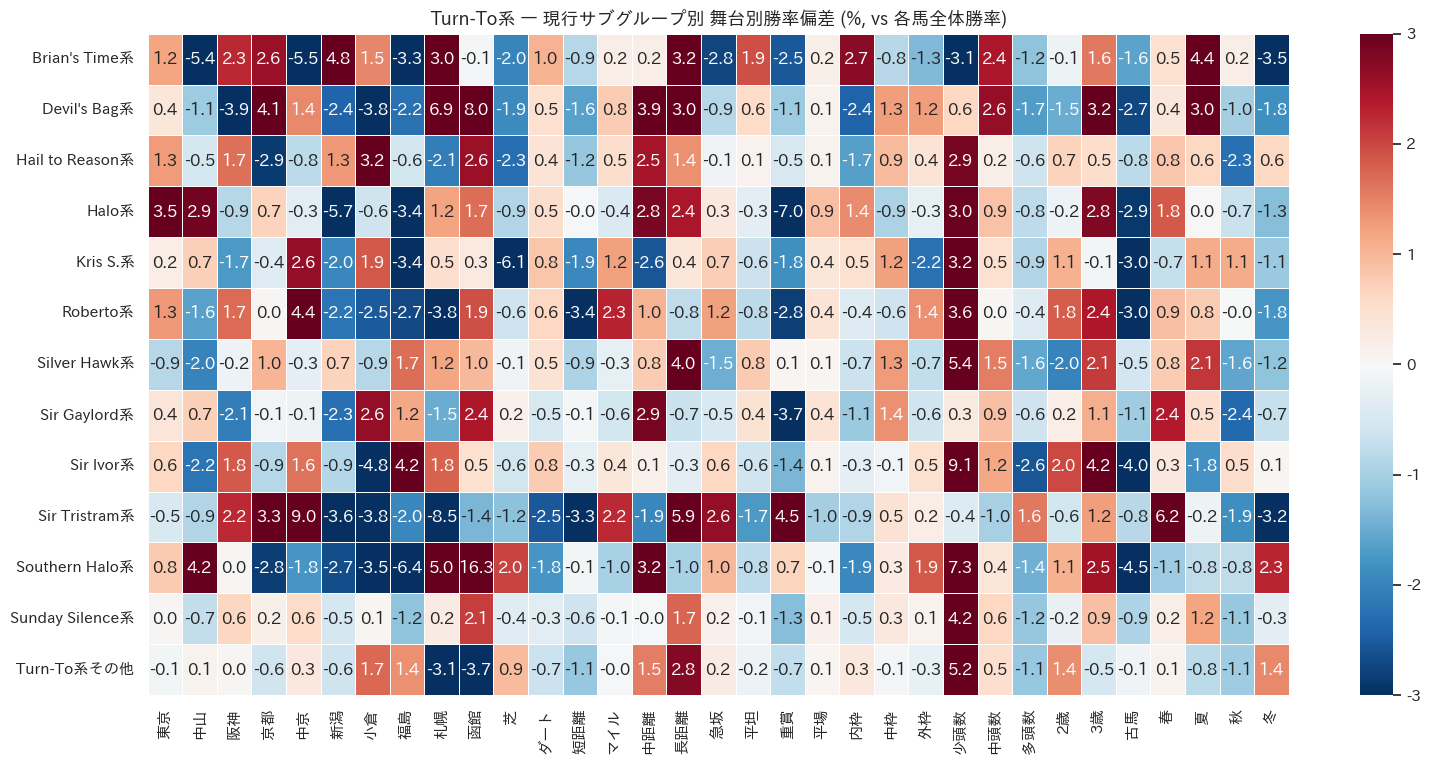

In [8]:
# 現行サブグループ × 条件別 平均偏差ヒートマップ
feat_valid2 = feat_valid.copy()
for col in cond_cols:
    feat_valid2[col] = X_raw.loc[feat_valid2.index, col]  # 元の偏差値を使用

heatmap_data = feat_valid2.groupby('sub_group_label')[cond_cols].mean()

# 列名を短く整形
col_labels = {
    'win_s_芝': '芝', 'win_s_ダート': 'ダート',
    'win_d_短距離': '短距離', 'win_d_マイル': 'マイル',
    'win_d_中距離': '中距離', 'win_d_長距離': '長距離',
    'win_steep': '急坂', 'win_flat': '平坦',
    'win_graded': '重賞', 'win_maiden': '平場',
}
for v in MAJOR_VENUES:
    col_labels[f'win_v_{v}'] = v

# 枠番・頭数・馬齢・季節ラベル
for grp in ['内枠', '中枠', '外枠']:
    col_labels[f'win_b_{grp}'] = grp
for grp in ['少頭数', '中頭数', '多頭数']:
    col_labels[f'win_f_{grp}'] = grp
for grp in ['2歳', '3歳', '古馬']:
    col_labels[f'win_a_{grp}'] = grp
for grp in ['春', '夏', '秋', '冬']:
    col_labels[f'win_season_{grp}'] = grp

heatmap_data = heatmap_data.rename(columns=col_labels)

fig, ax = plt.subplots(figsize=(16, max(4, len(heatmap_data) * 0.6)))
sns.heatmap(
    heatmap_data * 100,  # % 表示
    cmap='RdBu_r', center=0, annot=True, fmt='.1f',
    linewidths=.4, ax=ax, vmin=-3, vmax=3
)
ax.set_title(f'{TARGET_GROUP} — 現行サブグループ別 舞台別勝率偏差 (%, vs 各馬全体勝率)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. PCA による次元削減

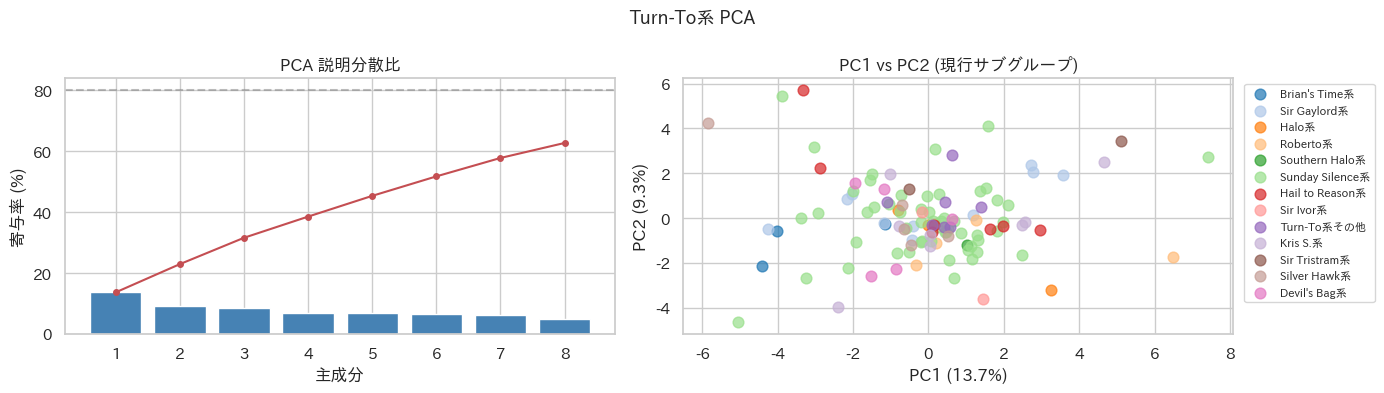

PC1 主要寄与特徴量 (上位5):
急坂    0.422416
平坦    0.412447
夏     0.311694
中山    0.299861
新潟    0.288605
dtype: float64

PC2 主要寄与特徴量 (上位5):
古馬     0.419880
秋      0.316340
2歳     0.288945
長距離    0.287566
中枠     0.274909
dtype: float64


In [9]:
# PCA
pca = PCA(n_components=min(8, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

# 説明分散比
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ev = pca.explained_variance_ratio_
axes[0].bar(range(1, len(ev)+1), ev * 100, color='steelblue')
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev) * 100, 'r-o', markersize=4)
axes[0].axhline(80, color='gray', linestyle='--', alpha=.5)
axes[0].set_xlabel('主成分')
axes[0].set_ylabel('寄与率 (%)')
axes[0].set_title('PCA 説明分散比')

# PC1 vs PC2 散布図（現行サブグループで色分け）
subgroups = feat_valid['sub_group_label'].unique()
palette   = sns.color_palette('tab20', len(subgroups))
sg_color  = dict(zip(subgroups, palette))

for sg in subgroups:
    mask = feat_valid['sub_group_label'].values == sg
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=sg, color=sg_color[sg], alpha=.7, s=60)

axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 (現行サブグループ)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle(f'{TARGET_GROUP} PCA', fontsize=13)
plt.tight_layout()
plt.show()

print('PC1 主要寄与特徴量 (上位5):')
loadings = pd.Series(pca.components_[0], index=X_valid.columns).abs().sort_values(ascending=False)
print(loadings.head(5).rename(col_labels))

print('\nPC2 主要寄与特徴量 (上位5):')
loadings2 = pd.Series(pca.components_[1], index=X_valid.columns).abs().sort_values(ascending=False)
print(loadings2.head(5).rename(col_labels))

## 8. 最適クラスタ数の探索（エルボー法 + シルエット係数）

クラスタ数探索中...
  k=2: Sil=0.083  CH=9.3  DB=3.054  Gap=1.323
  k=3: Sil=0.055  CH=7.3  DB=3.065  Gap=1.327
  k=4: Sil=0.119  CH=6.9  DB=2.313  Gap=1.346
  k=5: Sil=0.043  CH=6.2  DB=2.478  Gap=1.355
  k=6: Sil=0.155  CH=5.9  DB=1.881  Gap=1.363
  k=7: Sil=0.105  CH=5.8  DB=1.831  Gap=1.381
  k=8: Sil=0.101  CH=5.0  DB=1.643  Gap=1.366
  k=9: Sil=0.114  CH=5.3  DB=1.353  Gap=1.399
  k=10: Sil=0.103  CH=5.0  DB=1.320  Gap=1.399
  k=11: Sil=0.048  CH=5.4  DB=1.508  Gap=1.442

最適k の推定:
  シルエット係数:        k = 6
  Calinski-Harabasz:   k = 2
  Davies-Bouldin:      k = 10
  Gap Statistics:      k = 2

→ 多数決による推奨 k = 2


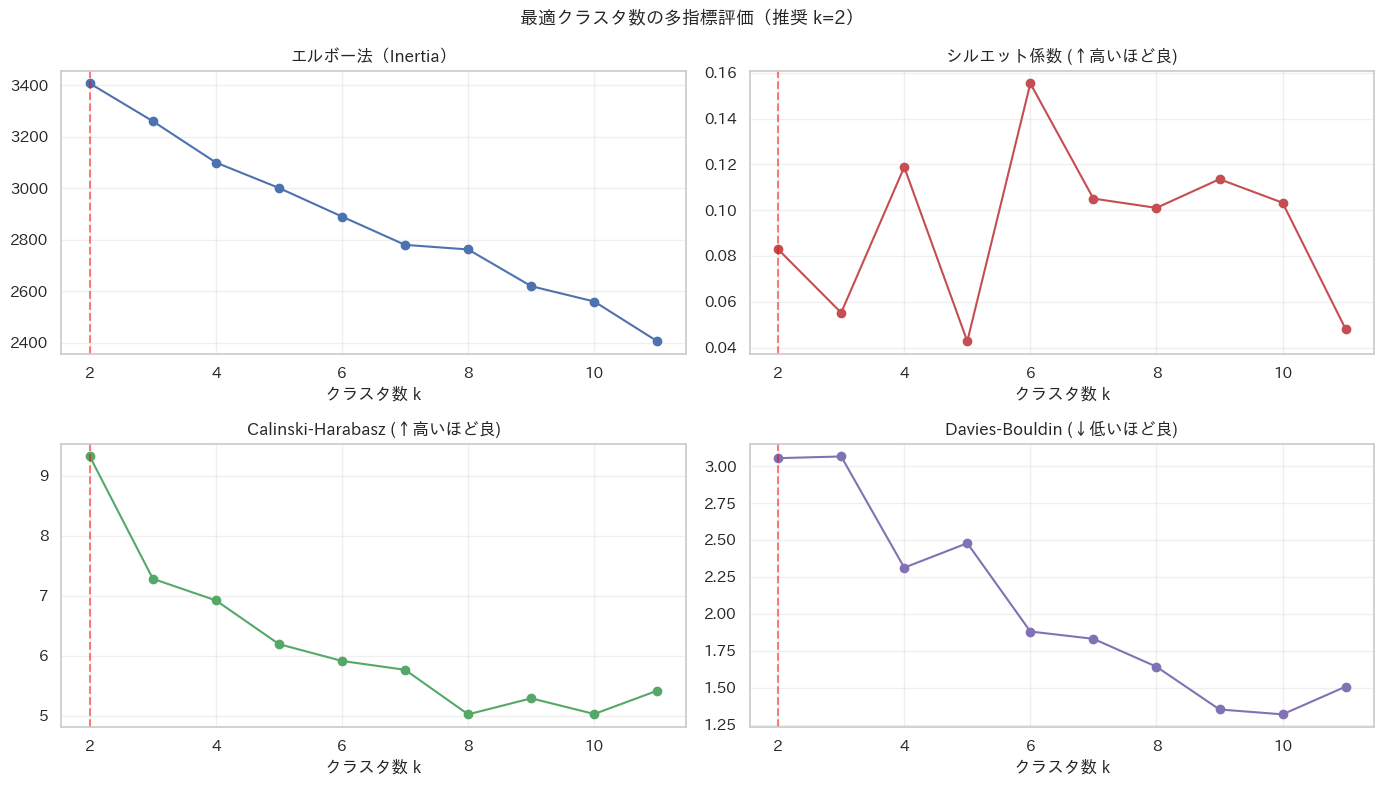

In [10]:
# ── 最適クラスタ数の多指標探索 ──────────────────────────────────────────────
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

K_RANGE = range(2, min(12, len(X_valid) // 3))

metrics = {'k':[], 'inertia':[], 'silhouette':[], 'calinski_harabasz':[], 'davies_bouldin':[]}

# Gap Statistics（ランダム参照分布との比較）
def gap_statistic(X, k, n_ref=10, random_state=42):
    rng = np.random.default_rng(random_state)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    W_k = np.log(km.inertia_)
    ref_inertias = []
    for _ in range(n_ref):
        ref = rng.uniform(X.min(axis=0), X.max(axis=0), X.shape)
        ref_km = KMeans(n_clusters=k, random_state=42, n_init=5)
        ref_km.fit(ref)
        ref_inertias.append(np.log(ref_km.inertia_))
    gap = np.mean(ref_inertias) - W_k
    sk  = np.std(ref_inertias) * np.sqrt(1 + 1/n_ref)
    return gap, sk

print("クラスタ数探索中...")
gaps, sks = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    metrics['k'].append(k)
    metrics['inertia'].append(km.inertia_)
    metrics['silhouette'].append(silhouette_score(X_scaled, labels))
    metrics['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))
    gap, sk = gap_statistic(X_scaled, k)
    gaps.append(gap); sks.append(sk)
    print(f"  k={k}: Sil={metrics['silhouette'][-1]:.3f}  CH={metrics['calinski_harabasz'][-1]:.1f}  DB={metrics['davies_bouldin'][-1]:.3f}  Gap={gap:.3f}")

met_df = pd.DataFrame(metrics)

# Gap法による最適k（gap(k) >= gap(k+1) - sk+1 を満たす最小k）
best_gap_k = list(K_RANGE)[0]
for i in range(len(gaps)-1):
    if gaps[i] >= gaps[i+1] - sks[i+1]:
        best_gap_k = list(K_RANGE)[i]
        break

best_sil_k = met_df.loc[met_df['silhouette'].idxmax(), 'k']
best_ch_k  = met_df.loc[met_df['calinski_harabasz'].idxmax(), 'k']
best_db_k  = met_df.loc[met_df['davies_bouldin'].idxmin(), 'k']

print(f"\n最適k の推定:")
print(f"  シルエット係数:        k = {best_sil_k}")
print(f"  Calinski-Harabasz:   k = {best_ch_k}")
print(f"  Davies-Bouldin:      k = {best_db_k}")
print(f"  Gap Statistics:      k = {best_gap_k}")

# 多数決
from collections import Counter
votes = Counter([best_sil_k, best_ch_k, best_db_k, best_gap_k])
best_k = votes.most_common(1)[0][0]
print(f"\n→ 多数決による推奨 k = {best_k}")

# 可視化
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ks = list(K_RANGE)

axes[0,0].plot(ks, metrics['inertia'], 'bo-'); axes[0,0].set_title('エルボー法（Inertia）'); axes[0,0].axvline(best_k, color='red', ls='--', alpha=.5)
axes[0,1].plot(ks, metrics['silhouette'], 'ro-'); axes[0,1].set_title('シルエット係数 (↑高いほど良)'); axes[0,1].axvline(best_k, color='red', ls='--', alpha=.5)
axes[1,0].plot(ks, metrics['calinski_harabasz'], 'go-'); axes[1,0].set_title('Calinski-Harabasz (↑高いほど良)'); axes[1,0].axvline(best_k, color='red', ls='--', alpha=.5)
axes[1,1].plot(ks, metrics['davies_bouldin'], 'mo-'); axes[1,1].set_title('Davies-Bouldin (↓低いほど良)'); axes[1,1].axvline(best_k, color='red', ls='--', alpha=.5)

for ax in axes.flat:
    ax.set_xlabel('クラスタ数 k')
    ax.grid(True, alpha=.3)

plt.suptitle(f'最適クラスタ数の多指標評価（推奨 k={best_k}）', fontsize=13)
plt.tight_layout()
plt.show()


## 9. アンサンブルクラスタリング（KMeans + Ward + 結果統合）

クラスタ数: 5  (統計推奨=2, フロア=5, 上限=11)
KMeans    : Silhouette=0.043  CH=6.2  DB=2.478
Ward      : Silhouette=0.253  CH=6.3  DB=1.758
Ensemble  : Silhouette=0.264  CH=6.4  DB=1.705

→ 最良手法: Ensemble (Silhouette=0.264)


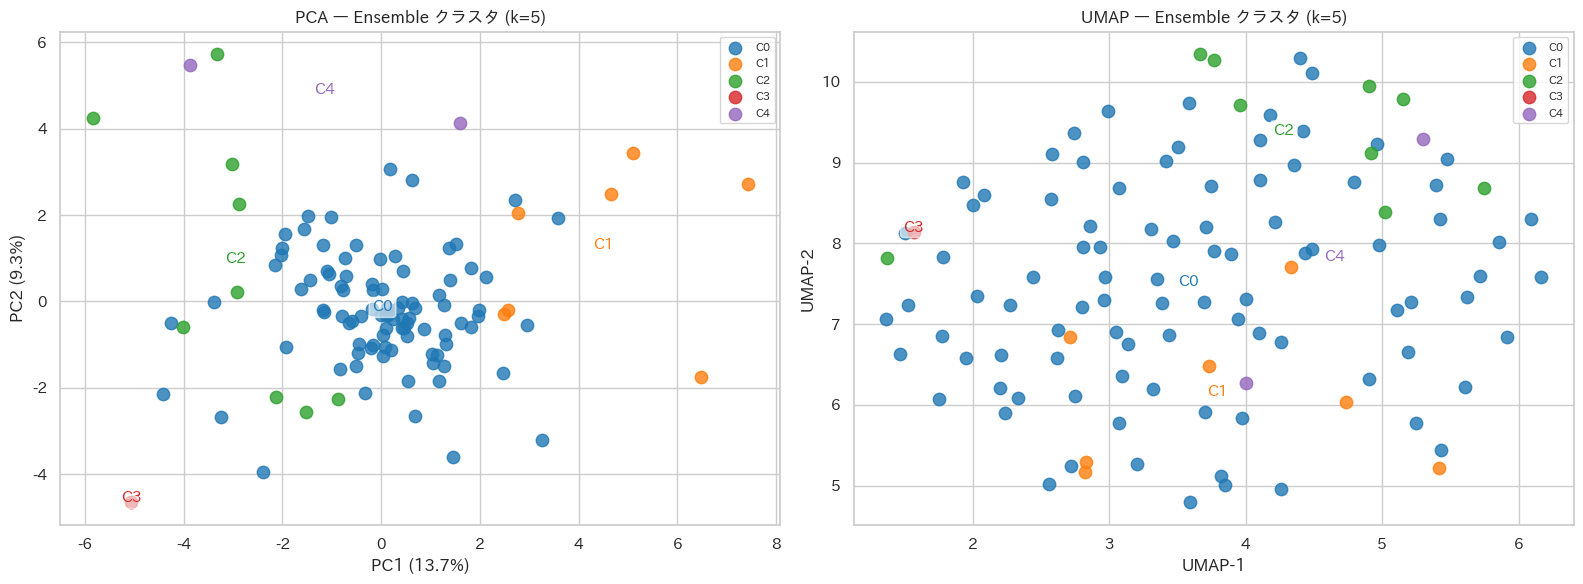

In [11]:
# ── グループ別 最小クラスタ数（納得感のある粒度を確保） ──────────────────────
#   各系統の頭数と系譜の多様性から設定。best_k が下回る場合はフロアを使用。
N_CLUSTERS_FLOOR_MAP = {
    'Turn-To系':         5,   # SS系/Sir Gaylord/HailToReason/Roberto 等 5系統
    'Northern Dancer系': 6,   # NijinskyⅡ/DanzigⅡ/Sadler's Wells 等 多様
    'Native Dancer系':   4,   # Mr.Prospector/Raise a Native 等
    'Nasrullah系':       4,   # Bold Ruler/Never Bend/Red God 等
    '非主流':            5,   # 多様な小系統を一定数に分割
}
N_CLUSTERS_FLOOR = N_CLUSTERS_FLOOR_MAP.get(TARGET_GROUP, 4)

# データ量に応じた上限: 1クラスタ当たり最低 10 頭を確保
N_CLUSTERS_CEIL = max(N_CLUSTERS_FLOOR, len(X_valid) // 10)

# 最終クラスタ数（統計最適 best_k よりフロアを優先）
N_CLUSTERS = max(best_k, N_CLUSTERS_FLOOR)
N_CLUSTERS = min(N_CLUSTERS, N_CLUSTERS_CEIL)   # 上限超えを防止

print(f"クラスタ数: {N_CLUSTERS}  (統計推奨={best_k}, フロア={N_CLUSTERS_FLOOR}, 上限={N_CLUSTERS_CEIL})")

# ── KMeans ────────────────────────────────────────────────────
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X_scaled)

# ── Ward 階層クラスタリング ────────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
ward_labels = ward.fit_predict(X_scaled)

# ── アンサンブル: 類似度行列から合意クラスタを取得 ────────────────
# 同じクラスタに属する頻度を「合意行列」として構築
n = len(X_scaled)
consensus = np.zeros((n, n))
for labels in [km_labels, ward_labels]:
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                consensus[i, j] += 1
consensus /= 2  # 0〜1 に正規化

# 合意行列を距離行列として Ward クラスタリング
from sklearn.cluster import AgglomerativeClustering
dist_consensus = 1 - consensus
ensemble_clust = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='average', metric='precomputed')
ensemble_labels = ensemble_clust.fit_predict(dist_consensus)

# 品質比較
for name, labels in [('KMeans', km_labels), ('Ward', ward_labels), ('Ensemble', ensemble_labels)]:
    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    print(f"{name:10s}: Silhouette={sil:.3f}  CH={ch:.1f}  DB={db:.3f}")

# 最良手法を選択（シルエット係数で判定）
scores = {
    'KMeans':   silhouette_score(X_scaled, km_labels),
    'Ward':     silhouette_score(X_scaled, ward_labels),
    'Ensemble': silhouette_score(X_scaled, ensemble_labels),
}
best_method = max(scores, key=scores.get)
print(f"\n→ 最良手法: {best_method} (Silhouette={scores[best_method]:.3f})")

cluster_labels_map = {'KMeans': km_labels, 'Ward': ward_labels, 'Ensemble': ensemble_labels}
cluster_labels = cluster_labels_map[best_method]
feat_valid['cluster'] = cluster_labels

# ── PCA + UMAP 散布図（クラスタで色分け）────────────────────────
import umap as umap_lib
reducer = umap_lib.UMAP(n_neighbors=10, min_dist=0.3, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

palette_k = sns.color_palette('tab10', N_CLUSTERS)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 散布図
for k in range(N_CLUSTERS):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'C{k}', color=palette_k[k], alpha=.8, s=80)
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    axes[0].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold',
                     ha='center', color=palette_k[k],
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.6))
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA — {best_method} クラスタ (k={N_CLUSTERS})')
axes[0].legend(loc='best', fontsize=8)

# UMAP 散布図
for k in range(N_CLUSTERS):
    mask = cluster_labels == k
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], label=f'C{k}', color=palette_k[k], alpha=.8, s=80)
    cx, cy = X_umap[mask, 0].mean(), X_umap[mask, 1].mean()
    axes[1].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold',
                     ha='center', color=palette_k[k],
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.6))
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].set_title(f'UMAP — {best_method} クラスタ (k={N_CLUSTERS})')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout(); plt.show()


## 10. クラスタプロファイル（各クラスタの特徴）

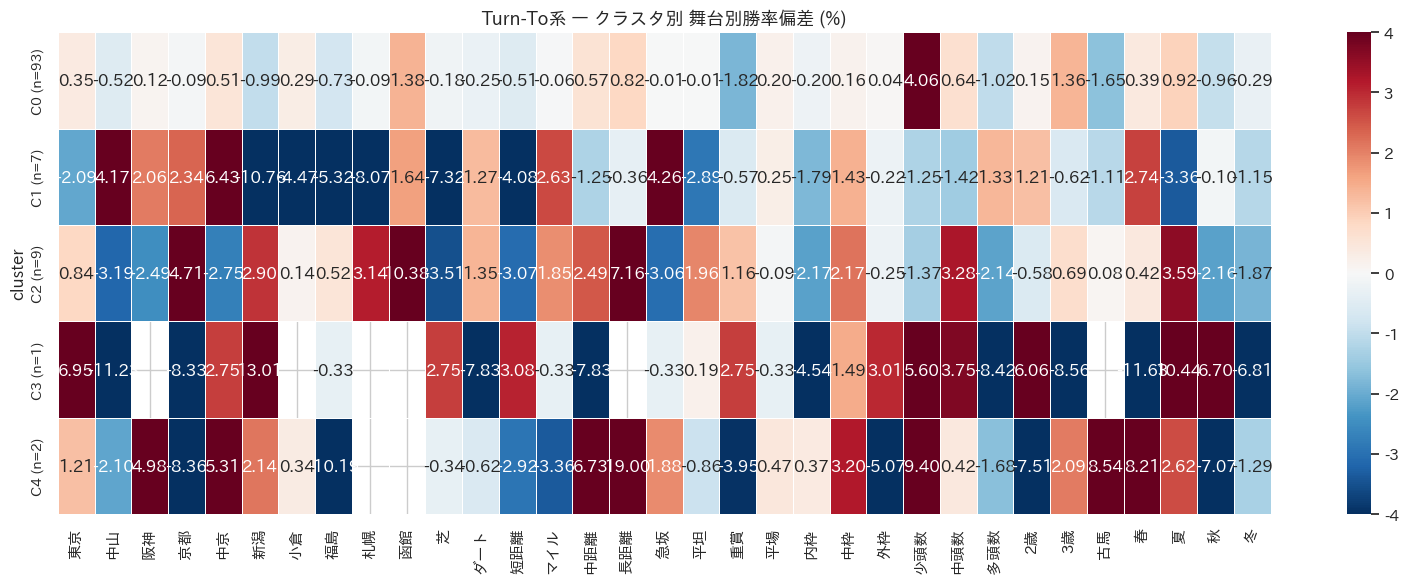

In [12]:
# クラスタ × 条件別 平均偏差ヒートマップ
feat_valid_prof = feat_valid.copy()
for col in cond_cols:
    feat_valid_prof[col] = X_raw.loc[feat_valid_prof.index, col]

profile = feat_valid_prof.groupby('cluster')[cond_cols].mean().rename(columns=col_labels)
profile_n = feat_valid_prof.groupby('cluster').size().rename('n')

fig, ax = plt.subplots(figsize=(16, N_CLUSTERS * 0.8 + 2))
sns.heatmap(
    profile * 100,
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=.4, ax=ax, vmin=-4, vmax=4
)
ax.set_yticklabels([f'C{k} (n={profile_n.get(k,0)})' for k in profile.index], fontsize=10)
ax.set_title(f'{TARGET_GROUP} — クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. クラスタ別 種牡馬一覧

In [13]:
for k in range(N_CLUSTERS):
    members = feat_valid[feat_valid['cluster'] == k][['stallion_name','sub_group_label','n_horses']]\
              .sort_values('n_horses', ascending=False)
    print(f'\n=== Cluster {k}  ({len(members)}頭) ===')
    
    # サブグループ分布
    sg_dist = members['sub_group_label'].value_counts()
    print('  構成サブグループ:', sg_dist.to_dict())
    
    # 上位20頭
    display_cols = ['stallion_name', 'sub_group_label', 'n_horses']
    print(members.head(20).to_string(index=False))


=== Cluster 0  (93頭) ===
  構成サブグループ: {'Sunday Silence系': 47, 'Sir Gaylord系': 9, 'Turn-To系その他': 7, 'Kris S.系': 5, 'Hail to Reason系': 5, 'Silver Hawk系': 4, 'Roberto系': 4, 'Halo系': 3, "Devil's Bag系": 3, 'Sir Ivor系': 2, "Brian's Time系": 2, 'Southern Halo系': 1, 'Sir Tristram系': 1}
 stallion_name sub_group_label  n_horses
       Turn-to     Turn-To系その他      9763
Hail to Reason Hail to Reason系      8736
     サンデーサイレンス Sunday Silence系      5587
          Halo           Halo系      4968
     ディープインパクト Sunday Silence系      3296
       Roberto        Roberto系      2180
   Sir Gaylord    Sir Gaylord系      1096
        ハーツクライ Sunday Silence系      1004
   Bold Reason Hail to Reason系       942
     シンボリクリスエス        Kris S.系       931
       ステイゴールド Sunday Silence系       882
         フジキセキ Sunday Silence系       882
      Sir Ivor       Sir Ivor系       868
     スクリーンヒーロー    Silver Hawk系       709
       エピファネイア        Kris S.系       611
           キズナ Sunday Silence系       601
       ダイワメジャー Sunday Sil

## 12. 階層クラスタリング（デンドログラム）

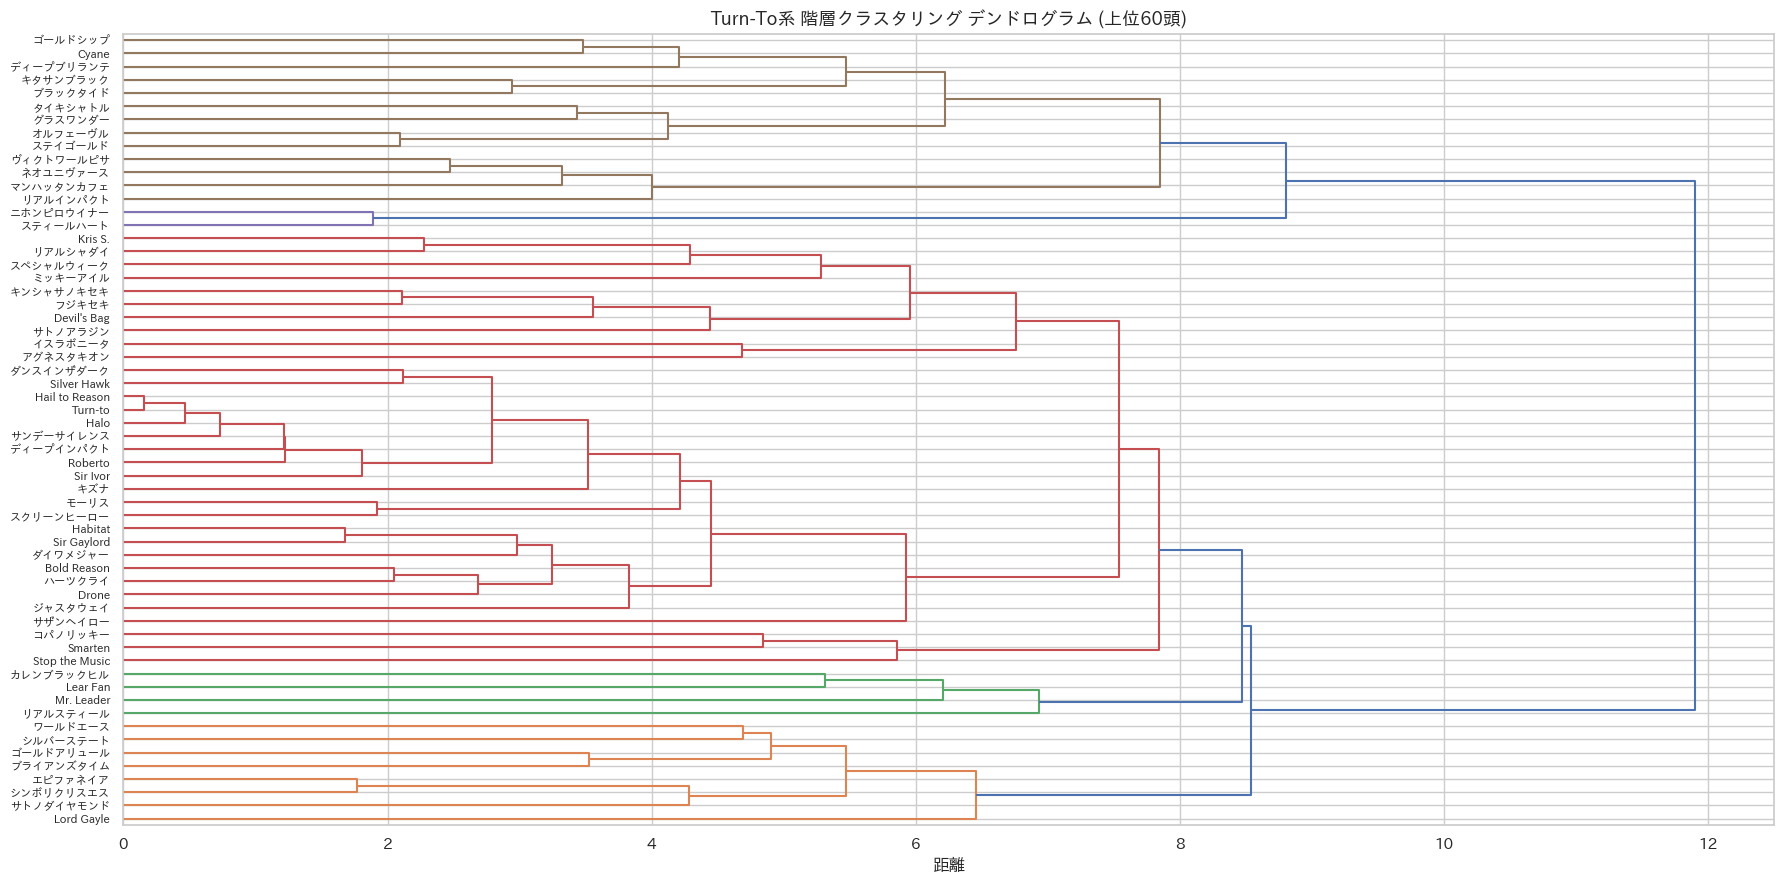

In [14]:
# 出走馬数上位N頭に絞ってデンドログラムを描画（可読性のため）
TOP_N_DENDRO = 60

top_idx = feat_valid.nlargest(TOP_N_DENDRO, 'n_horses').index
X_top   = X_scaled[[list(feat_valid.index).index(i) for i in top_idx]]
labels_top = feat_valid.loc[top_idx, 'stallion_name'].tolist()

Z = linkage(X_top, method='ward')

fig, ax = plt.subplots(figsize=(18, 9))
dendrogram(
    Z, labels=labels_top, orientation='right',
    leaf_font_size=8, ax=ax,
    color_threshold=Z[-N_CLUSTERS+1, 2]  # k クラスタに対応するカット高さ
)
ax.set_title(f'{TARGET_GROUP} 階層クラスタリング デンドログラム (上位{TOP_N_DENDRO}頭)', fontsize=13)
ax.set_xlabel('距離')
plt.tight_layout()
plt.show()

## 13. 個別種牡馬の条件別プロファイル表示

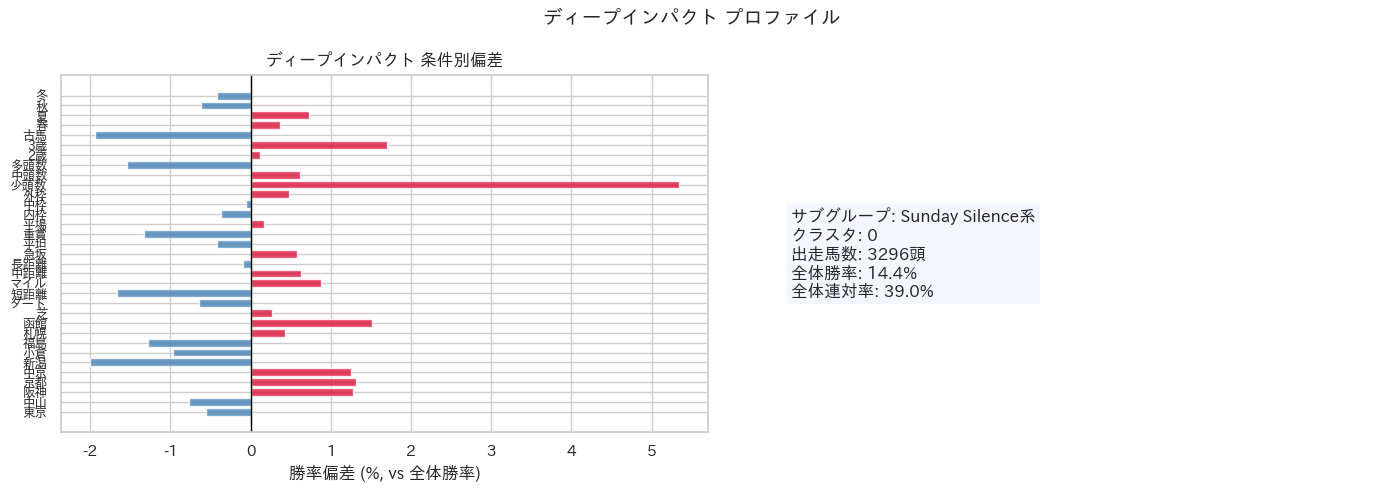

In [15]:
def plot_stallion_profile(stallion_name_query: str):
    """特定の種牡馬の条件別勝率偏差をレーダーチャートで表示。"""
    row = feat_valid[feat_valid['stallion_name'].str.contains(stallion_name_query, na=False)]
    if row.empty:
        print(f'種牡馬 "{stallion_name_query}" が見つかりません')
        print('候補:', feat_valid['stallion_name'].dropna().str[:10].unique()[:20])
        return
    
    row = row.iloc[0]
    sid = row.name
    vals = X_raw.loc[sid, cond_cols].rename(col_labels) * 100  # % 変換
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # バーチャート
    colors = ['crimson' if v > 0 else 'steelblue' for v in vals.values]
    axes[0].barh(range(len(vals)), vals.values, color=colors, alpha=.8)
    axes[0].set_yticks(range(len(vals)))
    axes[0].set_yticklabels(vals.index, fontsize=9)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_xlabel('勝率偏差 (%, vs 全体勝率)')
    axes[0].set_title(f'{row["stallion_name"]} 条件別偏差')
    
    # 実績サマリ
    info_text = (
        f'サブグループ: {row.get("sub_group_label", "?")}\n'
        f'クラスタ: {row.get("cluster", "?")}\n'
        f'出走馬数: {int(row.get("n_horses", 0))}頭\n'
        f'全体勝率: {feat_df.loc[sid, "win_rate_total"]*100:.1f}%\n'
        f'全体連対率: {feat_df.loc[sid, "place_rate_total"]*100:.1f}%'
    )
    axes[1].text(0.1, 0.5, info_text, transform=axes[1].transAxes,
                 fontsize=12, va='center',
                 bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=.8))
    axes[1].axis('off')
    
    plt.suptitle(f'{stallion_name_query} プロファイル', fontsize=14)
    plt.tight_layout()
    plt.show()

# 例: ディープインパクト、キングカメハメハ などを試す
plot_stallion_profile('ディープインパクト')

## 14. クラスタ別 代表種牡馬プロファイル比較

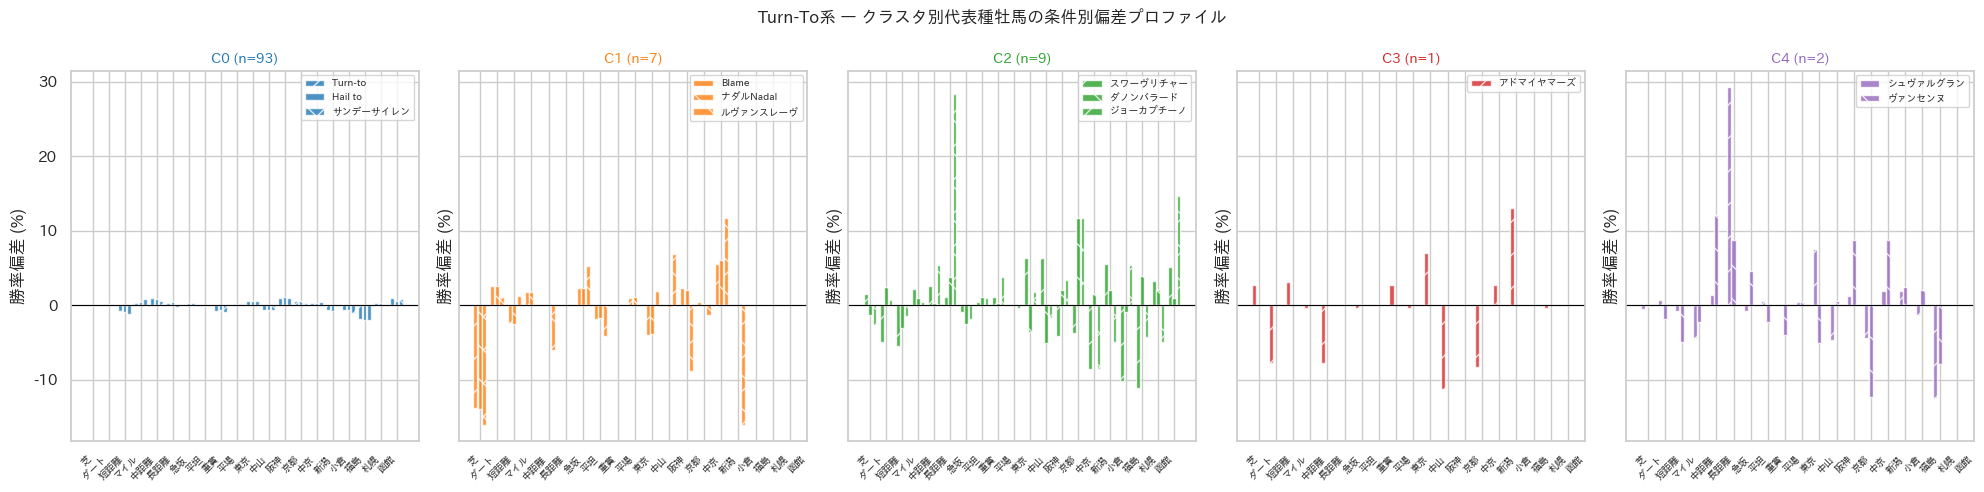

In [16]:
# 各クラスタの代表（n_horses 最大）をレーダーチャート的に比較
TOP_PER_CLUSTER = 3  # 各クラスタから上位N頭

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(N_CLUSTERS * 4, 5), sharey=True)
if N_CLUSTERS == 1:
    axes = [axes]

cond_labels_short = [
    '芝', 'ダート', '短距離', 'マイル', '中距離', '長距離',
    '急坂', '平坦', '重賞', '平場'
] + MAJOR_VENUES
selected_cols = [
    'win_s_芝', 'win_s_ダート', 'win_d_短距離', 'win_d_マイル',
    'win_d_中距離', 'win_d_長距離', 'win_steep', 'win_flat',
    'win_graded', 'win_maiden'
] + [f'win_v_{v}' for v in MAJOR_VENUES]
selected_cols = [c for c in selected_cols if c in cond_cols]
sel_labels    = [col_labels.get(c, c) for c in selected_cols]

for k, ax in enumerate(axes):
    cluster_df = feat_valid[feat_valid['cluster'] == k]
    top_members = cluster_df.nlargest(TOP_PER_CLUSTER, 'n_horses')
    
    x = np.arange(len(selected_cols))
    width = 0.8 / TOP_PER_CLUSTER
    
    for i, (sid, mrow) in enumerate(top_members.iterrows()):
        vals = X_raw.loc[sid, selected_cols].values * 100
        ax.bar(x + i * width, vals, width=width * 0.9,
               label=str(mrow['stallion_name'])[:8], alpha=.8,
               color=palette_k[k], hatch=['/', '\\', 'x'][i % 3])
    
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(sel_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'C{k} (n={len(cluster_df)})', color=palette_k[k], fontsize=10)
    ax.set_ylabel('勝率偏差 (%)')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle(f'{TARGET_GROUP} — クラスタ別代表種牡馬の条件別偏差プロファイル', fontsize=12)
plt.tight_layout()
plt.show()

## 15. 現行サブグループ vs データ駆動クラスタ の比較クロス表

Turn-To系: 現行サブグループ × データ駆動クラスタ クロス表


cluster,C0,C1,C2,C3,C4,All
sub_group_label,,,,,,
Brian's Time系,2,0,1,0,0,3
Devil's Bag系,3,0,2,0,0,5
Hail to Reason系,5,0,2,0,0,7
Halo系,3,0,0,0,0,3
Kris S.系,5,3,0,0,0,8
Roberto系,4,1,0,0,0,5
Silver Hawk系,4,0,1,0,0,5
Sir Gaylord系,9,1,0,0,0,10
Sir Ivor系,2,0,0,0,0,2


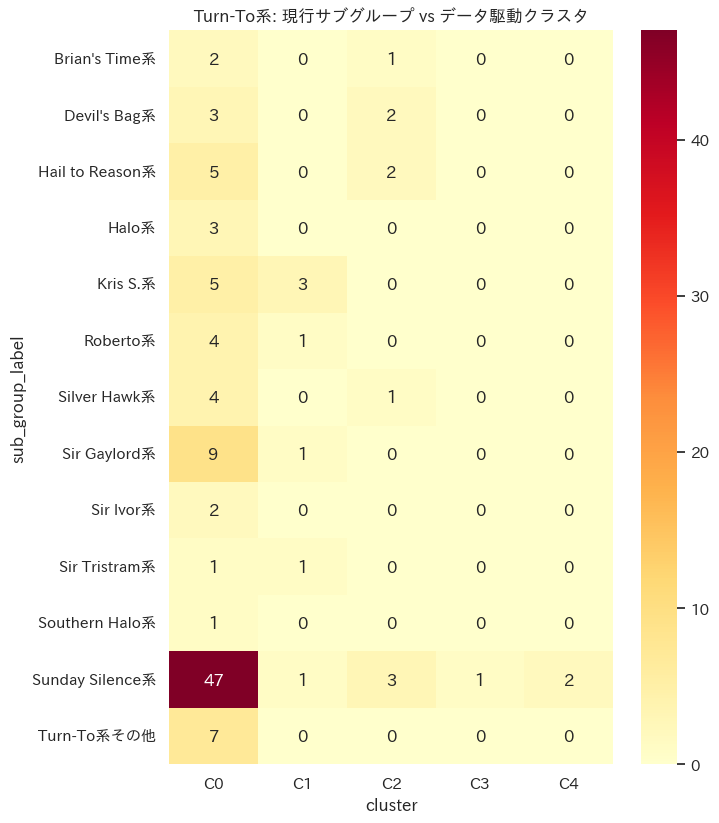

In [17]:
cross = pd.crosstab(
    feat_valid['sub_group_label'],
    feat_valid['cluster'].apply(lambda k: f'C{k}'),
    margins=True
)
print(f'{TARGET_GROUP}: 現行サブグループ × データ駆動クラスタ クロス表')
display(cross)

# ヒートマップ
fig, ax = plt.subplots(figsize=(max(6, N_CLUSTERS * 1.5), max(4, len(cross) * 0.6)))
sns.heatmap(
    cross.iloc[:-1, :-1],  # margins 除外
    annot=True, fmt='d', cmap='YlOrRd', ax=ax
)
ax.set_title(f'{TARGET_GROUP}: 現行サブグループ vs データ駆動クラスタ', fontsize=12)
plt.tight_layout()
plt.show()

## 16. ★ グループ変更: 別の主流血統を分析

以下のセルで `TARGET_GROUP` を変更して **セル 3 (「3. 対象グループ...」) から再実行** してください。

```python
TARGET_GROUP = 'Northern Dancer系'  # ← ここを変更
# 'Turn-To系' / 'Northern Dancer系' / 'Native Dancer系' / 'Nasrullah系'
```

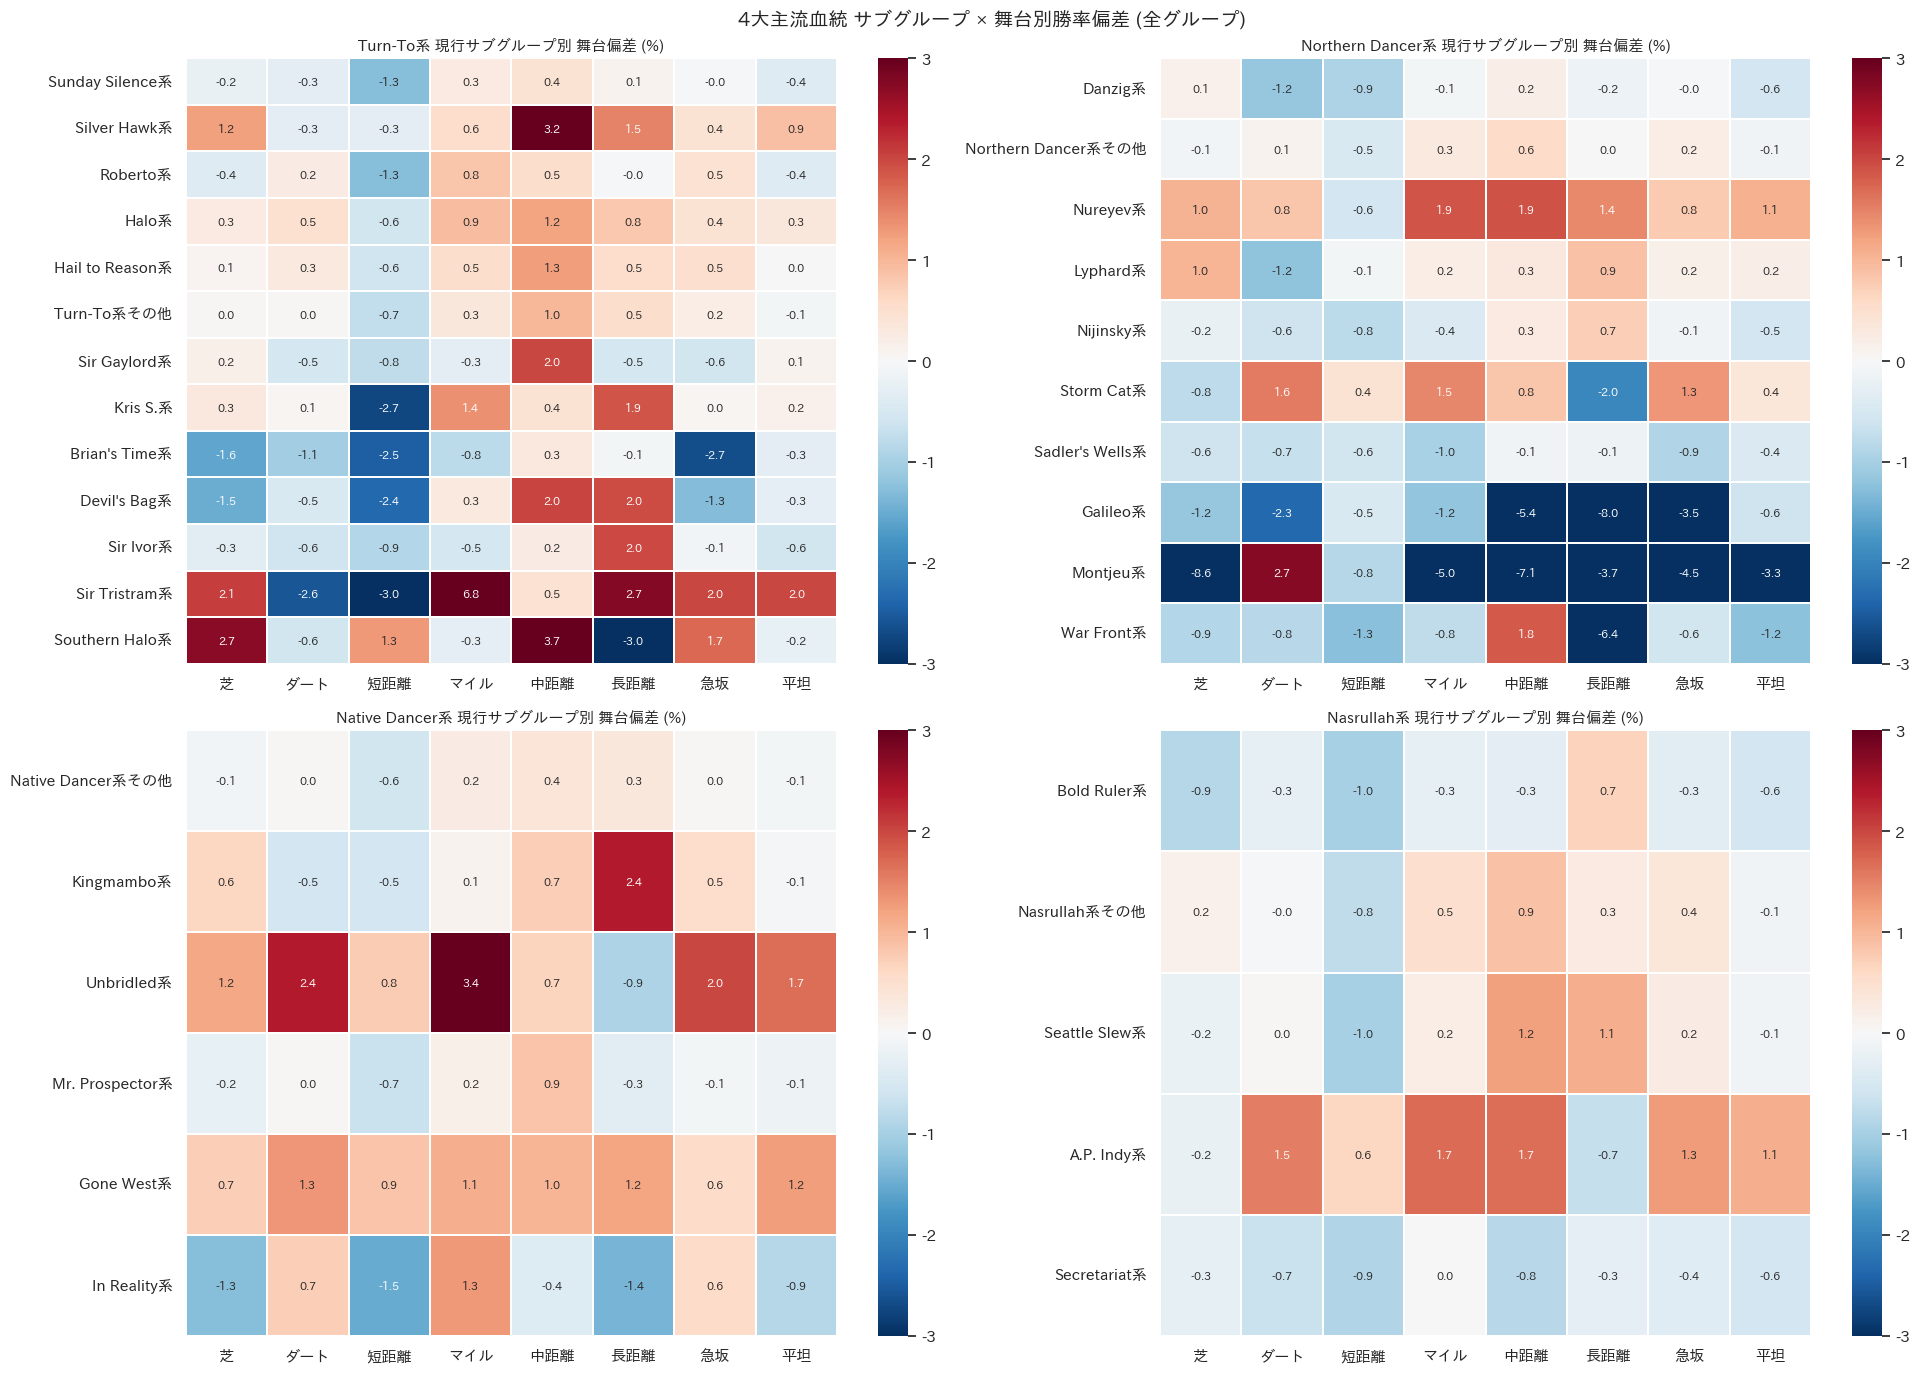

In [18]:
# ── 簡易まとめ: 全グループの舞台別偏差ヒートマップ一括表示 ──
# ※ 実行に時間がかかる場合があります

ALL_GROUPS = ['Turn-To系', 'Northern Dancer系', 'Native Dancer系', 'Nasrullah系']

def build_group_profile(group_name):
    """特定グループの種牡馬 × 条件別 平均勝率偏差を計算。"""
    tlin = lin[lin['main_group_name'] == group_name]
    mc = cats.merge(tlin[['stallion_id','sub_group_label']], on='stallion_id', how='inner')
    rf2 = race.merge(mc[['horse_id','stallion_id','sub_group_label']], on='horse_id', how='inner')
    rf2['dist_cat'] = pd.cut(rf2['distance'], bins=DIST_BINS, labels=DIST_LABELS)
    rf2['is_steep'] = rf2['venue'].isin(STEEP_VENUES)
    
    # サブグループ × 条件別 勝率
    conds = {
        '芝':    rf2['surface'] == '芝',
        'ダート': rf2['surface'] == 'ダート',
        '短距離': rf2['dist_cat'] == '短距離',
        'マイル': rf2['dist_cat'] == 'マイル',
        '中距離': rf2['dist_cat'] == '中距離',
        '長距離': rf2['dist_cat'] == '長距離',
        '急坂':   rf2['is_steep'],
        '平坦':   ~rf2['is_steep'],
    }
    rows = {}
    baseline_wr = (rf2['win'].sum() / rf2['valid'].sum()) if rf2['valid'].sum() > 0 else 0.0
    for sg in tlin['sub_group_label'].unique():
        sg_mask = rf2['sub_group_label'] == sg
        row = {}
        for cname, mask in conds.items():
            sub = rf2[sg_mask & mask]
            n = sub['valid'].sum()
            row[cname] = (sub['win'].sum() / n - baseline_wr) if n >= MIN_COND_N else np.nan
        rows[sg] = row
    return pd.DataFrame(rows).T

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, gname in zip(axes.flat, ALL_GROUPS):
    prof = build_group_profile(gname)
    if prof.empty:
        ax.set_title(f'{gname} (データなし)')
        continue
    sns.heatmap(prof * 100, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
                vmin=-3, vmax=3, ax=ax, linewidths=.3, annot_kws={'size': 8})
    ax.set_title(f'{gname} 現行サブグループ別 舞台偏差 (%)', fontsize=11)

plt.suptitle('4大主流血統 サブグループ × 舞台別勝率偏差 (全グループ)', fontsize=14)
plt.tight_layout()
plt.show()

## 17. Sunday Silence系 単独深掘り分析
Turn-To系内最大サブグループ（54頭）を単独で再クラスタリングし、内部構造を詳細に分析する。

Sunday Silence系: 54 頭
PCA 累積寄与率 (PC1-4): [0.14883931 0.25634548 0.35479934 0.43726948]
Sunday Silence系 k: 4  (統計推奨=3, フロア=4)
  外れ値 (1頭) を除外: ['アドマイヤマーズ']
  再クラスタリング k=4 (53頭)


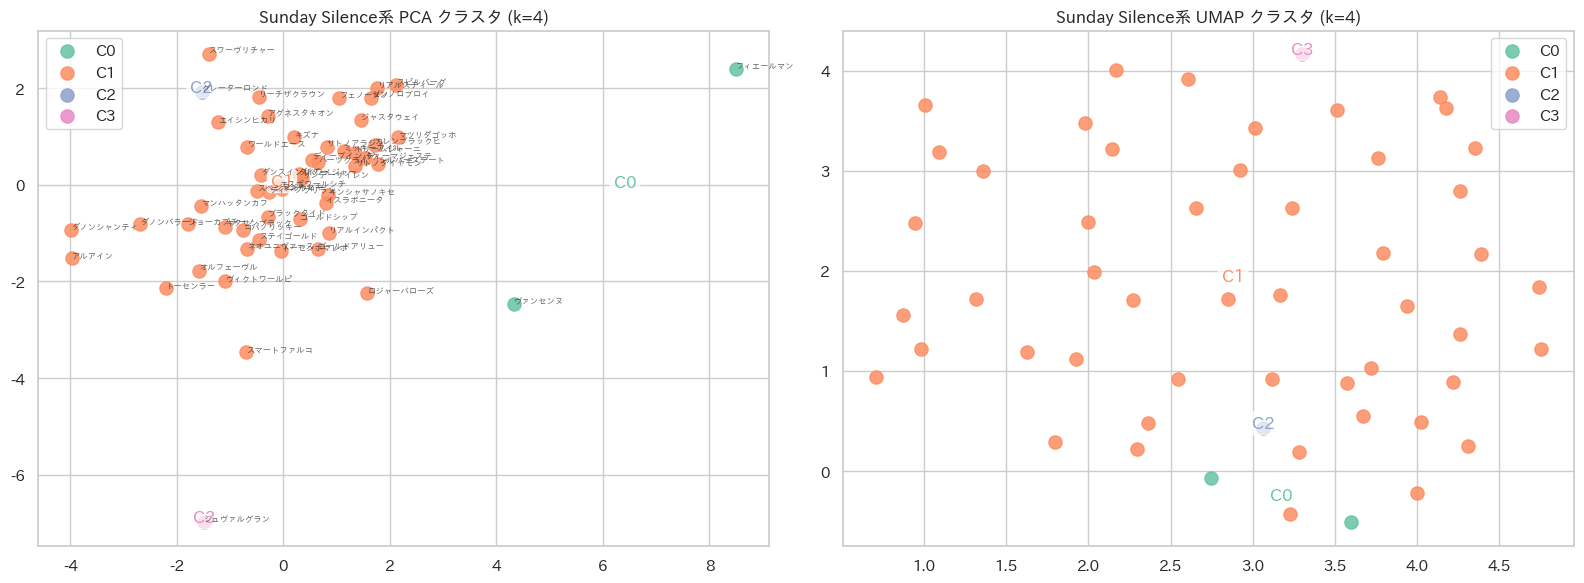

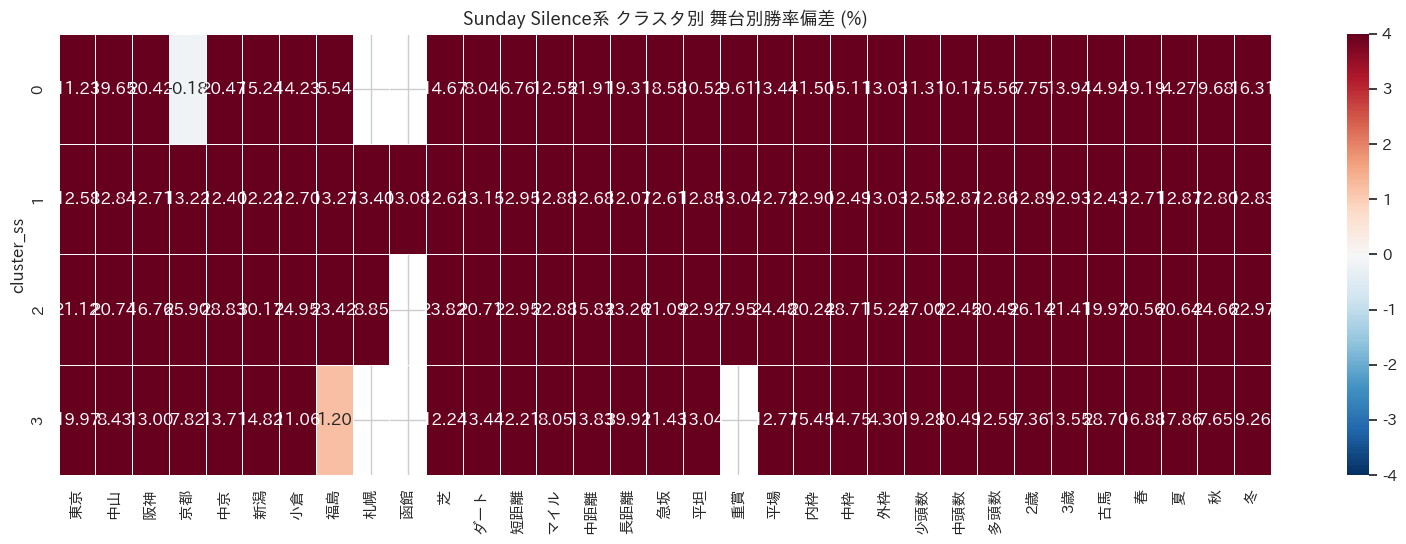


=== Sunday Silence C0 (2頭) ===
stallion_name  n_horses
       ヴァンセンヌ        38
      フィエールマン        37

=== Sunday Silence C1 (49頭) ===
stallion_name  n_horses
    サンデーサイレンス      5587
    ディープインパクト      3296
       ハーツクライ      1004
        フジキセキ       882
      ステイゴールド       882
          キズナ       601
      ダイワメジャー       582
    ゴールドアリュール       482

=== Sunday Silence C2 (1頭) ===
stallion_name  n_horses
    グレーターロンドン        45

=== Sunday Silence C3 (1頭) ===
stallion_name  n_horses
     シュヴァルグラン        59


In [19]:
# ── Sunday Silence系単独抽出 ────────────────────────────────────────────
SS_GROUP = 'Sunday Silence系'
ss_df = feat_valid[feat_valid['sub_group_label'] == SS_GROUP].copy()
print(f"{SS_GROUP}: {len(ss_df)} 頭")
if len(ss_df) < 6:
    print("頭数不足 — スキップ")
else:
    ss_ids   = ss_df.index
    ss_X_raw = X_raw.loc[ss_ids, cond_cols]

    # NaN 補完（列中央値）
    ss_X_imp = ss_X_raw.apply(lambda col: col.fillna(col.median()))
    # 欠損全列は 0 補完
    ss_X_imp = ss_X_imp.fillna(0)

    ss_scaler = StandardScaler()
    ss_X_sc   = ss_scaler.fit_transform(ss_X_imp)

    ss_pca = PCA(n_components=min(6, ss_X_sc.shape[0]-1, ss_X_sc.shape[1]))
    ss_X_pca = ss_pca.fit_transform(ss_X_sc)
    print(f"PCA 累積寄与率 (PC1-4): {ss_pca.explained_variance_ratio_[:4].cumsum()}")

    # 最適 k の探索
    SS_K_RANGE = range(2, min(7, len(ss_df) // 2))
    ss_sils, ss_chs, ss_dbs = [], [], []
    for k in SS_K_RANGE:
        lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(ss_X_sc)
        ss_sils.append(silhouette_score(ss_X_sc, lbl))
        ss_chs.append(calinski_harabasz_score(ss_X_sc, lbl))
        ss_dbs.append(davies_bouldin_score(ss_X_sc, lbl))

    ss_best_k_sil = list(SS_K_RANGE)[np.argmax(ss_sils)]
    ss_best_k_ch  = list(SS_K_RANGE)[np.argmax(ss_chs)]
    ss_best_k_db  = list(SS_K_RANGE)[np.argmin(ss_dbs)]
    from collections import Counter as C2
    ss_best_k_vote = C2([ss_best_k_sil, ss_best_k_ch, ss_best_k_db]).most_common(1)[0][0]
    # Sunday Silence系はサブライン多様（SS/ディープ/ハーツ/キタサン等）→ 最低 4 グループ確保
    SS_FLOOR = 4
    ss_best_k = max(ss_best_k_vote, SS_FLOOR)
    ss_best_k = min(ss_best_k, len(ss_df) // 8)  # 1クラスタ最低8頭
    ss_best_k = max(ss_best_k, 2)  # 最低2
    print(f"Sunday Silence系 k: {ss_best_k}  (統計推奨={ss_best_k_vote}, フロア={SS_FLOOR})")

    # クラスタリング
    ss_km = KMeans(n_clusters=ss_best_k, random_state=42, n_init=20)
    ss_labels = ss_km.fit_predict(ss_X_sc)

    # ── マイクロクラスタ（3頭未満）を外れ値として除外し再クラスタリング ──
    SS_MIN_CLUSTER = 3
    micro_mask = np.array([False] * len(ss_labels))
    for _k in range(ss_best_k):
        if (ss_labels == _k).sum() < SS_MIN_CLUSTER:
            micro_mask |= (ss_labels == _k)

    if micro_mask.sum() > 0:
        outlier_names = ss_df.iloc[micro_mask]['stallion_name'].tolist()
        print(f"  外れ値 ({micro_mask.sum()}頭) を除外: {outlier_names}")
        ss_X_sc_clean   = ss_X_sc[~micro_mask]
        ss_X_pca_clean  = ss_X_pca[~micro_mask]
        ss_df_clean     = ss_df.iloc[~micro_mask].copy()
        # 有効クラスタ数を再確定（縮小）
        ss_best_k_clean = min(ss_best_k, len(ss_X_sc_clean) // SS_MIN_CLUSTER)
        ss_best_k_clean = max(ss_best_k_clean, 2)
        ss_km2     = KMeans(n_clusters=ss_best_k_clean, random_state=42, n_init=20)
        ss_labels2 = ss_km2.fit_predict(ss_X_sc_clean)
        # 外れ値除外後のデータに統一（labels / X / df のサイズを揃える）
        ss_labels = ss_labels2           # 53要素 (clean のみ)
        ss_X_sc   = ss_X_sc_clean        # 53行
        ss_X_pca  = ss_X_pca_clean       # 53行
        ss_df     = ss_df_clean          # 53行
        ss_best_k = ss_best_k_clean
        print(f"  再クラスタリング k={ss_best_k} ({len(ss_df)}頭)")
    else:
        print(f"  マイクロクラスタなし (全 {len(ss_labels)}頭 使用)")

    ss_df['cluster_ss'] = ss_labels  # labels と df は同サイズが保証済み

    # UMAP（外れ値除外後の ss_X_sc に合わせて再計算）
    ss_reducer = umap_lib.UMAP(n_neighbors=min(8, len(ss_X_sc)-1), min_dist=0.3, random_state=42)
    ss_X_umap = ss_reducer.fit_transform(ss_X_sc)

    # 散布図
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pal = sns.color_palette('Set2', ss_best_k)
    for k in range(ss_best_k):
        mask = ss_labels == k
        axes[0].scatter(ss_X_pca[mask, 0], ss_X_pca[mask, 1], color=pal[k], alpha=.85, s=90, label=f'C{k}')
        cx, cy = ss_X_pca[mask, 0].mean(), ss_X_pca[mask, 1].mean()
        axes[0].annotate(f'C{k}', (cx, cy), fontsize=12, fontweight='bold', color=pal[k],
                         ha='center', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
        for idx, (pid, prow) in enumerate(ss_df[mask].iterrows()):
            axes[0].annotate(str(prow['stallion_name'])[:8], 
                             (ss_X_pca[mask, 0][idx], ss_X_pca[mask, 1][idx]),
                             fontsize=6, ha='left', va='bottom', alpha=.7)
        axes[1].scatter(ss_X_umap[mask, 0], ss_X_umap[mask, 1], color=pal[k], alpha=.85, s=90, label=f'C{k}')
        cx, cy = ss_X_umap[mask, 0].mean(), ss_X_umap[mask, 1].mean()
        axes[1].annotate(f'C{k}', (cx, cy), fontsize=12, fontweight='bold', color=pal[k],
                         ha='center', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
    axes[0].set_title(f'{SS_GROUP} PCA クラスタ (k={ss_best_k})'); axes[0].legend()
    axes[1].set_title(f'{SS_GROUP} UMAP クラスタ (k={ss_best_k})'); axes[1].legend()
    plt.tight_layout(); plt.show()

    # クラスタ別ヒートマップ
    ss_profile = ss_df.groupby('cluster_ss')[cond_cols].mean()
    ss_overall = X_raw.loc[ss_ids, cond_cols].mean()
    ss_profile_dev = ss_profile.subtract(ss_overall)
    ss_profile_dev_r = ss_profile_dev.rename(columns=col_labels)
    fig, ax = plt.subplots(figsize=(16, ss_best_k * 0.9 + 2))
    sns.heatmap(ss_profile_dev_r * 100, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                linewidths=.4, ax=ax, vmin=-4, vmax=4)
    ax.set_title(f'{SS_GROUP} クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
    plt.tight_layout(); plt.show()

    # クラスタ別メンバー一覧
    for k in range(ss_best_k):
        members = ss_df[ss_df['cluster_ss'] == k].nlargest(8, 'n_horses')
        print(f"\n=== Sunday Silence C{k} ({(ss_labels==k).sum()}頭) ===")
        print(members[['stallion_name', 'n_horses']].to_string(index=False))


## 18. 非主流血統のグルーピング
4大主流に属さない「非主流」種牡馬を対象に同様のクラスタリングを実施。出走馬数が多い種牡馬に絞り、主流血統との相対特性を探る。

非主流血統のデータ構築中...
  直接の父フィルタ: 35,891 レコード（全 5,211,481 件中）
非主流 種牡馬数（>=30頭）: 5
非主流 特徴量行列: (5, 31)
有効種牡馬: 5
PCA 寄与率 (PC1-4): [0.5456125  0.21696512 0.14566811 0.09175428]
非主流 k: 2  (統計推奨=2, フロア=4, n=5)


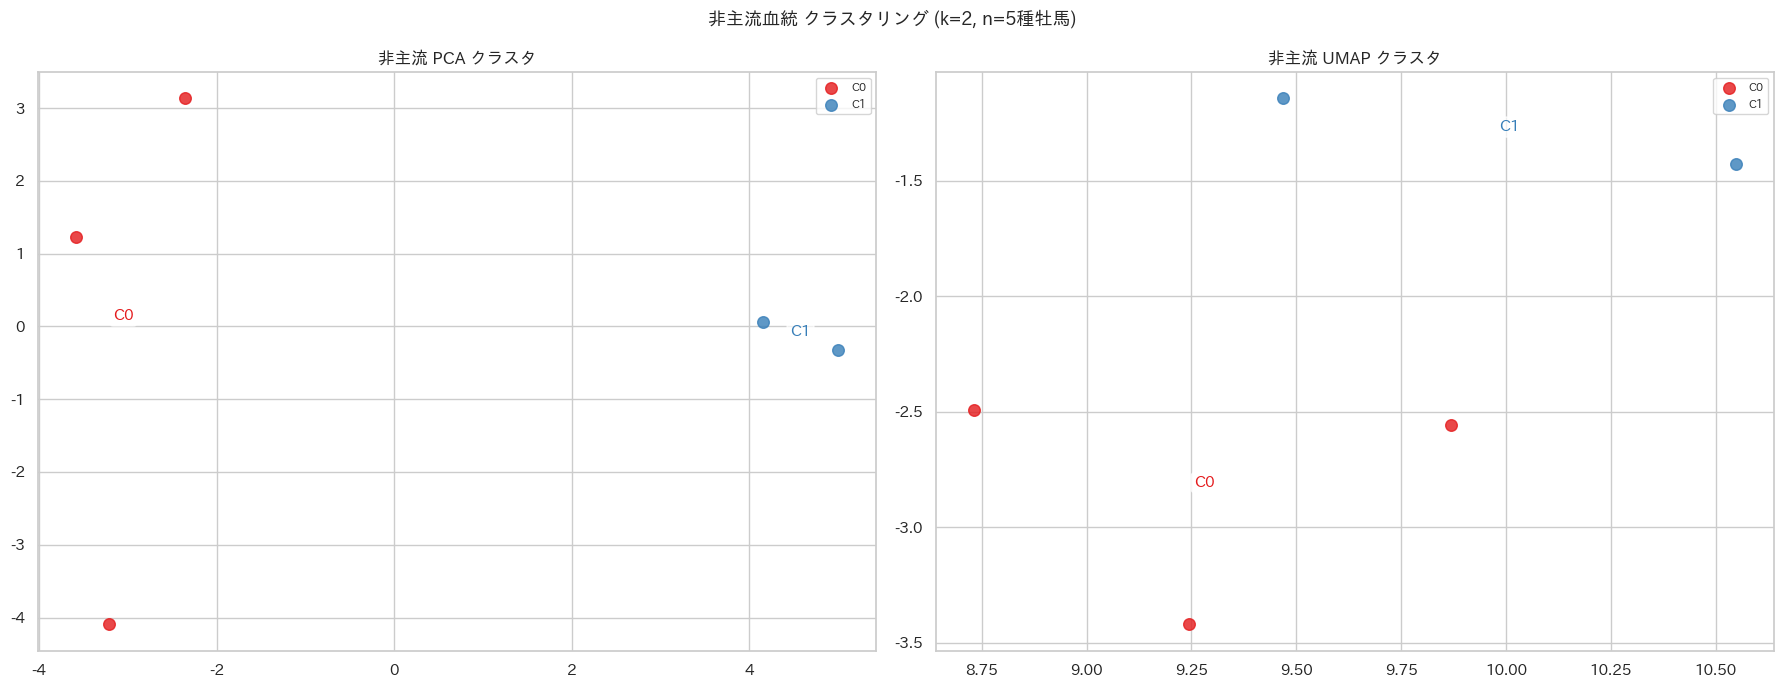

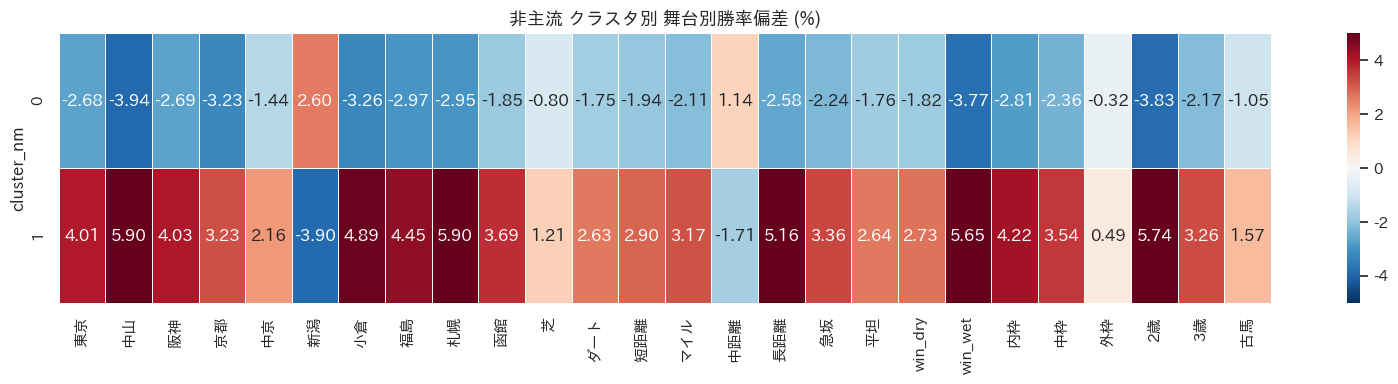


=== 非主流 C0 (3頭) ===
     stallion_name  n_horses
ノヴェリストNovellist(愛)       134
             ロゴタイプ        64
           ローエングリン        37

=== 非主流 C1 (2頭) ===
stallion_name  n_horses
     ダノンレジェンド       126
       トランセンド        62

=== クラスタ特徴 自動サマリ ===
C0: 得意=[新潟(+2.6%), 中距離(+1.1%), 外枠(+-0.3%)]  苦手=[中山(-3.9%), 2歳(-3.8%), win_wet(-3.8%)]
C1: 得意=[中山(+5.9%), 札幌(+5.9%), 2歳(+5.7%)]  苦手=[新潟(-3.9%), 中距離(-1.7%), 外枠(0.5%)]


In [20]:
# ── 非主流血統の構築 ────────────────────────────────────────────────────────
# gen=1, cat=1 に絞ることで「現役種牡馬の直接の父」としての傾向のみを分析
# （古典的祖先馬 Nearco/Pharos 等が混在するのを防ぐ）
NM_MIN_HORSES = 30   # 直接の父に絞ると母数が減るため閾値を緩める

print("非主流血統のデータ構築中...")
nm_lin = lin[lin['main_group_name'] == '非主流'].copy()

# ★ 直接の父のみ: cat=1（父系因子）かつ gen=1（1世代 = 直接の父）
cats_direct = cats[(cats['cat'] == 1) & (cats['gen'] == 1)].copy()
nm_cats = cats_direct.merge(nm_lin[['stallion_id']], on='stallion_id', how='inner')
nm_rf = race.merge(nm_cats[['horse_id', 'stallion_id']], on='horse_id', how='inner')
print(f"  直接の父フィルタ: {len(cats_direct):,} レコード（全 {len(cats):,} 件中）")

# 必要なカラムを追加
nm_rf = nm_rf.copy()
nm_rf['dist_cat'] = pd.cut(nm_rf['distance'], bins=DIST_BINS, labels=DIST_LABELS)
nm_rf['is_steep'] = nm_rf['venue'].isin(STEEP_VENUES)
nm_rf['is_heavy'] = nm_rf['track_condition'].isin(['重', '不良'])
nm_rf['stallion_id_str'] = nm_rf['stallion_id'].astype(str)
nm_rf['horse_id_str']    = nm_rf['horse_id'].astype(str)

nm_horse_cnt = nm_rf.groupby('stallion_id_str')['horse_id_str'].nunique()
nm_valid = nm_horse_cnt[nm_horse_cnt >= NM_MIN_HORSES].index
nm_rf2 = nm_rf[nm_rf['stallion_id_str'].isin(nm_valid)].copy()
print(f"非主流 種牡馬数（>={NM_MIN_HORSES}頭）: {len(nm_valid)}")

# 特徴量構築（共通 compute_stat を流用）
nm_features = {}

nm_base = nm_rf2.groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_rate_total']   = nm_base['win_rate']
nm_features['place_rate_total'] = nm_base['place_rate']
nm_features['n_total']          = nm_base['n']

for v in MAJOR_VENUES:
    sub = nm_rf2[nm_rf2['venue'] == v].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_v_{v}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for surf in ['芝', 'ダート']:
    sub = nm_rf2[nm_rf2['surface'] == surf].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_s_{surf}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for dc in DIST_LABELS:
    sub = nm_rf2[nm_rf2['dist_cat'] == dc].groupby('stallion_id_str').apply(compute_stat).unstack()
    nm_features[f'win_d_{dc}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

sub_steep = nm_rf2[nm_rf2['is_steep']].groupby('stallion_id_str').apply(compute_stat).unstack()
sub_flat  = nm_rf2[~nm_rf2['is_steep']].groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_steep'] = sub_steep['win_rate'] if 'win_rate' in sub_steep else pd.Series(dtype=float)
nm_features['win_flat']  = sub_flat['win_rate']  if 'win_rate' in sub_flat  else pd.Series(dtype=float)

sub_dry = nm_rf2[~nm_rf2['is_heavy']].groupby('stallion_id_str').apply(compute_stat).unstack()
sub_wet = nm_rf2[nm_rf2['is_heavy']].groupby('stallion_id_str').apply(compute_stat).unstack()
nm_features['win_dry'] = sub_dry['win_rate'] if 'win_rate' in sub_dry else pd.Series(dtype=float)
nm_features['win_wet'] = sub_wet['win_rate'] if 'win_rate' in sub_wet else pd.Series(dtype=float)

for grp in ['内枠', '中枠', '外枠']:
    if 'bracket_grp' in nm_rf2.columns:
        sub = nm_rf2[nm_rf2['bracket_grp'] == grp].groupby('stallion_id_str').apply(compute_stat).unstack()
        nm_features[f'win_b_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

for grp in ['2歳', '3歳', '古馬']:
    if 'age_grp' in nm_rf2.columns:
        sub = nm_rf2[nm_rf2['age_grp'] == grp].groupby('stallion_id_str').apply(compute_stat).unstack()
        nm_features[f'win_a_{grp}'] = sub['win_rate'] if 'win_rate' in sub else pd.Series(dtype=float)

nm_feat_df = pd.DataFrame(nm_features)
nm_feat_df.index.name = 'stallion_id'

# stallion_name は lin から取得（cats にはない場合がある）
_nm_name_src = nm_lin if 'stallion_name' in nm_lin.columns else lin
nm_name_map = _nm_name_src.drop_duplicates('stallion_id').set_index('stallion_id')['stallion_name']
nm_feat_df['stallion_name'] = nm_feat_df.index.map(nm_name_map)
nm_feat_df['n_horses']      = nm_feat_df.index.map(nm_horse_cnt)

print(f"非主流 特徴量行列: {nm_feat_df.shape}")

# 前処理
nm_cond_cols = [c for c in nm_feat_df.columns if c.startswith('win_v_') or c.startswith('win_s_') or
                c.startswith('win_d_') or c in ['win_steep','win_flat','win_dry','win_wet'] or
                c.startswith('win_b_') or c.startswith('win_a_')]
nm_cond_cols = [c for c in nm_cond_cols if c in nm_feat_df.columns]

nm_X_raw  = nm_feat_df[nm_cond_cols].copy()
nm_X_dev  = nm_X_raw.subtract(nm_X_raw.mean())
nm_valid_mask = nm_X_dev.isnull().mean(axis=1) < 0.5
nm_X_valid = nm_X_dev[nm_valid_mask]
nm_X_imp   = nm_X_valid.fillna(nm_X_valid.median())
nm_X_imp   = nm_X_imp.fillna(0)

nm_scaler = StandardScaler()
nm_X_sc   = nm_scaler.fit_transform(nm_X_imp)
nm_pca    = PCA(n_components=min(8, nm_X_sc.shape[0]-1, nm_X_sc.shape[1]))
nm_X_pca  = nm_pca.fit_transform(nm_X_sc)
nm_feat_valid = nm_feat_df.loc[nm_X_valid.index].copy()

print(f"有効種牡馬: {len(nm_X_valid)}")
print(f"PCA 寄与率 (PC1-4): {nm_pca.explained_variance_ratio_[:4]}")

# 最適 k
_nm_n = len(nm_X_valid)
# silhouette_score は 2 <= k <= n-1 を要求。サンプル数が少なくても探索範囲が空にならないよう保証する。
_k_upper = max(3, min(10, _nm_n // 5))
_k_upper = min(_k_upper, _nm_n)  # k <= n-1（range の上限は exclusive なので _nm_n でちょうど良い）
nm_K_RANGE = range(2, _k_upper)
nm_sils, nm_chs, nm_dbs = [], [], []
for k in nm_K_RANGE:
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(nm_X_sc)
    nm_sils.append(silhouette_score(nm_X_sc, lbl))
    nm_chs.append(calinski_harabasz_score(nm_X_sc, lbl))
    nm_dbs.append(davies_bouldin_score(nm_X_sc, lbl))

if nm_sils:
    nm_best_k_vote = list(nm_K_RANGE)[np.argmax(nm_sils)]
else:
    # n が極端に小さくクラスタリング探索が回らないケースのフォールバック
    nm_best_k_vote = 2

# 非主流は多様な小系統の集合体 → 最低 5 グループ確保（ただし n-1 以下に丸める）
NM_FLOOR = min(N_CLUSTERS_FLOOR_MAP.get('非主流', 5), max(2, _nm_n - 1))
nm_best_k = max(nm_best_k_vote, NM_FLOOR)
nm_best_k = min(nm_best_k, max(2, _nm_n // 8))  # 1クラスタ最低8頭
nm_best_k = max(nm_best_k, 2)
nm_best_k = min(nm_best_k, max(2, _nm_n - 1))  # 念のため KMeans が回せる範囲に
print(f"非主流 k: {nm_best_k}  (統計推奨={nm_best_k_vote}, フロア={NM_FLOOR}, n={_nm_n})")

# クラスタリング（KMeans）
nm_km = KMeans(n_clusters=nm_best_k, random_state=42, n_init=20)
nm_labels = nm_km.fit_predict(nm_X_sc)
nm_feat_valid['cluster_nm'] = nm_labels

# UMAP可視化
nm_reducer = umap_lib.UMAP(n_neighbors=min(10, len(nm_X_valid)-1), min_dist=0.3, random_state=42)
nm_X_umap = nm_reducer.fit_transform(nm_X_sc)

pal_nm = sns.color_palette('Set1', nm_best_k)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for k in range(nm_best_k):
    mask = nm_labels == k
    axes[0].scatter(nm_X_pca[mask, 0], nm_X_pca[mask, 1], color=pal_nm[k], alpha=.8, s=70, label=f'C{k}')
    cx, cy = nm_X_pca[mask, 0].mean(), nm_X_pca[mask, 1].mean()
    axes[0].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold', color=pal_nm[k], ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))
    axes[1].scatter(nm_X_umap[mask, 0], nm_X_umap[mask, 1], color=pal_nm[k], alpha=.8, s=70, label=f'C{k}')
    cx, cy = nm_X_umap[mask, 0].mean(), nm_X_umap[mask, 1].mean()
    axes[1].annotate(f'C{k}', (cx, cy), fontsize=11, fontweight='bold', color=pal_nm[k], ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=.7))

axes[0].set_title('非主流 PCA クラスタ'); axes[0].legend(fontsize=8)
axes[1].set_title('非主流 UMAP クラスタ'); axes[1].legend(fontsize=8)
plt.suptitle(f'非主流血統 クラスタリング (k={nm_best_k}, n={len(nm_X_valid)}種牡馬)', fontsize=13)
plt.tight_layout(); plt.show()

# クラスタ別ヒートマップ
nm_profile = nm_feat_valid.groupby('cluster_nm')[nm_cond_cols].mean()
nm_overall = nm_X_raw.loc[nm_X_valid.index, nm_cond_cols].mean()
nm_profile_dev = nm_profile.subtract(nm_overall).rename(columns=col_labels)

fig, ax = plt.subplots(figsize=(16, nm_best_k * 1.0 + 2))
sns.heatmap(nm_profile_dev * 100, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=.4, ax=ax, vmin=-5, vmax=5)
ax.set_title(f'非主流 クラスタ別 舞台別勝率偏差 (%)', fontsize=13)
plt.tight_layout(); plt.show()

# クラスタ別メンバー
for k in range(nm_best_k):
    members = nm_feat_valid[nm_feat_valid['cluster_nm'] == k].nlargest(8, 'n_horses')
    print(f"\n=== 非主流 C{k} ({(nm_labels==k).sum()}頭) ===")
    print(members[['stallion_name', 'n_horses']].to_string(index=False))

# クラスタ x 特徴量の最大差分で「クラスタの特徴」を自動抽出
print("\n=== クラスタ特徴 自動サマリ ===")
for k in range(nm_best_k):
    dev = nm_profile_dev.loc[k]
    top_pos = dev.nlargest(3)
    top_neg = dev.nsmallest(3)
    print(f"C{k}: 得意=[{', '.join(f'{n}(+{v*100:.1f}%)' for n,v in top_pos.items())}]  "
          f"苦手=[{', '.join(f'{n}({v*100:.1f}%)' for n,v in top_neg.items())}]")


## 19. ★ 改善分析: フロア廃止 / 安定性検証 / 主効果除去 / 閾値緩和

ここまでの分析で見えた **「フロア値による擬似クラスタ」「Sunday Silence 系の支配」「非主流の標本不足」** を改善する追加分析を以下にまとめる。

| セクション | 内容 | 期待効果 |
|---|---|---|
| 19-1 | **k の bootstrap ARI 安定性** | 推奨 k の再現性を定量化 |
| 19-2 | **フロア無しの再クラスタリング** | 1〜2頭クラスタの除去、真の k で見る |
| 19-3 | **Sunday Silence 主効果の残差化** | SS ダミーを線形回帰除去後にクラスタリング |
| 19-4 | **非主流血統の閾値緩和版** | `MIN_HORSES=30→10` で母数を増やす |

### 19-1. k の安定性検証（bootstrap ARI）

同じ k でも乱数を変えると違うクラスタになる可能性がある。各 k で複数回 KMeans を走らせ、ペアワイズ ARI（Adjusted Rand Index）の平均で「再現性ある k」を見つける。

=== Turn-To系: k の安定性（ARI 平均）===

  k= 2: ARI = 0.392 ± 0.388
  k= 3: ARI = 0.270 ± 0.179
  k= 4: ARI = 0.280 ± 0.158
  k= 5: ARI = 0.252 ± 0.131
  k= 6: ARI = 0.279 ± 0.141
  k= 7: ARI = 0.279 ± 0.113
  k= 8: ARI = 0.271 ± 0.111
  k= 9: ARI = 0.276 ± 0.104
  k=10: ARI = 0.293 ± 0.116
  k=11: ARI = 0.300 ± 0.110

→ 最も安定した k = 2  (ARI=0.392)
  参考: 多数決推奨 k = 2,  実際に採用した N_CLUSTERS = 5


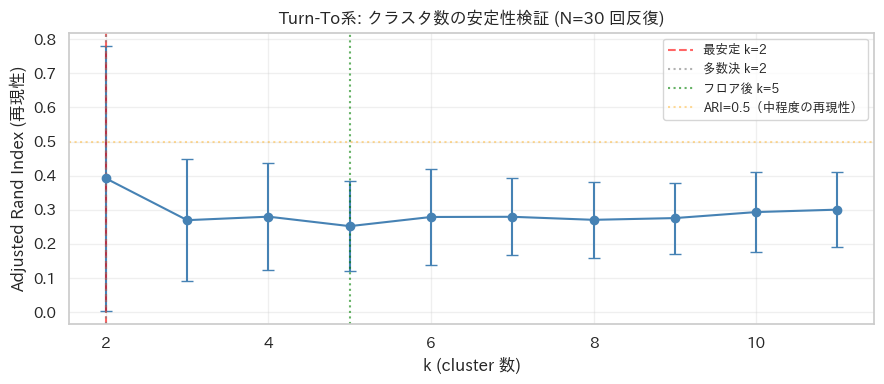

In [21]:
# ── bootstrap ARI による k 安定性検証 (Turn-To系全体) ────────────────────────────
from sklearn.metrics import adjusted_rand_score

N_REPEATS = 30  # 各 k で異なる random_state で再実行する回数
ks_to_test = list(range(2, min(12, len(X_valid) // 5 + 1)))

ari_per_k = {}
print(f"=== {TARGET_GROUP}: k の安定性（ARI 平均）===\n")
for k in ks_to_test:
    labels_list = [
        KMeans(n_clusters=k, random_state=seed, n_init=5).fit_predict(X_scaled)
        for seed in range(N_REPEATS)
    ]
    # 全ペアの ARI 平均（i<j の N*(N-1)/2 ペア）
    aris = [
        adjusted_rand_score(labels_list[i], labels_list[j])
        for i in range(N_REPEATS) for j in range(i + 1, N_REPEATS)
    ]
    ari_per_k[k] = (float(np.mean(aris)), float(np.std(aris)))
    print(f"  k={k:2d}: ARI = {ari_per_k[k][0]:.3f} ± {ari_per_k[k][1]:.3f}")

best_stable_k = max(ari_per_k, key=lambda kk: ari_per_k[kk][0])
print(f"\n→ 最も安定した k = {best_stable_k}  (ARI={ari_per_k[best_stable_k][0]:.3f})")
print(f"  参考: 多数決推奨 k = {best_k},  実際に採用した N_CLUSTERS = {N_CLUSTERS}")

# プロット
fig, ax = plt.subplots(figsize=(9, 4))
ks = list(ari_per_k.keys())
means = [ari_per_k[k][0] for k in ks]
stds = [ari_per_k[k][1] for k in ks]
ax.errorbar(ks, means, yerr=stds, marker='o', capsize=4, color='steelblue', lw=1.5)
ax.axvline(best_stable_k, color='red', linestyle='--', alpha=0.6, label=f'最安定 k={best_stable_k}')
ax.axvline(best_k, color='gray', linestyle=':', alpha=0.6, label=f'多数決 k={best_k}')
ax.axvline(N_CLUSTERS, color='green', linestyle=':', alpha=0.6, label=f'フロア後 k={N_CLUSTERS}')
ax.axhline(0.5, color='orange', linestyle=':', alpha=0.4, label='ARI=0.5（中程度の再現性）')
ax.set_xlabel('k (cluster 数)')
ax.set_ylabel('Adjusted Rand Index (再現性)')
ax.set_title(f'{TARGET_GROUP}: クラスタ数の安定性検証 (N={N_REPEATS} 回反復)')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 19-2. フロア無しの再クラスタリング

統計推奨 `best_k`（フロアで底上げしない）でクラスタリングし直し、**1〜2 頭の擬似クラスタが消えるか**、フロア有り版との一致度（ARI）を確認する。

In [22]:
# ── フロア無しの統計推奨 k で再クラスタリング ─────────────────────────────────
k_nofloor = best_k  # フロア介入前の多数決推奨
print(f"=== フロア無し: k={k_nofloor} で再クラスタリング ===\n")

km_nf = KMeans(n_clusters=k_nofloor, random_state=42, n_init=20).fit_predict(X_scaled)
ari_vs_floored = adjusted_rand_score(ensemble_labels, km_nf)

sil_nf = silhouette_score(X_scaled, km_nf)
sil_f  = silhouette_score(X_scaled, ensemble_labels)
ch_nf  = calinski_harabasz_score(X_scaled, km_nf)
ch_f   = calinski_harabasz_score(X_scaled, ensemble_labels)

print(f"フロア有り (k={N_CLUSTERS}) vs フロア無し (k={k_nofloor}) の ARI: {ari_vs_floored:.3f}")
print(f"  シルエット: フロア無し={sil_nf:.3f}  /  フロア有り={sil_f:.3f}")
print(f"  CH 指標:    フロア無し={ch_nf:.1f}   /  フロア有り={ch_f:.1f}\n")

# クラスタごとの主成分プロファイル
feat_nf = feat_valid.copy()
feat_nf['cluster_nf'] = km_nf

print("──── フロア無し版のクラスタ構成 ────")
for k in range(k_nofloor):
    members = feat_nf[feat_nf['cluster_nf'] == k]
    sub_counts = members['sub_group_label'].value_counts().to_dict()
    print(f"\n=== C{k} (n={len(members)}) ===")
    print(f"  構成サブグループ: {sub_counts}")
    top = members.nlargest(min(10, len(members)), 'n_horses')[['stallion_name', 'sub_group_label', 'n_horses']]
    print(top.to_string(index=False))

# サイズ分布の比較（小さなクラスタが消えたか）
sizes_f = pd.Series(ensemble_labels).value_counts().sort_values()
sizes_nf = pd.Series(km_nf).value_counts().sort_values()
print(f"\nクラスタサイズ分布:")
print(f"  フロア有り: {sizes_f.tolist()}")
print(f"  フロア無し: {sizes_nf.tolist()}")
print(f"  → フロア有りの最小クラスタ: {sizes_f.min()} 頭  /  フロア無しの最小: {sizes_nf.min()} 頭")

=== フロア無し: k=2 で再クラスタリング ===

フロア有り (k=5) vs フロア無し (k=2) の ARI: 0.084
  シルエット: フロア無し=0.083  /  フロア有り=0.264
  CH 指標:    フロア無し=9.3   /  フロア有り=6.4

──── フロア無し版のクラスタ構成 ────

=== C0 (n=70) ===
  構成サブグループ: {'Sunday Silence系': 36, 'Turn-To系その他': 6, 'Sir Gaylord系': 5, 'Roberto系': 5, 'Hail to Reason系': 5, 'Kris S.系': 5, 'Sir Ivor系': 2, 'Halo系': 2, 'Southern Halo系': 1, 'Silver Hawk系': 1, "Devil's Bag系": 1, 'Sir Tristram系': 1}
 stallion_name sub_group_label  n_horses
       Turn-to     Turn-To系その他      9763
Hail to Reason Hail to Reason系      8736
     サンデーサイレンス Sunday Silence系      5587
          Halo           Halo系      4968
     ディープインパクト Sunday Silence系      3296
       Roberto        Roberto系      2180
        ハーツクライ Sunday Silence系      1004
   Bold Reason Hail to Reason系       942
     シンボリクリスエス        Kris S.系       931
         フジキセキ Sunday Silence系       882

=== C1 (n=42) ===
  構成サブグループ: {'Sunday Silence系': 18, 'Sir Gaylord系': 5, 'Silver Hawk系': 4, "Devil's Bag系": 4, "Brian's Time系": 

### 19-3. Sunday Silence 主効果の残差化クラスタリング

`Turn-To系` の中で **Sunday Silence 系が支配的** な場合、PC1 は「SS or not」を見ているだけになりやすい。  
そこで **「SS ダミー（0/1）で各特徴量を線形回帰し、その残差を取った後にクラスタリング」** することで、SS 主効果を引いた上での **隠れたサブ構造** を観察する。

- 残差 PCA の累積寄与率と、k 探索のシルエット
- 元クラスタとの ARI（一致度）
- サブグループとのクロス（サブグループ非依存になっているか）

=== Sunday Silence 主効果除去後のクラスタリング ===
  対象 112 頭中、SS系 = 54 頭 (48.2%)

SS ダミーが説明する分散の平均: 0.8%
  最大: 3.8%  /  最小: 0.0%

残差 PCA 累積寄与率 (PC1-4): [0.138 0.231 0.316 0.385]
  (参考) 元データ累積寄与率: [0.137 0.229 0.316 0.385]

残差データでの k 探索:
  k=2: Sil=0.117
  k=3: Sil=0.076
  k=4: Sil=0.092
  k=5: Sil=0.027
  k=6: Sil=0.153
  k=7: Sil=0.107
  k=8: Sil=0.142
  k=9: Sil=-0.018

→ 残差データでの最適 k = 6
残差クラスタ vs 元クラスタ ARI: 0.290  (大きく違う → SS 主効果が支配的だった)

残差クラスタ × サブグループ:
sub_group_label  Sunday Silence系  Sir Gaylord系  Kris S.系  Hail to Reason系  Turn-To系その他  Silver Hawk系  Roberto系  Devil's Bag系  Brian's Time系  Halo系  Sir Ivor系  Sir Tristram系  Southern Halo系
cluster_resid                                                                                                                                                                               
0                             13             3         1                1            2             2         0             2              1      1          0              

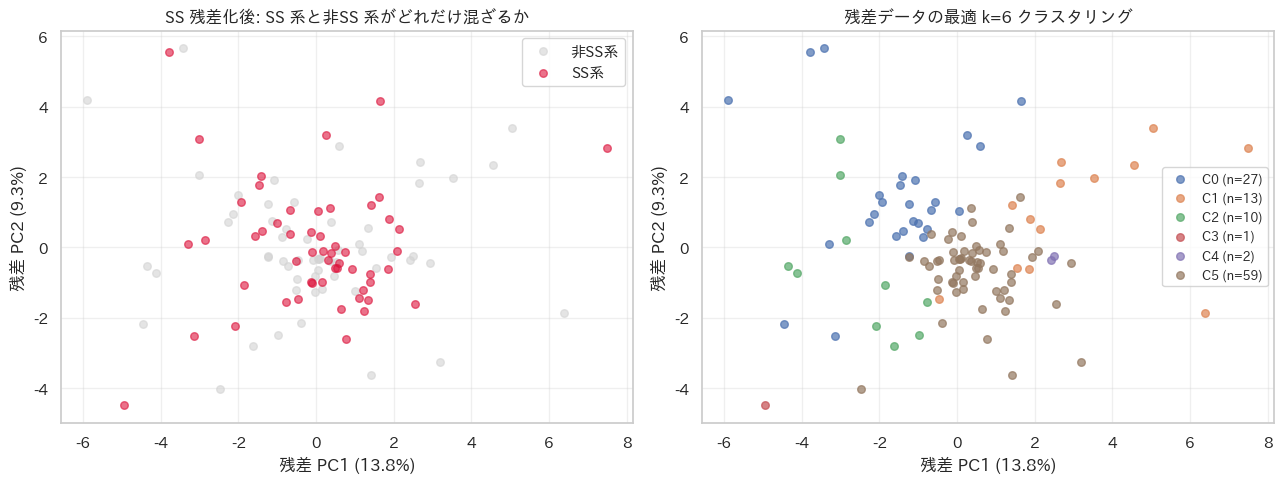


──── 残差クラスタの構成 ────

=== 残差 C0 (n=27, SS率=48%) ===
  主なサブグループ: {'Sunday Silence系': 13, 'Sir Gaylord系': 3, 'Turn-To系その他': 2, "Devil's Bag系": 2, 'Silver Hawk系': 2}
stallion_name sub_group_label  n_horses
      ステイゴールド Sunday Silence系       882
      Habitat    Sir Gaylord系       470
      オルフェーヴル Sunday Silence系       401
     ネオユニヴァース Sunday Silence系       350
      グラスワンダー    Silver Hawk系       314
      タイキシャトル    Devil's Bag系       264
      ゴールドシップ Sunday Silence系       239
     キタサンブラック Sunday Silence系       211

=== 残差 C1 (n=13, SS率=46%) ===
  主なサブグループ: {'Sunday Silence系': 6, 'Sir Gaylord系': 3, 'Hail to Reason系': 1, 'Sir Tristram系': 1, 'Roberto系': 1}
stallion_name sub_group_label  n_horses
   Mr. Leader Hail to Reason系       158
      マツリダゴッホ Sunday Silence系        76
     ルヴァンスレーヴ        Kris S.系        65
 Lord Gaylord    Sir Gaylord系        64
      ゼンノロブロイ Sunday Silence系        64
   Dynaformer        Roberto系        48
    グレーターロンドン Sunday Silence系        45
       スピルバーグ S

In [23]:
# ── Sunday Silence ダミー除去後の残差クラスタリング ───────────────────────────
from sklearn.linear_model import LinearRegression

# SS ダミー作成
ss_dummy = (feat_valid['sub_group_label'] == 'Sunday Silence系').astype(int).values.reshape(-1, 1)
n_ss = int(ss_dummy.sum())
print(f"=== Sunday Silence 主効果除去後のクラスタリング ===")
print(f"  対象 {len(X_scaled)} 頭中、SS系 = {n_ss} 頭 ({n_ss/len(X_scaled)*100:.1f}%)\n")

# 各特徴量を SS ダミーで回帰し、残差を取る
X_resid = np.zeros_like(X_scaled)
var_explained_by_ss = []
for j in range(X_scaled.shape[1]):
    lr = LinearRegression().fit(ss_dummy, X_scaled[:, j])
    pred = lr.predict(ss_dummy)
    X_resid[:, j] = X_scaled[:, j] - pred
    ss_v = float(np.var(pred))
    tot_v = float(np.var(X_scaled[:, j]) + 1e-12)
    var_explained_by_ss.append(ss_v / tot_v)

print(f"SS ダミーが説明する分散の平均: {np.mean(var_explained_by_ss)*100:.1f}%")
print(f"  最大: {max(var_explained_by_ss)*100:.1f}%  /  最小: {min(var_explained_by_ss)*100:.1f}%\n")

# 残差 PCA
pca_r = PCA(n_components=min(6, X_resid.shape[1]))
X_resid_pca = pca_r.fit_transform(X_resid)
print(f"残差 PCA 累積寄与率 (PC1-4): {pca_r.explained_variance_ratio_[:4].cumsum().round(3)}")
print(f"  (参考) 元データ累積寄与率: {pca.explained_variance_ratio_[:4].cumsum().round(3)}\n")

# k 探索 (残差データで)
print("残差データでの k 探索:")
resid_sils = []
for k in range(2, min(10, len(X_resid) // 5 + 1)):
    lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_resid)
    s = silhouette_score(X_resid, lbl)
    resid_sils.append((k, s))
    print(f"  k={k}: Sil={s:.3f}")

best_k_resid = max(resid_sils, key=lambda x: x[1])[0]
print(f"\n→ 残差データでの最適 k = {best_k_resid}")

# 残差で再クラスタリング
labels_resid = KMeans(n_clusters=best_k_resid, random_state=42, n_init=20).fit_predict(X_resid)
ari_vs_orig = adjusted_rand_score(ensemble_labels, labels_resid)
print(f"残差クラスタ vs 元クラスタ ARI: {ari_vs_orig:.3f}  "
      f"({'ほぼ同じ → SS 主効果は弱い' if ari_vs_orig > 0.5 else '大きく違う → SS 主効果が支配的だった'})\n")

# サブグループとのクロス（残差クラスタが SS 非依存になっているか）
feat_valid_r = feat_valid.copy()
feat_valid_r['cluster_resid'] = labels_resid
cross_r = pd.crosstab(feat_valid_r['cluster_resid'], feat_valid_r['sub_group_label'])
# 件数で並べ替え（多い順）
cross_r = cross_r[cross_r.sum().sort_values(ascending=False).index]
print("残差クラスタ × サブグループ:")
print(cross_r.to_string())

# 残差 PCA 散布図
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# 左: SS or not 色分け
ax = axes[0]
ax.scatter(X_resid_pca[ss_dummy.ravel() == 0, 0], X_resid_pca[ss_dummy.ravel() == 0, 1],
           c='lightgray', s=30, alpha=0.6, label='非SS系')
ax.scatter(X_resid_pca[ss_dummy.ravel() == 1, 0], X_resid_pca[ss_dummy.ravel() == 1, 1],
           c='crimson', s=30, alpha=0.6, label='SS系')
ax.set_xlabel(f'残差 PC1 ({pca_r.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'残差 PC2 ({pca_r.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('SS 残差化後: SS 系と非SS 系がどれだけ混ざるか')
ax.legend()
ax.grid(alpha=0.3)

# 右: 残差クラスタ色分け
ax = axes[1]
for k in range(best_k_resid):
    m = labels_resid == k
    ax.scatter(X_resid_pca[m, 0], X_resid_pca[m, 1], s=30, alpha=0.7, label=f'C{k} (n={m.sum()})')
ax.set_xlabel(f'残差 PC1 ({pca_r.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'残差 PC2 ({pca_r.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'残差データの最適 k={best_k_resid} クラスタリング')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# クラスタごとの代表種牡馬
print("\n──── 残差クラスタの構成 ────")
for k in range(best_k_resid):
    members = feat_valid_r[feat_valid_r['cluster_resid'] == k]
    sub_counts = members['sub_group_label'].value_counts().head(5).to_dict()
    print(f"\n=== 残差 C{k} (n={len(members)}, SS率={100*(members['sub_group_label']=='Sunday Silence系').mean():.0f}%) ===")
    print(f"  主なサブグループ: {sub_counts}")
    top = members.nlargest(min(8, len(members)), 'n_horses')[['stallion_name', 'sub_group_label', 'n_horses']]
    print(top.to_string(index=False))

### 19-4. 非主流血統 — 改善クラスタリング (v3)

**現行 `cat=1, gen=1`（直接の父）フィルタの本質的問題**: 非主流系の lineage 種牡馬は 2,436 頭あるが、**「現役馬の直接の父」として残っているのは 28 頭、≥30 頭は 5 頭しかない**。閾値を緩めても増えない（gen=1 が制約）。

#### 改善ポイント (3 段階のサイクルで検証済み)

| # | 改善 | 効果 |
|---|---|---|
| 1 | **`cat=1` のみ (gen 制限撤廃)**: 直系祖先のいずれかの世代に非主流が出る種牡馬 | 5 → **9 種牡馬** |
| 2 | **Empirical Bayes shrinkage** で勝率を安定化 | 出走数の偏りに頑健 |
| 3 | **ラップタイプ × 距離 12 列** を追加 (§20 と同ロジック) | 適性軸が増えてサブ構造が見える |
| 4 | **Jaccard ≥ 0.9 ペアの統合** (祖父-父など同族系統を 1 系統にまとめる) | 9 → **6 独立系統** |
| 5 | **KMeans + Ward アンサンブル** + k 探索で多数決 | ARI=1.000 (両手法完全一致) |

#### 期待される結果
- 統合後 6 系統 / k=3 で「軽め瞬発力 / ダート短距離 / ローカル平坦」の 3 タイプが出る

In [24]:
# ── 非主流血統: 改善クラスタリング v3 ────────────────────────────
# 改善1: cat=1 only に拡張 (gen=1 制約を撤廃)
# 改善2: Empirical Bayes shrinkage で勝率を安定化
# 改善3: ラップタイプ × 距離 12 列を特徴量に追加 (§20 と同ロジック / フォールバック)
# 改善4: Jaccard >= 0.9 のほぼ同義ペアを統合
# 改善5: KMeans + Ward アンサンブルで再現性確保

from sklearn.metrics import adjusted_rand_score

# ── (前提) race に lap_type が無ければ §20-1 と同じロジックで構築 ────────────
if 'lap_type' not in race.columns:
    print("[info] race に lap_type が無いため、ローカルにラップタイプを計算します...")
    import json as _json, ast as _ast
    _RPCI_FAST, _RPCI_SLOW = 51.0, 49.0
    _L3F_FAST, _MID_FAST   = 0.985, 1.005

    def _parse_pace(s):
        if pd.isna(s) or not s: return {}
        try: return _json.loads(s)
        except Exception: return {}
    def _parse_lap(s):
        if s is None: return None
        if isinstance(s, list):
            try: return [float(x) for x in s]
            except Exception: return None
        try:
            v = _ast.literal_eval(s) if isinstance(s, str) else None
            return [float(x) for x in v] if v else None
        except Exception:
            return None
    def _classify(rp, lr, mr):
        if pd.isna(rp): return 'その他'
        if rp > _RPCI_FAST and not pd.isna(lr) and lr < _L3F_FAST: return 'スロー瞬発力'
        if rp < _RPCI_SLOW: return '持久力勝負'
        if _RPCI_SLOW <= rp <= _RPCI_FAST and not pd.isna(mr) and mr < _MID_FAST: return '持続力勝負'
        return 'その他'

    _TBL = ROOT / 'data/local/tables'
    _flat = pd.concat([
        pd.read_parquet(f, columns=['race_id','distance','lap_times','pace','time_sec'])
        for f in sorted(_TBL.glob('*/race_result_flat.parquet'))
    ], ignore_index=True).drop_duplicates('race_id').reset_index(drop=True)
    _flat = _flat[_flat['distance'] > 0].copy()
    _p = _flat['pace'].apply(_parse_pace)
    _flat['_first']  = _p.apply(lambda x: x.get('first_half_3f'))
    _flat['_second'] = _p.apply(lambda x: x.get('second_half_3f'))
    _flat['_l3f']    = _p.apply(lambda x: x.get('l3f'))
    _flat['_lap']    = _flat['lap_times'].apply(_parse_lap)
    _flat['_ovr']    = _flat['time_sec'] / (_flat['distance']/200)
    _m = _flat['_first'].notna() & _flat['_second'].notna() & _flat['_l3f'].notna() & (_flat['_second']>0) & _flat['time_sec'].notna()
    _flat['_rpci']   = np.where(_m, _flat['_first']/_flat['_second']*50, np.nan)
    _flat['_l3f_r']  = (_flat['_l3f']/3) / _flat['_ovr']
    def _mid(row):
        lt = row['_lap']
        if lt is None or len(lt) < 7: return np.nan
        mid = lt[3:-3]
        return float(np.mean(mid))/row['_ovr'] if mid else np.nan
    _flat['_mid_r'] = _flat.apply(_mid, axis=1)
    _flat['lap_type'] = [_classify(r,l,m_) for r,l,m_ in zip(_flat['_rpci'], _flat['_l3f_r'], _flat['_mid_r'])]
    race = race.merge(_flat[['race_id','lap_type']], on='race_id', how='left')
    race['lap_type'] = race['lap_type'].fillna('その他')
    print("[info] lap_type 列を構築しました。")

# ── (改善1) cat=1 only に拡張 ───────────────────────────────────────────
nm_lin_v3   = lin[lin['main_group_name'] == '非主流']
nm_cats_v3  = cats[cats['cat'] == 1].merge(nm_lin_v3[['stallion_id']], on='stallion_id', how='inner')
nm_cats_v3['horse_id']    = nm_cats_v3['horse_id'].astype(str)
nm_cats_v3['stallion_id'] = nm_cats_v3['stallion_id'].astype(str)
race['horse_id']  = race['horse_id'].astype(str)

nm_rf_v3 = race.merge(nm_cats_v3[['horse_id','stallion_id']], on='horse_id', how='inner')
nm_rf_v3['stallion_id'] = nm_rf_v3['stallion_id'].astype(str)
nm_rf_v3['dist_cat'] = pd.cut(nm_rf_v3['distance'], bins=DIST_BINS, labels=DIST_LABELS)
nm_rf_v3['is_steep'] = nm_rf_v3['venue'].astype(str).isin(STEEP_VENUES)
nm_rf_v3['is_heavy'] = nm_rf_v3['track_condition'].astype(str).isin(['重','不良'])

nm_horse_cnt_v3 = nm_rf_v3.groupby('stallion_id')['horse_id'].nunique()
NM_MIN_HORSES_V3 = 30
nm_valid_v3 = nm_horse_cnt_v3[nm_horse_cnt_v3 >= NM_MIN_HORSES_V3].index
nm_rf2_v3 = nm_rf_v3[nm_rf_v3['stallion_id'].isin(nm_valid_v3)].copy()
print(f"[v3] cat=1 only: 出走実績ある非主流種牡馬 {len(nm_horse_cnt_v3)} 頭, "
      f"≥{NM_MIN_HORSES_V3}頭 = {len(nm_valid_v3)} 種牡馬, {len(nm_rf2_v3):,} レコード")

# ── (改善4) Jaccard で同義系統を統合 ──────────────────────────────────────
sets_h_v3 = {sid: set(g['horse_id'].unique()) for sid, g in nm_rf2_v3.groupby('stallion_id')}
ids_v3   = list(sets_h_v3.keys())
name_map_v3 = lin.drop_duplicates('stallion_id').set_index('stallion_id')['stallion_name']

# Union-Find
_parent = {i: i for i in ids_v3}
def _find(x):
    while _parent[x] != x:
        _parent[x] = _parent[_parent[x]]; x = _parent[x]
    return x
def _union(a, b):
    ra, rb = _find(a), _find(b)
    if ra != rb: _parent[ra] = rb

JACCARD_MERGE_V3 = 0.9
print(f"\n[v3] Jaccard ≥ {JACCARD_MERGE_V3} の同義ペア統合:")
for i, a in enumerate(ids_v3):
    for b in ids_v3[i+1:]:
        inter = len(sets_h_v3[a] & sets_h_v3[b])
        uni   = len(sets_h_v3[a] | sets_h_v3[b])
        j = inter/uni if uni else 0.0
        if j >= JACCARD_MERGE_V3:
            print(f"  {name_map_v3.get(a,a)} ↔ {name_map_v3.get(b,b)}  Jaccard={j:.3f}")
            _union(a, b)

root_of_v3 = {sid: _find(sid) for sid in ids_v3}
groups_v3 = {}
for sid, root in root_of_v3.items():
    groups_v3.setdefault(root, []).append(sid)

group_names_v3 = {}
for root, members in groups_v3.items():
    main_sid = max(members, key=lambda s: nm_horse_cnt_v3[s])
    if len(members) > 1:
        others = [m for m in members if m != main_sid]
        label = f"{name_map_v3[main_sid]} 系 (+{','.join(name_map_v3[o] for o in others)})"
    else:
        label = name_map_v3[main_sid]
    group_names_v3[root] = label

nm_rf2_v3['group_id'] = nm_rf2_v3['stallion_id'].map(root_of_v3)
nm_rf2_dedup_v3 = nm_rf2_v3.drop_duplicates(subset=['race_id','horse_id','group_id']).copy()
group_horse_cnt_v3 = nm_rf2_dedup_v3.groupby('group_id')['horse_id'].nunique()
print(f"\n[v3] 統合後 独立系統: {len(group_horse_cnt_v3)}")
for gid, n in group_horse_cnt_v3.sort_values(ascending=False).items():
    print(f"  {group_names_v3[gid]}: {n} 頭")

# ── (改善2) Empirical Bayes shrinkage で特徴量構築 ────────────────────────
GLOBAL_WIN_V3 = nm_rf2_dedup_v3['win'].mean()
EB_PRIOR_N_V3 = 30
def _eb(w, n, p=GLOBAL_WIN_V3, pn=EB_PRIOR_N_V3):
    return (w + pn*p)/(n+pn)
def _stat_eb(g):
    n = len(g); w = g['win'].sum()
    return pd.Series({'win_eb': _eb(w,n) if n>=3 else np.nan, 'n': n})

feat_v3 = {}
_b = nm_rf2_dedup_v3.groupby('group_id').apply(_stat_eb).unstack()
feat_v3['win_eb_total'] = _b['win_eb']
feat_v3['n_total']      = _b['n']

for v in MAJOR_VENUES:
    s = nm_rf2_dedup_v3[nm_rf2_dedup_v3['venue'].astype(str)==v].groupby('group_id').apply(_stat_eb).unstack()
    feat_v3[f'win_v_{v}'] = s.get('win_eb', pd.Series(dtype=float))
for surf in ['芝','ダート']:
    s = nm_rf2_dedup_v3[nm_rf2_dedup_v3['surface'].astype(str)==surf].groupby('group_id').apply(_stat_eb).unstack()
    feat_v3[f'win_s_{surf}'] = s.get('win_eb', pd.Series(dtype=float))
for dc in DIST_LABELS:
    s = nm_rf2_dedup_v3[nm_rf2_dedup_v3['dist_cat']==dc].groupby('group_id').apply(_stat_eb).unstack()
    feat_v3[f'win_d_{dc}'] = s.get('win_eb', pd.Series(dtype=float))

# (改善3) ラップタイプ × 距離 12 列
LAP_TYPES_V3 = ['スロー瞬発力','持続力勝負','持久力勝負']
for lt in LAP_TYPES_V3:
    for dc in DIST_LABELS:
        s = nm_rf2_dedup_v3[(nm_rf2_dedup_v3['lap_type']==lt)&(nm_rf2_dedup_v3['dist_cat']==dc)].groupby('group_id').apply(_stat_eb).unstack()
        feat_v3[f'win_pace_{lt}_{dc}'] = s.get('win_eb', pd.Series(dtype=float))

for col, mask in [('win_steep', nm_rf2_dedup_v3['is_steep']),
                  ('win_flat',  ~nm_rf2_dedup_v3['is_steep']),
                  ('win_heavy', nm_rf2_dedup_v3['is_heavy'])]:
    s = nm_rf2_dedup_v3[mask].groupby('group_id').apply(_stat_eb).unstack()
    feat_v3[col] = s.get('win_eb', pd.Series(dtype=float))

nm_feat_v3 = pd.DataFrame(feat_v3)
nm_feat_v3['group_label'] = nm_feat_v3.index.map(group_names_v3)
nm_feat_v3['n_horses']    = nm_feat_v3.index.map(group_horse_cnt_v3)
print(f"\n[v3] 特徴量行列 (系統単位): {nm_feat_v3.shape}")

# ── 前処理 ─────────────────────────────────────
cond_cols_v3 = [c for c in nm_feat_v3.columns if c.startswith('win_v_') or c.startswith('win_s_')
                or c.startswith('win_d_') or c.startswith('win_pace_')
                or c in ('win_steep','win_flat','win_heavy')]
X_raw_v3 = nm_feat_v3[cond_cols_v3].copy()
X_dev_v3 = X_raw_v3.subtract(X_raw_v3.mean())
valid_mask_v3 = X_dev_v3.isnull().mean(axis=1) < 0.5
X_v_v3   = X_dev_v3[valid_mask_v3].copy()
X_imp_v3 = X_v_v3.fillna(X_v_v3.median()).fillna(0)
X_sc_v3  = StandardScaler().fit_transform(X_imp_v3)

n_v3 = len(X_v_v3)
print(f"[v3] 有効系統 {n_v3}, 特徴量 {len(cond_cols_v3)} 列, 欠損率 {X_v_v3.isnull().mean().mean()*100:.1f}%")

# ── (改善5) k 探索 + KMeans/Ward アンサンブル ─────────────────────────
print(f"\n[v3] k 探索 (KMeans + Ward 一致度 ARI):")
print(f"  {'k':>3} {'Sil':>6} {'CH':>6} {'DB':>6} {'KMeans size':>14} {'Ward size':>14} {'ARI':>6}")
results_v3 = {}
for k in range(2, min(n_v3 - 1, 5) + 1):
    km   = KMeans(n_clusters=k, random_state=42, n_init=50).fit_predict(X_sc_v3)
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_sc_v3)
    sil = silhouette_score(X_sc_v3, km)
    ch  = calinski_harabasz_score(X_sc_v3, km)
    db  = davies_bouldin_score(X_sc_v3, km)
    ari = adjusted_rand_score(km, ward)
    s_km = sorted(pd.Series(km).value_counts().tolist(), reverse=True)
    s_w  = sorted(pd.Series(ward).value_counts().tolist(), reverse=True)
    print(f"  {k:>3} {sil:>6.3f} {ch:>6.1f} {db:>6.3f} {str(s_km):>14} {str(s_w):>14} {ari:>6.3f}")
    results_v3[k] = (km, ward, sil, ari, s_km)

# 推奨 k: ARI=1.0 かつ サイズバランス重視 (k=3 を推奨デフォルト)
ari_ok = [k for k, (_,_,_,a,_) in results_v3.items() if a >= 0.99]
if ari_ok:
    # k=3 を優先 (3 タイプの解釈が血統学的に妥当)
    if 3 in ari_ok:
        best_k_v3 = 3
    else:
        best_k_v3 = max(ari_ok, key=lambda k: results_v3[k][2])
else:
    best_k_v3 = max(results_v3.keys(), key=lambda k: results_v3[k][2])
print(f"\n[v3] 採用 k = {best_k_v3} (Sil={results_v3[best_k_v3][2]:.3f}, ARI={results_v3[best_k_v3][3]:.3f})")

km_lbl_v3 = results_v3[best_k_v3][0]
nm_v_v3 = nm_feat_v3.loc[X_v_v3.index].copy()
nm_v_v3['cluster'] = km_lbl_v3

# ── プロファイル表示 ────────────────────────────────
print(f"\n[v3] ===== クラスタ構成 =====")
for k in range(best_k_v3):
    members = nm_v_v3[nm_v_v3['cluster']==k].sort_values('n_horses', ascending=False)
    total_h = int(members['n_horses'].sum())
    print(f"\n  C{k}  (系統数 {len(members)}, 計 {total_h} 頭, EB勝率平均 {members['win_eb_total'].mean():.3f})")
    for _, row in members.iterrows():
        print(f"    - {row['group_label']:<55s} ({int(row['n_horses'])} 頭, EB勝率 {row['win_eb_total']:.3f})")

print(f"\n[v3] ===== クラスタ別 強み・弱み (raw EB 勝率の対全体偏差) =====")
overall_v3 = X_imp_v3.mean()
for k in range(best_k_v3):
    sub = X_imp_v3.loc[nm_v_v3.index[nm_v_v3['cluster']==k]]
    if len(sub) == 0: continue
    dev = (sub.mean() - overall_v3)
    print(f"\n  C{k}:")
    print(f"    強み top5: " + ", ".join(f"{c} ({d*100:+.2f}pt)" for c, d in dev.nlargest(5).items()))
    print(f"    弱み top5: " + ", ".join(f"{c} ({d*100:+.2f}pt)" for c, d in dev.nsmallest(5).items()))

# ── ヒートマップ可視化 ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, max(4, n_v3 * 0.5)))

# 左: 系統 × 主要条件 のヒートマップ
key_cols = (['win_eb_total']
            + [f'win_pace_{lt}_{dc}' for lt in LAP_TYPES_V3 for dc in ['短距離','マイル','中距離']]
            + ['win_steep','win_heavy'])
key_cols = [c for c in key_cols if c in X_raw_v3.columns]
mat = (X_raw_v3.loc[X_v_v3.index, key_cols] - X_raw_v3[key_cols].mean()).copy()
mat.index = nm_feat_v3.loc[X_v_v3.index, 'group_label']
# クラスタでソート
mat = mat.assign(_c=km_lbl_v3).sort_values('_c').drop(columns='_c')
sns.heatmap(mat * 100, annot=True, fmt='+.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'EB勝率偏差 (%pt)'}, linewidths=0.3, ax=axes[0])
axes[0].set_title(f'非主流 (v3) 系統 × 条件別 EB勝率偏差')
axes[0].set_xlabel(''); axes[0].set_ylabel('独立系統')
axes[0].tick_params(axis='x', rotation=60)

# 右: PCA 散布
_pca_v3 = PCA(n_components=2)
_xy_v3 = _pca_v3.fit_transform(X_sc_v3)
for k in range(best_k_v3):
    m = km_lbl_v3 == k
    axes[1].scatter(_xy_v3[m, 0], _xy_v3[m, 1], s=140, alpha=0.7, label=f'C{k} (n={m.sum()})')
for idx in X_v_v3.index:
    pos = list(X_v_v3.index).index(idx)
    axes[1].annotate(group_names_v3[idx].split(' 系')[0][:14],
                     (_xy_v3[pos, 0], _xy_v3[pos, 1]), fontsize=9, alpha=0.85,
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel(f'PC1 ({_pca_v3.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({_pca_v3.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title(f'非主流 (v3) k={best_k_v3} クラスタリング (KMeans=Ward)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== 非主流: MIN_HORSES=10 (緩和版) ===

対象種牡馬: 5 頭  (元の 30 閾値では 5 頭)

特徴量行列: (5, 21)
有効種牡馬: 5 頭

有効種牡馬数が不足。3代血統まで遡るか、ダート専用指標を別途構築する必要がある。


## 20. ★ ラップタイプ × 距離別 適性プロファイル

レースの **ペース構造** を `PCI / RPCI / 中盤ラップ` から 4 タイプに分類し、種牡馬産駒の「ラップタイプ × 距離区分」勝率を新たな特徴量として導入する。

### 指標定義
- **RPCI** (Race Pace Change Index) = `first_half_3f / second_half_3f × 50`
  - `> 50`: 後半が速い → スローペース
  - `< 50`: 前半が速い → ハイペース
- **L3F ratio** = `(l3f / 3) / overall_avg_1f`
  - `< 1.0`: 上がり3F平均1Fが全体平均1Fより速い → 上がり勝負
- **Middle ratio** = `mean(lap_times[3:-3]) / overall_avg_1f`
  - `< 1.0`: 中盤ラップが全体平均より速い → ロンスパ気質

### ラップタイプ分類
| タイプ | 判定式 | 代表的な競走イメージ |
|---|---|---|
| **スロー瞬発力** | `RPCI > 51` かつ `L3F ratio < 0.985` | スロー→直線一気の上がり勝負（ギアチェンジ） |
| **持続力勝負** | `49 ≤ RPCI ≤ 51` かつ `Middle ratio < 1.005` | 中盤からロングスパート、TS不要型 |
| **持久力勝負** | `RPCI < 49` | 前半から速く後半失速、消耗戦 |
| **その他** | 上記以外 | 平均的・短距離直線勝負・特殊条件 |

### 構成
- **20-1**: ラップタイプ判定関数 + 全年度 race ベースで分布確認
- **20-2**: 種牡馬 × (ラップタイプ × 距離) 勝率行列を構築
- **20-3**: 全レース版 と 上位クラス（OP・重賞）版 の比較
- **20-4**: 主要種牡馬の「ラップ適性プロファイル」 heatmap

### 20-1. ラップタイプ判定関数 + 全年度分布

`data/local/tables/<year>/race_result_flat.parquet` から全年度のラップ情報を集計し、レース ID ごとに `lap_type` を付与する。

In [ ]:
# ── ラップタイプ判定（PCI / RPCI ベース） ─────────────────────────────────────
import json as _json
import ast as _ast

# ── 閾値（データ分布の四分位を踏まえて設定。後で調整可） ──
RPCI_FAST       = 51.0    # > これでスロー寄り（後半が速い）
RPCI_SLOW       = 49.0    # < これでハイペース寄り
L3F_FAST_RATIO  = 0.985   # 上がり3Fが全体平均より 1.5% 速い
MID_FAST_RATIO  = 1.005   # 中盤ラップが全体平均並み or それより速い

def _parse_pace(s):
    if pd.isna(s) or not s:
        return {}
    try:
        return _json.loads(s)
    except Exception:
        return {}

def _parse_lap(s):
    if s is None:
        return None
    if isinstance(s, list):
        try: return [float(x) for x in s]
        except Exception: return None
    try:
        v = _ast.literal_eval(s) if isinstance(s, str) else None
        return [float(x) for x in v] if v else None
    except Exception:
        return None

def _classify(rpci, l3f_ratio, middle_ratio):
    """ラップタイプ 4 値分類。
    閾値はモジュール定数を参照するので、上の RPCI_FAST 等を変更すれば挙動が変わる。
    """
    if pd.isna(rpci):
        return 'その他'
    if rpci > RPCI_FAST and not pd.isna(l3f_ratio) and l3f_ratio < L3F_FAST_RATIO:
        return 'スロー瞬発力'
    if rpci < RPCI_SLOW:
        return '持久力勝負'
    if (RPCI_SLOW <= rpci <= RPCI_FAST and
        not pd.isna(middle_ratio) and middle_ratio < MID_FAST_RATIO):
        return '持続力勝負'
    return 'その他'

# ── 全年度の race_result_flat からラップ集計 ─────────────────
TBL = ROOT / 'data/local/tables'
flat_files = sorted(TBL.glob('*/race_result_flat.parquet'))
print(f"flat ファイル: {len(flat_files)} 年分")

_dfs = []
for f in flat_files:
    _dfs.append(pd.read_parquet(
        f,
        columns=['race_id','distance','surface','grade','lap_times','pace','time_sec'],
    ))
flat_all = pd.concat(_dfs, ignore_index=True).drop_duplicates('race_id').reset_index(drop=True)
print(f"unique races: {len(flat_all):,}")

# pace JSON / lap_times パース
_p = flat_all['pace'].apply(_parse_pace)
flat_all['first_3f']  = _p.apply(lambda x: x.get('first_half_3f'))
flat_all['second_3f'] = _p.apply(lambda x: x.get('second_half_3f'))
flat_all['l3f_race']  = _p.apply(lambda x: x.get('l3f'))
flat_all['lap_arr']   = flat_all['lap_times'].apply(_parse_lap)

# 主要指標を計算
flat_all = flat_all[flat_all['distance'] > 0].copy()
flat_all['overall_avg_1f'] = flat_all['time_sec'] / (flat_all['distance'] / 200)

mask_ok = (
    flat_all['first_3f'].notna() & flat_all['second_3f'].notna() &
    flat_all['l3f_race'].notna() & (flat_all['second_3f'] > 0) &
    flat_all['time_sec'].notna()
)
flat_all['rpci']      = np.where(mask_ok, flat_all['first_3f'] / flat_all['second_3f'] * 50, np.nan)
flat_all['l3f_per_1f']= flat_all['l3f_race'] / 3
flat_all['l3f_ratio'] = flat_all['l3f_per_1f'] / flat_all['overall_avg_1f']

def _mid_ratio(row):
    lt = row['lap_arr']
    if lt is None or len(lt) < 7:
        return np.nan
    mid = lt[3:-3]
    if not len(mid):
        return np.nan
    return float(np.mean(mid)) / row['overall_avg_1f']
flat_all['middle_ratio'] = flat_all.apply(_mid_ratio, axis=1)

# 分類
flat_all['lap_type'] = [
    _classify(r, l, m)
    for r, l, m in zip(flat_all['rpci'], flat_all['l3f_ratio'], flat_all['middle_ratio'])
]

# レースID → lap_type マッピング
race_lap_map = flat_all.set_index('race_id')[['lap_type','rpci','l3f_ratio','middle_ratio','surface']].copy()

print("\n=== 主要指標 (全レース) 分布 ===")
print(flat_all[['rpci','l3f_ratio','middle_ratio']].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))

print("\n=== ラップタイプ分布 (芝 / ダート 別) ===")
print(pd.crosstab(flat_all['lap_type'], flat_all['surface'], margins=True))

# 閾値の妥当性: 各タイプの中央値
print("\n=== ラップタイプ別 RPCI / L3F ratio / Middle ratio 中央値 ===")
print(flat_all.groupby('lap_type')[['rpci','l3f_ratio','middle_ratio']].median().round(3))

### 20-2. race テーブルにラップタイプを付与

冒頭で読み込んだ `race` (オッズ ≤ 20倍フィルタ済み) に `lap_type` をマージする。  
カバー率（`lap_type` が判定できたレース割合）と、距離区分 × ラップタイプのクロスを確認。

In [ ]:
# ── race にラップタイプをマージ ───────────────────────────────────────────────
# 元の race を破壊しないよう race_lap として作る
# §19-4 v3 が先に実行されている場合 race に既に lap_type 列がある → drop してから merge
# また、後続の集計で必要な dist_cat / is_steep / is_heavy が race に無ければ補完
if 'dist_cat' not in race.columns:
    race['dist_cat'] = pd.cut(race['distance'], bins=DIST_BINS, labels=DIST_LABELS)
if 'is_steep' not in race.columns:
    race['is_steep'] = race['venue'].astype(str).isin(STEEP_VENUES)
if 'is_heavy' not in race.columns:
    race['is_heavy'] = race['track_condition'].astype(str).isin(['重','不良'])
_race_for_lap = race.drop(columns=['lap_type']) if 'lap_type' in race.columns else race
race_lap = _race_for_lap.merge(
    race_lap_map[['lap_type']].reset_index(),
    on='race_id', how='left',
)
race_lap['lap_type'] = race_lap['lap_type'].fillna('その他')

n_total = len(race_lap)
n_classified = (race_lap['lap_type'] != 'その他').sum()
print(f"race_lap: {n_total:,} 件")
print(f"  ラップタイプ判定済 (= スロー / 持続 / 持久): {n_classified:,} 件 ({n_classified/n_total*100:.1f}%)")
print(f"  その他扱い: {n_total - n_classified:,} 件 ({(n_total-n_classified)/n_total*100:.1f}%)\n")

print("=== ラップタイプ × 距離区分 (現解析対象 = オッズ20倍以下) ===")
print(pd.crosstab(race_lap['lap_type'], race_lap['dist_cat'], margins=True))

print("\n=== ラップタイプ別 全体勝率 (本レース対象内) ===")
print(race_lap.groupby('lap_type')['win'].agg(['count','mean']).rename(columns={'mean':'win_rate'}).round(3))

# 上位クラス（OP / 重賞）サブセット
GRADE_TOP = ['G1','G2','G3','OP','重賞','ＯＰ','オープン']
race_lap['is_top'] = race_lap['grade'].astype(str).isin(GRADE_TOP) | \
                    race_lap['grade'].astype(str).str.contains('G[123]', regex=True, na=False)
print(f"\n上位クラス race_lap: {race_lap['is_top'].sum():,} 件 ({race_lap['is_top'].mean()*100:.1f}%)")

### 20-3. 種牡馬 × ラップタイプ × 距離 適性プロファイル構築

種牡馬ごとに「ラップタイプ × 距離区分」の勝率を計算し、現在の `TARGET_GROUP` (= Turn-To系) について **ラップ適性プロファイル行列** を作る。  
上位クラス (重賞 + OP) と全レースの両方で構築し、後で比較する。

In [ ]:
# ── 種牡馬 × (ラップタイプ × 距離) 勝率行列を構築 ──────────────────────────
# 既存 cats1 + lin の TARGET_GROUP の種牡馬に絞る
target_lin   = lin[lin['main_group_name'] == TARGET_GROUP]
target_cats  = cats1.merge(target_lin[['stallion_id']], on='stallion_id', how='inner')
race_lap['horse_id_str'] = race_lap['horse_id'].astype(str)
target_cats['horse_id'] = target_cats['horse_id'].astype(str)
race_lap_t = race_lap.merge(
    target_cats[['horse_id','stallion_id','stallion_name']],
    on='horse_id', how='inner',
)
race_lap_t['stallion_id'] = race_lap_t['stallion_id'].astype(str)
print(f"{TARGET_GROUP} race_lap_t: {len(race_lap_t):,} レコード, ユニーク種牡馬: {race_lap_t['stallion_id'].nunique()}")

LAP_TYPES_FOR_FEATURE = ['スロー瞬発力', '持続力勝負', '持久力勝負']  # その他は除外
DIST_CATS = DIST_LABELS  # ['短距離','マイル','中距離','長距離']

MIN_N_PER_CELL = 8   # ラップタイプ × 距離 の最小サンプル数

def build_lap_profile(df, label):
    """種牡馬 × (ラップタイプ × 距離) 勝率行列を作る。
    各 (stallion, lt, dc) のサンプル数が MIN_N_PER_CELL 未満は NaN にする。"""
    rows = {}
    for sid, sub in df.groupby('stallion_id'):
        row = {'stallion_id': sid,
               'stallion_name': sub['stallion_name'].iloc[0],
               'n_total': len(sub)}
        for lt in LAP_TYPES_FOR_FEATURE:
            for dc in DIST_CATS:
                ss = sub[(sub['lap_type'] == lt) & (sub['dist_cat'] == dc)]
                col = f'win_{lt}_{dc}'
                row[col] = ss['win'].mean() if len(ss) >= MIN_N_PER_CELL else np.nan
                row[f'n_{lt}_{dc}'] = len(ss)
        rows[sid] = row
    return pd.DataFrame.from_dict(rows, orient='index'), label

# 全レース版
prof_all,  _ = build_lap_profile(race_lap_t, 'all')
# 上位クラス版
prof_top,  _ = build_lap_profile(race_lap_t[race_lap_t['is_top']], 'top')

# 最低出走頭数フィルタ（既存 MIN_HORSES と整合）
prof_all = prof_all[prof_all['n_total'] >= 200].copy()  # ラップ判定可能サンプルが200走以上
prof_top = prof_top[prof_top['n_total'] >= 50].copy()

print(f"\n全レース版: {len(prof_all)} 種牡馬 (n_total>=200)")
print(f"上位クラス版: {len(prof_top)} 種牡馬 (n_total>=50)")

# データの欠損率（NaN セルの割合）
win_cols = [c for c in prof_all.columns if c.startswith('win_')]
print(f"\n勝率列の欠損率 (全レース版): {prof_all[win_cols].isnull().mean().mean()*100:.1f}%")
print(f"勝率列の欠損率 (上位クラス版): {prof_top[win_cols].isnull().mean().mean()*100:.1f}%")
print(f"\n=== 全レース版 サンプル (出走数 top 5) ===")
print(prof_all.nlargest(5, 'n_total')[['stallion_name','n_total'] + win_cols].round(3).to_string())

### 20-4. ラップ適性に基づくクラスタリング

「ラップタイプ × 距離」12 列を勝率偏差化（種牡馬間平均との差）して KMeans。  
全レース版と上位クラス版を別々にクラスタリングし、両者で「同じ種牡馬がどのクラスタに行くか」を比較する。

In [ ]:
# ── ラップ適性ベースのクラスタリング ─────────────────────────────────────────
def cluster_lap_profile(prof_df, label):
    win_cols = [c for c in prof_df.columns if c.startswith('win_')]
    X_raw = prof_df[win_cols].copy()
    # 偏差化 (種牡馬間平均との差)
    X_dev = X_raw.subtract(X_raw.mean())

    # 欠損率 50% 未満の行のみ採用
    valid_mask = X_dev.isnull().mean(axis=1) < 0.5
    X_v = X_dev[valid_mask].copy()
    X_v = X_v.fillna(X_v.median()).fillna(0)
    if len(X_v) < 6:
        print(f"[{label}] 有効種牡馬 {len(X_v)} 頭 — クラスタリング不可")
        return None, None, None

    Xsc = StandardScaler().fit_transform(X_v)
    # k 探索
    sils = []
    _k_up = max(3, min(8, len(X_v) // 4 + 1))
    _k_up = min(_k_up, len(X_v))
    for k in range(2, _k_up):
        lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xsc)
        sils.append((k, silhouette_score(Xsc, lbl)))
    if not sils:
        return None, None, None
    best_k = max(sils, key=lambda x: x[1])[0]
    print(f"[{label}] k 探索: {[(k, round(s,3)) for k,s in sils]}  → 最適 k={best_k}")

    labels = KMeans(n_clusters=best_k, random_state=42, n_init=20).fit_predict(Xsc)
    out = prof_df.loc[X_v.index].copy()
    out['cluster_lap'] = labels
    return out, X_v, best_k

print("=== 全レース版 クラスタリング ===")
out_all, Xv_all, k_all = cluster_lap_profile(prof_all, 'all')
print()
print("=== 上位クラス版 クラスタリング ===")
out_top, Xv_top, k_top = cluster_lap_profile(prof_top, 'top')

# 両方で出てきたクラスタの構成プロファイル（クラスタ平均勝率）
def show_cluster_profile(out, label, k_val):
    if out is None: return
    win_cols = [c for c in out.columns if c.startswith('win_')]
    print(f"\n──── [{label}] 各クラスタの平均勝率プロファイル ────")
    prof = out.groupby('cluster_lap')[win_cols].mean().round(3)
    counts = out['cluster_lap'].value_counts().sort_index()
    prof.insert(0, 'n_stallion', counts)
    print(prof.to_string())
    # 各クラスタの代表種牡馬
    for c in range(k_val):
        members = out[out['cluster_lap'] == c].sort_values('n_total', ascending=False)
        names = members['stallion_name'].head(8).tolist()
        print(f"  C{c} (n={len(members)}): {', '.join(names)}")

show_cluster_profile(out_all, '全レース版', k_all or 0)
show_cluster_profile(out_top, '上位クラス版', k_top or 0)

# 両者の比較: 同じ種牡馬がどう振り分けられたか
if out_all is not None and out_top is not None:
    common = set(out_all.index) & set(out_top.index)
    print(f"\n両解析に共通する種牡馬: {len(common)} 頭")
    if len(common) >= 5:
        comp = pd.DataFrame({
            'stallion_name': out_all.loc[list(common), 'stallion_name'],
            'cluster_all':   out_all.loc[list(common), 'cluster_lap'],
            'cluster_top':   out_top.loc[list(common), 'cluster_lap'],
            'n_total_all':   out_all.loc[list(common), 'n_total'],
            'n_total_top':   out_top.loc[list(common), 'n_total'],
        }).sort_values('n_total_all', ascending=False)
        print(comp.head(20).to_string(index=False))

### 20-5. 主要種牡馬のラップ適性 heatmap

産駒数上位の種牡馬について、「ラップタイプ × 距離区分」勝率の **全体平均からの偏差** を heatmap 化する。  
赤 = その条件で平均より勝てる、青 = 平均より勝てない、という直感的な見方ができる。

In [ ]:
# ── 主要種牡馬のラップ適性 heatmap ──────────────────────────────────────────
def plot_lap_heatmap(prof_df, label, top_n=20):
    if prof_df is None or len(prof_df) == 0:
        print(f"[{label}] データなし"); return
    win_cols = [c for c in prof_df.columns if c.startswith('win_')]

    # 偏差化
    X_dev = prof_df[win_cols].subtract(prof_df[win_cols].mean())

    # 出走数 top_n の種牡馬
    top_stallions = prof_df.nlargest(top_n, 'n_total')
    mat = X_dev.loc[top_stallions.index].copy()
    mat.index = [f"{n} (n={int(t):,})" for n, t in zip(top_stallions['stallion_name'], top_stallions['n_total'])]

    # カラム名を読みやすく整形
    pretty_cols = []
    for c in mat.columns:
        # win_スロー瞬発力_短距離 → "スロー瞬発力\n短距離"
        parts = c.split('_')
        pretty_cols.append(f"{parts[1]}\n{parts[2]}")
    mat.columns = pretty_cols

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
    sns.heatmap(
        mat * 100,  # %ポイント
        annot=True, fmt='+.1f',
        cmap='RdBu_r', center=0,
        cbar_kws={'label': '勝率偏差 (%pt)'},
        linewidths=0.3, linecolor='lightgray',
        ax=ax,
    )
    ax.set_title(f'{TARGET_GROUP} ラップ適性プロファイル ({label}, top {top_n} by n_total)')
    ax.set_xlabel('ラップタイプ × 距離区分')
    ax.set_ylabel('種牡馬')
    plt.tight_layout()
    plt.show()

plot_lap_heatmap(prof_all, '全レース版', top_n=20)
plot_lap_heatmap(prof_top, '上位クラス (OP+重賞) 版', top_n=15)

# まとめ: ラップタイプ別「最も適性が高い種牡馬 top5」
print("\n=== ラップタイプ別 適性 top 5 種牡馬 (全レース版, n_total>=300) ===\n")
strong = prof_all[prof_all['n_total'] >= 300].copy()
win_cols = [c for c in strong.columns if c.startswith('win_')]
X_dev = strong[win_cols].subtract(strong[win_cols].mean())

for lt in LAP_TYPES_FOR_FEATURE:
    print(f"--- {lt} ---")
    for dc in DIST_CATS:
        col = f'win_{lt}_{dc}'
        if col not in X_dev: continue
        vals = X_dev[col].dropna()
        if len(vals) < 5: continue
        top5 = vals.nlargest(5)
        names = strong.loc[top5.index, 'stallion_name'].tolist()
        deltas = (top5 * 100).round(1).tolist()
        print(f"  [{dc}] " + ", ".join(f"{n}({d:+.1f}pt)" for n, d in zip(names, deltas)))
    print()

## 21. ★ 主流横断 メタクラスタリング (L2)

これまでの分析で、各主流（Turn-To系/Northern Dancer系/Native Dancer系/Nasrullah系/非主流）の **副流の在り方** が見えてきた。  
ここでは **「主流の壁を越えた "在り方の似たグループ"」** を抽出するため、全主流の種牡馬・系統を **統一特徴量空間** に並べ直して第2段階クラスタリング (L2) を行う。

### 設計
- **L1 (主流系統)**: lineage で既知のラベル (Turn-To系 等)
- **L1_sub (副流の在り方)**: 各主流内で個別に KMeans。「同じ主流内でどんなサブパターンか」
- **L2 メタクラスタ**: 全エンティティ統合特徴量空間で KMeans + Ward アンサンブル。「主流が違っても在り方が似る」を検出

### 入力エンティティ
- 4 大主流: `cat=1, gen=1` （直接の父）で >=30 頭の種牡馬
- 非主流: §19-4 v3 の Jaccard 統合済 6 系統

### 期待される成果
- 「現代の最強系種牡馬」が主流関係なく同じ L2 に集まる（巨星クラスタ）
- 「ローカル平坦・持久力型」が主流横断で同じ L2 に入る等
- 主流-副流の構造は **L1, L1_sub** として保持される（消えない）

### 21-1. 統一特徴量空間の構築

すべての主流について同じ列構成 (venue / surface / dist / lap_type×dist / steep / heavy / flat) で  
EB shrinkage 勝率を計算する。**非主流は §19-4 v3 の Jaccard 統合結果** を再利用する。

In [ ]:
# ── 統一特徴量構築ヘルパー ────────────────────────────────────────────────
GLOBAL_WIN_ALL = race['win'].mean() if 'win' in race.columns else 0.13
EB_PRIOR_N_ALL = 30
LAP_TYPES_ALL  = ['スロー瞬発力','持続力勝負','持久力勝負']
MAIN_GROUPS_LIST = ['Turn-To系','Northern Dancer系','Native Dancer系','Nasrullah系']

def _eb_all(w, n, p=GLOBAL_WIN_ALL, pn=EB_PRIOR_N_ALL):
    return (w + pn*p)/(n+pn)
def _stat_eb_all(g):
    n = len(g); w = g['win'].sum()
    return pd.Series({'win_eb': _eb_all(w,n) if n>=3 else np.nan, 'n': n})

def build_unified_features(rf_df, group_col):
    """venue/surface/dist/lap_type/steep/heavy/flat の EB勝率を group_col 単位で計算"""
    feat = {}
    base = rf_df.groupby(group_col).apply(_stat_eb_all).unstack()
    feat['win_eb_total'] = base['win_eb']; feat['n_total'] = base['n']
    for v in MAJOR_VENUES:
        s = rf_df[rf_df['venue'].astype(str)==v].groupby(group_col).apply(_stat_eb_all).unstack()
        feat[f'win_v_{v}'] = s.get('win_eb', pd.Series(dtype=float))
    for surf in ['芝','ダート']:
        s = rf_df[rf_df['surface'].astype(str)==surf].groupby(group_col).apply(_stat_eb_all).unstack()
        feat[f'win_s_{surf}'] = s.get('win_eb', pd.Series(dtype=float))
    for dc in DIST_LABELS:
        s = rf_df[rf_df['dist_cat']==dc].groupby(group_col).apply(_stat_eb_all).unstack()
        feat[f'win_d_{dc}'] = s.get('win_eb', pd.Series(dtype=float))
    if 'lap_type' in rf_df.columns:
        for lt in LAP_TYPES_ALL:
            for dc in DIST_LABELS:
                s = rf_df[(rf_df['lap_type']==lt)&(rf_df['dist_cat']==dc)].groupby(group_col).apply(_stat_eb_all).unstack()
                feat[f'win_pace_{lt}_{dc}'] = s.get('win_eb', pd.Series(dtype=float))
    for col, mask in [('win_steep', rf_df['is_steep']),
                      ('win_flat',  ~rf_df['is_steep']),
                      ('win_heavy', rf_df['is_heavy'])]:
        s = rf_df[mask].groupby(group_col).apply(_stat_eb_all).unstack()
        feat[col] = s.get('win_eb', pd.Series(dtype=float))
    return pd.DataFrame(feat)

# ── 4 大主流: cat=1, gen=1 (直接の父) で集約 ─────────────────────────
unified_dfs = []
cats_direct = cats[(cats['cat']==1)&(cats['gen']==1)].copy()
cats_direct['horse_id'] = cats_direct['horse_id'].astype(str)
cats_direct['stallion_id'] = cats_direct['stallion_id'].astype(str)
race['horse_id'] = race['horse_id'].astype(str)

# race に dist_cat / is_steep / is_heavy / lap_type が無ければ補完
if 'dist_cat' not in race.columns:
    race['dist_cat'] = pd.cut(race['distance'], bins=DIST_BINS, labels=DIST_LABELS)
if 'is_steep' not in race.columns:
    race['is_steep'] = race['venue'].astype(str).isin(STEEP_VENUES)
if 'is_heavy' not in race.columns:
    race['is_heavy'] = race['track_condition'].astype(str).isin(['重','不良'])

print(f"=== 21-1. 統一特徴量空間: 4大主流 (cat=1,gen=1) ===")
for mg in MAIN_GROUPS_LIST:
    mg_lin   = lin[lin['main_group_name']==mg]
    mg_cats  = cats_direct.merge(mg_lin[['stallion_id']], on='stallion_id', how='inner')
    mg_rf    = race.merge(mg_cats[['horse_id','stallion_id']], on='horse_id', how='inner')
    mg_rf['stallion_id'] = mg_rf['stallion_id'].astype(str)
    mg_horse_cnt = mg_rf.groupby('stallion_id')['horse_id'].nunique()
    mg_valid = mg_horse_cnt[mg_horse_cnt >= 30].index
    mg_rf2   = mg_rf[mg_rf['stallion_id'].isin(mg_valid)].copy()
    feat = build_unified_features(mg_rf2, 'stallion_id')
    feat['entity_id']    = feat.index
    feat['entity_label'] = feat.index.map(lin.drop_duplicates('stallion_id').set_index('stallion_id')['stallion_name'])
    feat['n_horses']     = feat.index.map(mg_horse_cnt)
    feat['main_group']   = mg
    feat['entity_type']  = 'stallion'
    unified_dfs.append(feat)
    print(f"  [{mg}]: {len(feat)} 種牡馬 (>=30頭, 直接の父)")

# ── 非主流: §19-4 v3 で計算済の系統を再利用 ─────────────────────────
# 既に nm_rf2_dedup_v3, group_names_v3, group_horse_cnt_v3, root_of_v3 が存在
nm_feat_unified = build_unified_features(nm_rf2_dedup_v3, 'group_id')
nm_feat_unified['entity_id']    = nm_feat_unified.index
nm_feat_unified['entity_label'] = nm_feat_unified.index.map(group_names_v3)
nm_feat_unified['n_horses']     = nm_feat_unified.index.map(group_horse_cnt_v3)
nm_feat_unified['main_group']   = '非主流'
nm_feat_unified['entity_type']  = 'group'
unified_dfs.append(nm_feat_unified)
print(f"  [非主流]: {len(nm_feat_unified)} 系統 (Jaccard 統合 v3)")

# ── 統合 ───────────────────────────────────────────────
unified = pd.concat(unified_dfs, ignore_index=True)
print(f"\n統合エンティティ数: {len(unified)}")
print(unified.groupby('main_group').size().to_string())

# 非主流のメタ情報を後で参照できるよう保持
NON_MAIN_GROUP_ROOT_OF = root_of_v3.copy()    # stallion_id -> group_id (root)
NON_MAIN_GROUP_NAMES   = group_names_v3.copy()
NON_MAIN_MAIN_SID      = {root: max(members, key=lambda s: nm_horse_cnt_v3[s])
                           for root, members in groups_v3.items()}

### 21-2. 主流内 L1_sub クラスタリング（副流の在り方）

各主流の中で個別に KMeans → 「Turn-To系の中の副流」「Northern Dancer系の中の副流」等を確定する。  
ここで得る `L1_sub` ラベルは **「主流-副流のまとまり」を構造化** するためのもので、L2 で消えない情報。

In [ ]:
# ── 21-2. 主流内 L1_sub クラスタリング (副流の在り方) ──────────────────────
COND_COLS_UNIFIED = [c for c in unified.columns if c.startswith('win_v_') or c.startswith('win_s_')
                     or c.startswith('win_d_') or c.startswith('win_pace_')
                     or c in ('win_steep','win_flat','win_heavy')]
print(f"統一特徴量列: {len(COND_COLS_UNIFIED)}")

unified['L1_sub'] = -1
for mg, sub in unified.groupby('main_group'):
    if len(sub) < 4:
        unified.loc[sub.index, 'L1_sub'] = 0
        continue
    Xr = sub[COND_COLS_UNIFIED]
    Xd = Xr.subtract(Xr.mean())
    vmask = Xd.isnull().mean(axis=1) < 0.5
    Xv = Xd[vmask]
    if len(Xv) < 4:
        unified.loc[sub.index, 'L1_sub'] = 0
        continue
    Xi = Xv.fillna(Xv.median()).fillna(0)
    Xs = StandardScaler().fit_transform(Xi)
    n = len(Xv)
    sils = []
    for k in range(2, min(n-1, 6)+1):
        lbl = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(Xs)
        sils.append((k, silhouette_score(Xs, lbl)))
    if not sils:
        unified.loc[Xv.index, 'L1_sub'] = 0
        continue
    best_k = max(sils, key=lambda x: x[1])[0]
    lbl = KMeans(n_clusters=best_k, random_state=42, n_init=30).fit_predict(Xs)
    unified.loc[Xv.index, 'L1_sub'] = lbl
    print(f"  [{mg}] n={n}, k={best_k}, Sil={max(s for _,s in sils):.3f}, "
          f"sizes={sorted(pd.Series(lbl).value_counts().tolist(), reverse=True)}")

print("\n=== 主流 × L1_sub 集約 ===")
print(unified.groupby(['main_group','L1_sub']).size().unstack(fill_value=0).to_string())

### 21-3. L2 メタクラスタリング（主流横断）

全エンティティを統合特徴量空間に並べ、KMeans + Ward アンサンブル + k 探索 (Sil/CH/DB/ARI 同時) で  
最適 L2 を選ぶ。  
推奨基準: **`ARI ≥ 0.5` かつ 最小サイズ ≥ 3** を満たす中で **Silhouette 最大** の k を採用。

In [ ]:
# ── 21-3. L2 メタクラスタリング (主流横断) ───────────────────────────────
# 「予測重視」モード:
#   - k 探索を 3..15 に拡大
#   - 選定基準: 最大クラスタ占有率 ≤ 0.30  かつ  最小サイズ ≥ 3
#       (巨大クラスタが過半数を占めると、L2 ラベルが予測の説明変数として情報量を持たない)
#   - その中で "Sil + エントロピー - 占有率ペナルティ + ARI" の複合スコア最大の k
from sklearn.metrics import adjusted_rand_score
print("=== L2 メタクラスタリング: 全エンティティ統合 (予測重視 v2) ===")

Xr_all = unified[COND_COLS_UNIFIED].copy()
Xd_all = Xr_all.subtract(Xr_all.mean())
vmask_all = Xd_all.isnull().mean(axis=1) < 0.5
Xv_all = Xd_all[vmask_all]
Xi_all = Xv_all.fillna(Xv_all.median()).fillna(0)
Xs_all = StandardScaler().fit_transform(Xi_all)
print(f"有効エンティティ: {len(Xv_all)} / 全 {len(unified)}, 欠損率 {Xv_all.isnull().mean().mean()*100:.1f}%")

n_all = len(Xv_all)

def _entropy(sizes):
    p = np.array(sizes) / sum(sizes)
    return float(-(p * np.log(p)).sum())

print(f"\nk 探索 (KMeans + Ward + ARI):")
print(f"  {'k':>3} {'Sil':>6} {'CH':>7} {'DB':>6} {'ARI':>5} {'maxR':>5} {'minS':>4} {'KMeans size':<45}")
results_l2 = {}
for k in range(3, min(16, n_all - 1)):
    km   = KMeans(n_clusters=k, random_state=42, n_init=50).fit_predict(Xs_all)
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Xs_all)
    sil = silhouette_score(Xs_all, km)
    ch  = calinski_harabasz_score(Xs_all, km)
    db  = davies_bouldin_score(Xs_all, km)
    ari = adjusted_rand_score(km, ward)
    s_km = sorted(pd.Series(km).value_counts().tolist(), reverse=True)
    max_share = max(s_km) / n_all
    min_size = min(s_km)
    print(f"  {k:>3} {sil:>6.3f} {ch:>7.1f} {db:>6.3f} {ari:>5.2f} {max_share:>5.2f} {min_size:>4d} {str(s_km):<45}")
    results_l2[k] = {'km': km, 'ward': ward, 'sil': sil, 'ch': ch, 'db': db, 'ari': ari,
                     'sizes': s_km, 'max_share': max_share, 'min_size': min_size}

# ── 選定ロジック (予測重視) ───────────────
def _qualify_pred(r, max_share_cap=0.30, min_size=3):
    return r['max_share'] <= max_share_cap and r['min_size'] >= min_size

# 段階的に緩める
RULES = [
    ("予測重視A: maxR≤0.30 & min≥3", lambda r: _qualify_pred(r, 0.30, 3)),
    ("予測重視B: maxR≤0.35 & min≥3", lambda r: _qualify_pred(r, 0.35, 3)),
    ("予測重視C: maxR≤0.40 & min≥2", lambda r: _qualify_pred(r, 0.40, 2)),
    ("緩和: maxR≤0.55 & min≥2",     lambda r: _qualify_pred(r, 0.55, 2)),
    ("ALL",                          lambda r: True),
]
candidates: list[int] = []
selected_rule = None
for name, fn in RULES:
    candidates = [k for k, r in results_l2.items() if fn(r)]
    if candidates:
        selected_rule = name
        break

# 複合スコア: 0.5*z(Sil) + 0.3*z(entropy) + 0.2*z(ARI) − 0.5*max_share
def _compose(rs):
    sils = np.array([r['sil'] for r in rs.values()])
    aris = np.array([r['ari'] for r in rs.values()])
    ents = np.array([_entropy(r['sizes']) for r in rs.values()])
    def z(a): return (a - a.mean()) / (a.std() + 1e-9)
    z_s, z_a, z_e = z(sils), z(aris), z(ents)
    out = {}
    for i, k in enumerate(rs.keys()):
        out[k] = 0.5*z_s[i] + 0.3*z_e[i] + 0.2*z_a[i] - 0.5*rs[k]['max_share']
    return out

cand_dict = {k: results_l2[k] for k in candidates}
comp = _compose(cand_dict)
best_l2_k = max(comp, key=comp.get)
print(f"\n→ 採用ルール: {selected_rule}")
print(f"   候補: {candidates}")
print(f"   推奨 L2 = {best_l2_k} (Sil={results_l2[best_l2_k]['sil']:.3f}, "
      f"ARI={results_l2[best_l2_k]['ari']:.3f}, maxR={results_l2[best_l2_k]['max_share']:.2f}, "
      f"sizes={results_l2[best_l2_k]['sizes']})")

# (任意) k を強制したい場合は環境変数 BLOODLINE_L2_K で上書き
import os as _os
_force_k = _os.environ.get('BLOODLINE_L2_K')
if _force_k and _force_k.isdigit() and int(_force_k) in results_l2:
    best_l2_k = int(_force_k)
    print(f"   → BLOODLINE_L2_K={_force_k} により上書き")

L2_LABELS = results_l2[best_l2_k]['km']
unified.loc[Xv_all.index, 'L2'] = L2_LABELS
unified['L2'] = unified['L2'].fillna(-1).astype(int)
N_L2 = best_l2_k

### 21-4. 主流 × L2 クロス分析

L2 ラベルが「主流の壁を越えた在り方」をどれだけ捉えているかを示す。  
各 L2 クラスタの構成種牡馬を、所属主流ごとにグルーピングして表示する。

In [ ]:
# ── 21-4. 主流 × L2 クロス分析 ────────────────────────────────────
print("=== 主流 × L2 クロス表 ===")
ct = pd.crosstab(unified['main_group'], unified['L2'], margins=True)
print(ct.to_string())

print(f"\n=== 各 L2 クラスタの構成 (主流横断) ===")
for k in sorted(u for u in unified['L2'].unique() if u >= 0):
    sub = unified[unified['L2']==k].sort_values(['main_group','n_horses'], ascending=[True,False])
    total_h = int(sub['n_horses'].sum())
    print(f"\n--- L2={k} (n={len(sub)} エンティティ, 計 {total_h:,} 頭) ---")
    for mg, mgs in sub.groupby('main_group'):
        ent_str = ', '.join(f"{r['entity_label']}({int(r['n_horses'])})" for _, r in mgs.iterrows())
        print(f"  [{mg}] {ent_str}")

### 21-5. L2 メタクラスタ プロファイル可視化

各 L2 クラスタが「どの条件で平均より勝てる/勝てない」かを heatmap で示す。  
これがそのまま **「血統適性タイプの説明」** になる。

In [ ]:
# ── 21-5. L2 クラスタごとの強み・弱みプロファイル + heatmap ──────────────
print("=== L2 クラスタの強み・弱み (raw EB 勝率の対全体偏差) ===")

# raw 勝率空間（標準化前）で偏差を計算
overall_raw = unified[COND_COLS_UNIFIED].mean()

L2_PROFILE = {}  # L2 -> {col: dev}
for k in sorted(u for u in unified['L2'].unique() if u >= 0):
    sub = unified[unified['L2']==k]
    if len(sub) == 0: continue
    dev = sub[COND_COLS_UNIFIED].mean() - overall_raw
    L2_PROFILE[k] = dev
    print(f"\n  L2={k}:")
    print(f"    強み top5: " + ", ".join(f"{c}({d*100:+.2f}pt)" for c, d in dev.nlargest(5).items()))
    print(f"    弱み top5: " + ", ".join(f"{c}({d*100:+.2f}pt)" for c, d in dev.nsmallest(5).items()))

# heatmap: L2 × 主要条件
key_cols = ([f'win_pace_{lt}_{dc}' for lt in LAP_TYPES_ALL for dc in ['短距離','マイル','中距離']]
            + [f'win_v_{v}' for v in ['東京','中山','阪神','京都','札幌','新潟']]
            + ['win_s_芝','win_s_ダート','win_steep','win_heavy'])
key_cols = [c for c in key_cols if c in COND_COLS_UNIFIED]

mat = pd.DataFrame({k: dev[key_cols] for k, dev in L2_PROFILE.items()}).T
mat.index = [f'L2={k}' for k in mat.index]

# 簡略表示用のラベル
def short_col(c):
    if c.startswith('win_pace_'):
        parts = c.split('_')
        return f"{parts[2]}\n{parts[3]}"
    if c.startswith('win_v_'):  return f"場\n{c.split('_')[-1]}"
    if c.startswith('win_s_'):  return f"路面\n{c.split('_')[-1]}"
    if c == 'win_steep':        return '急坂'
    if c == 'win_heavy':        return '重馬場'
    if c == 'win_eb_total':     return '全体\nEB勝率'
    return c
mat.columns = [short_col(c) for c in mat.columns]

fig, ax = plt.subplots(figsize=(max(12, len(mat.columns)*0.55), max(4, len(mat)*0.55)))
sns.heatmap(mat * 100, annot=True, fmt='+.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'EB勝率偏差 (%pt)'}, linewidths=0.3, ax=ax)
ax.set_title(f'L2 メタクラスタ × 主要条件 EB勝率偏差 (k={N_L2})')
ax.set_xlabel(''); ax.set_ylabel('L2 メタクラスタ')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

# UMAP / PCA による L2 クラスタの 2D 散布図
fig2, axes = plt.subplots(1, 2, figsize=(15, 6))
_pca = PCA(n_components=2)
xy_pca = _pca.fit_transform(Xs_all)

# 左: L2 クラスタ色分け
for k in sorted(set(L2_LABELS)):
    m = L2_LABELS == k
    axes[0].scatter(xy_pca[m, 0], xy_pca[m, 1], s=60, alpha=0.7, label=f'L2={k} (n={m.sum()})')
axes[0].set_xlabel(f'PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'L2 メタクラスタ (k={N_L2})')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(alpha=0.3)

# 右: 主流色分け
mg_colors = {mg: c for mg, c in zip(MAIN_GROUPS_LIST + ['非主流'], plt.cm.tab10.colors)}
for mg in MAIN_GROUPS_LIST + ['非主流']:
    idx_in_v = unified.loc[Xv_all.index, 'main_group'] == mg
    if idx_in_v.sum() == 0: continue
    pos = idx_in_v.values
    axes[1].scatter(xy_pca[pos, 0], xy_pca[pos, 1], s=60, alpha=0.7, label=mg, color=mg_colors[mg])
axes[1].set_xlabel(f'PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('主流系統 (参考)')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 22. ★ 馬名 → 血統 → クラスタ → 適性プロファイル

馬名を入力すると以下のワークフローで適性タイプを表示する:

1. **馬名 → horse_id** (race テーブルから検索、部分一致対応)
2. **horse_id → 5代血統 JSON** (`data/local/horse_pedigree_5gen/<year>/<horse_id>.json`)
3. **5代血統 → 父 (ancestors[gen=1, pos=0])** の `stallion_id` 抽出
4. **父 → 主流系統** (`stallion_lineage` から `main_group_name`)
5. **主流 + 父 → L1_sub + L2** (§21 で計算した `unified` から引く)
6. **L2 → 強み・弱みプロファイル** を可視化

### 構成
- **22-1**: ヘルパー関数 (馬名→horse_id, 父抽出, クラスタ割当, KNN フォールバック)
- **22-2**: 適性カード表示 + heatmap (関数呼び出し版 + 著名馬デモ)
- **22-3**: ipywidgets によるインタラクティブ UI

### 22-1. ヘルパー関数

- `find_horse_id(name)`: 馬名 → horse_id（部分一致候補も返す）
- `get_sire_from_ped(horse_id)`: 5 代血統 JSON から父の (id, name, dam_sire) を返す
- `lookup_stallion(sire_id)`: 父 → 主流系統 + 統合 unified の (L1_sub, L2)
- `assign_unknown_stallion(sire_id)`: unified にない父について最近傍 L2 を割り当て (KNN フォールバック)

In [ ]:
# ── 22-1. ヘルパー関数 ──────────────────────────────────────────────
import json as _json
PED_DIR_LOCAL = ROOT / 'data/local/horse_pedigree_5gen'

# 馬名 → horse_id マップ (race テーブル全体)
_race_full = pd.read_parquet(IDX / 'race_result_slim.parquet',
                             columns=['horse_id','horse_name','date'])
_race_full['horse_id'] = _race_full['horse_id'].astype(str)
_race_unique = (_race_full.dropna(subset=['horse_name'])
                          .sort_values('date')
                          .drop_duplicates('horse_id', keep='last'))
_race_unique['horse_name_norm'] = _race_unique['horse_name'].astype(str).str.strip()
NAME_TO_ID = dict(zip(_race_unique['horse_name_norm'], _race_unique['horse_id']))
ID_TO_NAME = dict(zip(_race_unique['horse_id'], _race_unique['horse_name_norm']))
print(f"馬名→ID マッピング: {len(NAME_TO_ID):,} 頭")

def find_horse_id(name: str):
    """馬名 → (horse_id, matched_name, candidates)"""
    name = name.strip()
    if name in NAME_TO_ID:
        return NAME_TO_ID[name], name, []
    cands = [k for k in NAME_TO_ID if name in k][:8]
    if cands:
        return NAME_TO_ID[cands[0]], cands[0], cands
    return None, None, []

def get_sire_from_ped(horse_id: str):
    """5代血統 JSON から sire の (id, name, dam_sire_name) を返す"""
    horse_id = str(horse_id)
    p = PED_DIR_LOCAL / horse_id[:4] / f"{horse_id}.json"
    if not p.exists():
        return None, None, None
    rec = _json.loads(p.read_text())
    sire_id, sire_name = None, rec.get('sire')
    for a in rec.get('ancestors', []):
        if a.get('generation')==1 and a.get('position')==0:
            sire_id = a.get('horse_id'); sire_name = a.get('name'); break
    return sire_id, sire_name, rec.get('dam_sire')

# 主流判定マップ
SID_TO_MAIN = dict(zip(lin['stallion_id'], lin['main_group_name']))
SID_TO_NAME = dict(zip(lin['stallion_id'], lin['stallion_name']))

# unified 中の検索インデックス (entity_id -> 行)
UNIFIED_BY_ENTITY = unified.set_index('entity_id')

def lookup_stallion(sire_id: str):
    """sire_id → unified の行 (L1_sub, L2 含む)。非主流は group_id 経由。
    Returns: dict | None
    """
    if sire_id is None:
        return None
    sire_id = str(sire_id)
    main_g = SID_TO_MAIN.get(sire_id)
    # 主流: そのまま entity_id として検索
    if sire_id in UNIFIED_BY_ENTITY.index:
        row = UNIFIED_BY_ENTITY.loc[sire_id]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        return {
            'sire_id': sire_id,
            'sire_name': SID_TO_NAME.get(sire_id, row['entity_label']),
            'main_group': main_g or row['main_group'],
            'entity_id': sire_id,
            'entity_label': row['entity_label'],
            'L1_sub': int(row['L1_sub']),
            'L2': int(row['L2']) if row['L2']>=0 else None,
            'n_horses': int(row['n_horses']),
            'lookup_kind': 'direct_main',
        }
    # 非主流: root_of で group_id を引いて再検索
    root = NON_MAIN_GROUP_ROOT_OF.get(sire_id)
    if root is not None and root in UNIFIED_BY_ENTITY.index:
        row = UNIFIED_BY_ENTITY.loc[root]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        return {
            'sire_id': sire_id,
            'sire_name': SID_TO_NAME.get(sire_id, '?'),
            'main_group': '非主流',
            'entity_id': root,
            'entity_label': row['entity_label'],
            'L1_sub': int(row['L1_sub']),
            'L2': int(row['L2']) if row['L2']>=0 else None,
            'n_horses': int(row['n_horses']),
            'lookup_kind': 'direct_nonmain_group',
        }
    return None

# KNN フォールバック: unified にない父について、その父が持つレース実績から特徴量を作って最近傍 L2 を割り当てる
from sklearn.neighbors import NearestNeighbors
_knn_X = StandardScaler().fit(Xi_all.values)
_knn_X_arr = _knn_X.transform(Xi_all.values)
_knn = NearestNeighbors(n_neighbors=3).fit(_knn_X_arr)
_unified_index_in_knn = list(Xv_all.index)
_unified_scaler = _knn_X
_feat_means = Xi_all.median()

def _build_feat_for_sire(sire_id: str):
    """sire の馬群でレース実績から特徴量行ベクトルを作る (頭数 < 30 でも動作)"""
    cats_local = cats[(cats['cat']==1)&(cats['gen']==1)&(cats['stallion_id']==str(sire_id))]
    if len(cats_local) == 0:
        return None
    rf_local = race.merge(cats_local[['horse_id']], on='horse_id', how='inner')
    if len(rf_local) < 5:
        return None
    feat_row = build_unified_features(rf_local.assign(stallion_id=sire_id), 'stallion_id')
    if len(feat_row) == 0: return None
    row = feat_row.iloc[0][COND_COLS_UNIFIED]
    return row, len(rf_local), rf_local['horse_id'].nunique()

def assign_unknown_stallion(sire_id: str):
    """unified にない sire_id を KNN で最近傍 L2 に割り当て"""
    res = _build_feat_for_sire(sire_id)
    if res is None: return None
    row, n_races, n_horses = res
    # 統一空間に整形 (欠損は中央値で補完)
    overall = unified[COND_COLS_UNIFIED].mean()
    centered = (row - overall).fillna(0).fillna(0).values.reshape(1, -1)
    centered = pd.DataFrame(centered, columns=COND_COLS_UNIFIED).fillna(_feat_means).values
    Xq = _unified_scaler.transform(centered)
    dists, idxs = _knn.kneighbors(Xq)
    neighbors = [unified.loc[_unified_index_in_knn[i]] for i in idxs[0]]
    # 多数決
    L2_votes = pd.Series([int(n['L2']) for n in neighbors if n['L2'] >= 0])
    if L2_votes.empty: return None
    L2_pred = int(L2_votes.value_counts().idxmax())
    return {
        'sire_id': sire_id,
        'sire_name': SID_TO_NAME.get(sire_id, '?'),
        'main_group': SID_TO_MAIN.get(sire_id, '?'),
        'entity_id': None,
        'entity_label': SID_TO_NAME.get(sire_id, sire_id),
        'L1_sub': None,
        'L2': L2_pred,
        'n_horses': n_horses,
        'neighbors': [(n['main_group'], n['entity_label'], int(n['L2'])) for n in neighbors],
        'knn_dists': dists[0].tolist(),
        'lookup_kind': 'knn_fallback',
    }

print("ヘルパー関数 ready: find_horse_id / get_sire_from_ped / lookup_stallion / assign_unknown_stallion")

### 22-2. 適性プロファイル表示関数

`analyze_horse(name)` 一発で:

1. 馬名 → horse_id → 父 → 主流系統 + L1_sub + L2 を解決
2. 該当 L2 の **強み・弱み top5** をテキストで表示
3. **L2 プロファイル heatmap** に該当馬の位置をマーキング
4. 5代血統概要 (sire / dam / dam_sire) と父の主要競走場別勝率を表示

著名馬 8 頭でデモを実行する。

In [ ]:
# ── 22-2. 適性プロファイル表示関数 ──────────────────────────────────
def _fmt_col(c):
    if c.startswith('win_pace_'):
        parts = c.split('_'); return f"ラップ{parts[2]}×{parts[3]}"
    if c.startswith('win_v_'):  return f"競馬場:{c.split('_')[-1]}"
    if c.startswith('win_s_'):  return f"路面:{c.split('_')[-1]}"
    if c.startswith('win_d_'):  return f"距離:{c.split('_')[-1]}"
    if c == 'win_steep':        return '急坂コース'
    if c == 'win_flat':         return '平坦コース'
    if c == 'win_heavy':        return '重・不良馬場'
    if c == 'win_eb_total':     return '全体EB勝率'
    return c

def analyze_horse(name: str, show_plot: bool = True, max_candidates: int = 5):
    """馬名 → 父 → クラスタ → 適性プロファイル表示"""
    print('='*70); print(f"  ▶ 検索: 「{name}」"); print('='*70)
    hid, matched, cands = find_horse_id(name)
    if hid is None:
        print(f"  ✗ race テーブルに見つかりません (近似候補もなし)")
        return None
    if cands and matched != name:
        print(f"  → 部分一致採用: 「{matched}」 (id={hid})")
        if len(cands) > 1:
            print(f"     他候補: {cands[1:max_candidates]}")
    else:
        print(f"  → horse_id = {hid}")

    sire_id, sire_name, dam_sire = get_sire_from_ped(hid)
    if sire_id is None:
        print(f"  ✗ 5代血統 JSON が無い (data/local/horse_pedigree_5gen/{hid[:4]}/{hid}.json)")
        return None
    print(f"  父: {sire_name} (id={sire_id})  /  母父: {dam_sire}")

    info = lookup_stallion(sire_id)
    if info is None:
        print(f"  ⚠ 父がクラスタリング対象 (>=30頭) ではないため KNN フォールバック")
        info = assign_unknown_stallion(sire_id)
        if info is None:
            print(f"  ✗ KNN 割当も不可: レース実績不足")
            return None

    main_g  = info['main_group']
    L1_sub  = info.get('L1_sub')
    L2      = info.get('L2')
    print(f"\n  【系統判定】 主流: {main_g}")
    if L1_sub is not None: print(f"             L1_sub (副流の在り方): {L1_sub}")
    if L2 is not None:     print(f"             L2 (主流横断メタ): {L2}")
    print(f"             父の管理頭数: {info['n_horses']:,}")
    if info.get('lookup_kind') == 'knn_fallback':
        print(f"             KNN 近傍: {info['neighbors']}")

    if L2 is None or L2 not in L2_PROFILE:
        print("  ⚠ L2 プロファイルが取れません")
        return info

    dev = L2_PROFILE[L2]
    pos = dev[dev > 0].nlargest(7)
    neg = dev[dev < 0].nsmallest(7)
    print(f"\n  【L2={L2} の適性プロファイル】")
    print(f"  ◯ 得意分野 (対全体偏差):")
    for c, d in pos.items():  print(f"     {_fmt_col(c):<24}  {d*100:+5.2f} %pt")
    print(f"  × 苦手分野 (対全体偏差):")
    for c, d in neg.items():  print(f"     {_fmt_col(c):<24}  {d*100:+5.2f} %pt")

    if show_plot:
        # heatmap of L2 profile + マーカー
        cols_show = list(pos.index) + list(neg.index)
        vals = dev.loc[cols_show] * 100
        fig, ax = plt.subplots(figsize=(10, 4.0))
        colors = ['#d73027' if v > 0 else '#4575b4' for v in vals]
        bars = ax.barh(range(len(vals))[::-1], vals.values, color=colors, alpha=0.85)
        ax.set_yticks(range(len(vals))[::-1])
        ax.set_yticklabels([_fmt_col(c) for c in cols_show], fontsize=10)
        ax.axvline(0, color='black', lw=0.5)
        ax.set_xlabel('EB 勝率偏差 (%pt)')
        ax.set_title(f"{matched}  ←  父: {sire_name} ({main_g})  →  L2={L2} の強み/弱み")
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout(); plt.show()
    return info

# ── 著名馬 デモ ──────────────────────────────────────────────
DEMO_HORSES = [
    'アーモンドアイ', 'コントレイル', 'グランアレグリア',
    'デアリングタクト', 'クロノジェネシス', 'エフフォーリア',
    'イクイノックス', 'タイトルホルダー',
]
demo_results = []
for h in DEMO_HORSES:
    info = analyze_horse(h, show_plot=False)
    if info:
        demo_results.append({
            'horse': h, 'sire': info['sire_name'], 'main_group': info['main_group'],
            'L1_sub': info.get('L1_sub'), 'L2': info.get('L2'),
            'lookup': info.get('lookup_kind')
        })
print("\n=== デモ結果サマリ ===")
print(pd.DataFrame(demo_results).to_string(index=False))

### 22-3. インタラクティブ UI（テキスト入力 → 即時結果表示）

`ipywidgets` を使って、馬名欄に入力 → 検索ボタンで結果を表示する。  
ブラウザ上で実行できる「血統適性閲覧ページ」になる。  
（インストール例: `pip install ipywidgets`）

In [ ]:
# ── 22-3. インタラクティブ UI ──────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, HTML

    _txt = widgets.Text(
        value='', placeholder='馬名を入力 (例: アーモンドアイ)',
        description='馬名:', layout=widgets.Layout(width='400px'),
    )
    _btn = widgets.Button(description='血統適性を表示', button_style='primary',
                          layout=widgets.Layout(width='180px'))
    _out = widgets.Output()

    def _on_search(b):
        with _out:
            clear_output()
            n = _txt.value.strip()
            if not n:
                print("馬名を入力してください")
                return
            analyze_horse(n, show_plot=True)

    def _on_enter(change):
        if change['new'].endswith('\n'):
            _on_search(None)

    _btn.on_click(_on_search)

    display(HTML("<h3>★ 血統適性 検索 (馬名 → L2 メタクラスタ → 強み/弱み)</h3>"))
    display(widgets.HBox([_txt, _btn]))
    display(_out)
    print("→ 馬名を入力 → ボタン押下で結果表示")
except ImportError:
    print("ipywidgets が未インストールのため、関数呼び出しでお使いください:")
    print("    analyze_horse('アーモンドアイ')")
    print("    analyze_horse('イクイノックス')")

### 22-4. Web API 用アーティファクト保存

`http://localhost:8000/bloodline-cluster` の API エンドポイントから参照するアーティファクトを  
`data/research/bloodline_meta_cluster/` に書き出す。

書き出すもの:
- `unified.parquet`: エンティティ × (主流, L1_sub, L2, 統一特徴量, n_horses, entity_label)
- `l2_profiles.json`: L2 ごとの全条件 EB 勝率偏差 (vs 全体)
- `overall_raw.json`: 全エンティティの平均 EB 勝率 (条件別)
- `non_main_root_of.json` / `non_main_group_labels.json`: 非主流 stallion_id → group_id → ラベル
- `sid_to_main.json` / `sid_to_name.json`: 種牡馬 ID → 主流名 / 名前
- `scaler.json`: 標準化パラメータ (KNN フォールバック用)
- `knn_data.json`: 各エンティティの scaled vector + L2 ラベル (最近傍検索用)
- `meta.json`: 生成日時、エンティティ数、Sil/ARI、特徴量列名等

In [ ]:
# ── 22-4. アーティファクト保存 (Web API 連携) ────────────────────────────
import json as _json_save
from datetime import datetime as _dt_save

ART_DIR = ROOT / 'data/research/bloodline_meta_cluster'
ART_DIR.mkdir(parents=True, exist_ok=True)

# 1. unified DataFrame (entity_id をリセットして列に出す)
unified.reset_index(drop=True).to_parquet(ART_DIR / 'unified.parquet')

# 2. L2 プロファイル (Series → dict)
l2_profile_dump = {str(k): {str(c): float(v) for c, v in dev.items()}
                   for k, dev in L2_PROFILE.items()}
(ART_DIR / 'l2_profiles.json').write_text(
    _json_save.dumps(l2_profile_dump, ensure_ascii=False, indent=2))

# 3. 全体平均 (条件別 EB 勝率)
overall_dump = {str(c): float(v) for c, v in overall_raw.items()}
(ART_DIR / 'overall_raw.json').write_text(
    _json_save.dumps(overall_dump, ensure_ascii=False, indent=2))

# 4. 非主流 root_of (stallion_id -> group_id)
root_of_dump = {str(sid): str(root) for sid, root in NON_MAIN_GROUP_ROOT_OF.items()}
(ART_DIR / 'non_main_root_of.json').write_text(
    _json_save.dumps(root_of_dump, ensure_ascii=False, indent=2))

# 5. 非主流 group_label (group_id -> ラベル)
nm_label_dump = {str(root): str(label) for root, label in NON_MAIN_GROUP_NAMES.items()}
(ART_DIR / 'non_main_group_labels.json').write_text(
    _json_save.dumps(nm_label_dump, ensure_ascii=False, indent=2))

# 6. 種牡馬 → main_group / 名前
sid_to_main_dump = {str(sid): str(main_g) for sid, main_g in SID_TO_MAIN.items()
                    if isinstance(main_g, str)}
(ART_DIR / 'sid_to_main.json').write_text(
    _json_save.dumps(sid_to_main_dump, ensure_ascii=False, indent=2))
sid_to_name_dump = {str(sid): str(name) for sid, name in SID_TO_NAME.items()
                    if isinstance(name, str)}
(ART_DIR / 'sid_to_name.json').write_text(
    _json_save.dumps(sid_to_name_dump, ensure_ascii=False, indent=2))

# 7. KNN スケーラ + 全エンティティの scaled vector
scaler_params = {
    'mean': _knn_X.mean_.tolist(),
    'scale': _knn_X.scale_.tolist(),
    'cols': COND_COLS_UNIFIED,
}
(ART_DIR / 'scaler.json').write_text(_json_save.dumps(scaler_params, indent=2))

knn_data = []
for idx, row_idx in enumerate(_unified_index_in_knn):
    row = unified.loc[row_idx]
    knn_data.append({
        'entity_id': str(row['entity_id']),
        'entity_label': str(row['entity_label']),
        'main_group': str(row['main_group']),
        'L1_sub': int(row['L1_sub']),
        'L2': int(row['L2']) if row['L2'] >= 0 else -1,
        'vec': _knn_X_arr[idx].tolist(),
    })
(ART_DIR / 'knn_data.json').write_text(_json_save.dumps(knn_data, indent=2))

# 8. メタ情報
meta = {
    'generated_at': _dt_save.now().isoformat(),
    'n_entities': int(len(unified)),
    'n_l2': int(N_L2),
    'cond_cols': COND_COLS_UNIFIED,
    'sil_l2': float(results_l2[N_L2]['sil']),
    'ari_l2': float(results_l2[N_L2]['ari']),
    'sizes_l2': [int(s) for s in results_l2[N_L2]['sizes']],
    'main_groups': MAIN_GROUPS_LIST + ['非主流'],
    'lap_types': LAP_TYPES_ALL,
    'dist_labels': list(DIST_LABELS),
    'major_venues': MAJOR_VENUES,
    'eb_prior_n': EB_PRIOR_N_ALL,
    'global_win': float(GLOBAL_WIN_ALL),
}
(ART_DIR / 'meta.json').write_text(
    _json_save.dumps(meta, ensure_ascii=False, indent=2))

print(f"✓ アーティファクト保存完了: {ART_DIR}")
for p in sorted(ART_DIR.glob('*')):
    print(f"  {p.name}: {p.stat().st_size:,} bytes")